---
title: "Signature Methods (Part 4 — Rolling Signatures in Volatility Forecasts)"
description: "We augment STES and XGBoost-STES volatility models with rolling signature features computed from SPY return paths. After careful feature selection, regularization tuning, and multi-channel augmentation, we conclude that the results are negative but instructive."
author: "Steve Yang"
date: "2026-02-06"
categories: [Quantitative Finance, Signature Methods, Time Series, Volatility Modeling]
draft: false
---

In [Part 3](../signature-method-3/) of the signature series we built intuition for which functionals signatures represent efficiently (variance, averages) and which they do not (running maximum, drawdown). The central result from that investigation was that signatures provide a principled feature hierarchy for ordered interactions, but augmentation design determines what information is accessible at low depth, and some targets are structurally incompatible with low-order truncation.

In this post we put that theory to work. We take the SPY volatility forecasting setup from our [volatility series](../volatility-forecasts-3/) — Exponential Smoothing (ES), Smooth Transition Exponential Smoothing (STES), and XGBoost-STES — and ask a concrete question: **can rolling signature features, computed over a trailing window of daily returns, improve out-of-sample variance forecasts within the STES framework?**

The answer is negative. However, the experiment is worth reporting in detail because the *way* it fails is informative. We show that:

1. Raw signature features from augmented return paths are highly redundant — 20+ coordinates collapse into 6 independent clusters. Level-2 features built from augmented multi-channel data produce 50+ correlated features.
2. Adding those 6 features to STES increases the parameter count and requires L2 regularization via cross-validation to avoid overfitting. The CV-selected penalty shrinks the signature weights toward zero.
3. Enriching the path to four channels (log-price, $|r|$, $r^2$, $r \cdot \mathbb{1}_{r<0}$) yields no improvement — the signature of the multi-channel path still fails to beat baseline features.
4. Inspecting the predicted smoothing parameter $\alpha_t$ reveals that signature features make the models more *reactive* but not more *accurate* — the extra variation in $\alpha$ is noise, not signal.

::: {.callout-note}
This is my first post published as a Quarto notebook. Most code blocks are folded by default — expand them if you want to see the implementation details. The full notebook is available in the [blog repository](https://github.com/steveya/steveya.github.io). This post depends on the [alphaforge project](https://github.com/steveya/alphaforge) (data + dataset plumbing) and the [volatility-forecast project](https://github.com/steveya/volatility-forecast) (models + evaluation).
:::

In [1]:
#| echo: false
import os
import sys
import time
import logging
import importlib
from dataclasses import dataclass
from enum import Enum
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform
from scipy.optimize import least_squares
from scipy.special import expit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from IPython.display import HTML, display

# --- PATH SETUP ---
WORKSPACE_ROOT = Path("/Users/steveyang/Projects/Github")
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

if str(BLOG_PATH) not in sys.path:
    sys.path.insert(0, str(BLOG_PATH))
if str(VF_PATH) not in sys.path:
    sys.path.insert(0, str(VF_PATH))
if str(AF_PATH) not in sys.path:
    sys.path.insert(0, str(AF_PATH))

load_dotenv(VF_PATH / ".env")

logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)

# --- LIBRARY IMPORTS ---
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy
)
from alphaforge.data.cache import FileCacheBackend
from volatility_forecast.pipeline import (
    build_default_ctx, build_vol_dataset, VolDatasetSpec
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate
)
from volatility_forecast.features.signature_features import SignatureFeaturesTemplate
from volatility_forecast.features.selector import select_variant_columns
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget
from volatility_forecast.model.es_model import ESModel
from volatility_forecast.model.stes_model import STESModel
import volatility_forecast.model.tree_stes_model as _tsm
importlib.reload(_tsm)
XGBoostSTESModel = _tsm.XGBoostSTESModel
from volatility_forecast.evaluation.model_evaluator import rmse, mae, medae
calc_rmse = rmse  # alias used in diagnostic cells

In [2]:
#| echo: false
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

from blog_styles import style_results_table, inject_blog_table_css, apply_blog_plot_style

# Shared styles for all tables and plots in this post
inject_blog_table_css()
apply_blog_plot_style()

## Setup

### Models

We forecast next-day squared returns $y_t = r_{t+1}^2$ using three model architectures from our [volatility series](../volatility-forecasts-3/):

1. **ES (Exponential Smoothing):** A fixed-decay exponential moving average $v_{t+1} = \alpha r_t^2 + (1-\alpha) v_t$ with constant $\alpha$. Simple and hard to beat.

2. **STES:** The smoothing parameter $\alpha_t = \sigma(\beta^\top X_t)$ is a logistic function of features $X_t$ (current-day return, absolute return, squared return). The model learns to adapt its reaction speed — going "fast" after shocks and "slow" during calm.

3. **XGBoost-STES:** Replaces the linear map $\beta^\top X_t$ with an XGBoost regressor trained end-to-end by backpropagating through the recursive variance filter. See [Part 3](../volatility-forecasts-3/) for the derivation.

Our experiment adds **rolling signature features** to $X_t$ and asks whether the models make better $\alpha_t$ decisions with access to the shape of the recent price path.

In [93]:
# SPY settings
SPY_TICKER = "SPY"
SPY_START = pd.Timestamp("2000-01-01", tz="UTC")
SPY_END = pd.Timestamp("2023-12-31", tz="UTC")
SPY_BDAYS = pd.bdate_range(SPY_START, SPY_END, tz="UTC")
SPY_START_BDAY = SPY_BDAYS.min()
SPY_END_BDAY = SPY_BDAYS.max()

# Fixed split indices
SPY_IS_INDEX = 200  # In-sample start
SPY_OS_INDEX = 4000  # Out-of-sample start

# Feature configuration
N_LAGS = 0  # Only use current day's return
INIT_WINDOW = 500  # Initialization window for STES models

# XGBoost parameters
XGB_PARAMS = {
    "booster": "gblinear",
    "updater": "coord_descent",
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 1.0,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "verbosity": 0,
}
XGB_ROUNDS = 200
SCALE_FACTOR = 100.0  # Scale returns to volatility points

print(f"Data range: {SPY_START_BDAY.date()} to {SPY_END_BDAY.date()}")
print(f"In-sample starts at index: {SPY_IS_INDEX}")
print(f"Out-of-sample starts at index: {SPY_OS_INDEX}")

Data range: 2000-01-03 to 2023-12-29
In-sample starts at index: 200
Out-of-sample starts at index: 4000


### Signature Configuration

We compute level-2 signatures over a rolling 20-day window with the following augmentation pipeline. We use [sktime](https://www.sktime.net/en/stable/)'s `SignatureTransformer` for the computation. It already comes with a set of supported augmentations. Note that the order of the augmentations matters because each step transforms what the next step sees:

1. **cumsum** — integrate returns into a log-price path so the signature sees geometry, not just increments.
2. **base point** — anchor each window at zero. Since standard signatures are translation-invariant ($S(X) = S(X+c)$), this augmentation allows the signature to capture the *level* of the cumulative return relative to the start of the window.
3. **time** — append a monotone time channel so the signature can distinguish fast from slow moves.
4. **lead–lag** — lift the 1D path to 2D, exposing quadratic variation at depth 2 (see [Part 3](../signature-method-3/) for the derivation).


This ordering mirrors our earlier theory: make second-moment information visible at low depth *after* stabilizing the path representation. We can specify a signature computation using the following config:

In [94]:
@dataclass(frozen=True)
class SignatureConfig:
    """Configuration for signature feature generation."""
    name: str
    lookback: int  # Number of days to look back
    level: int  # Signature truncation level
    augmentations: list[str]  # Augmentation pipeline
    sig_tfm: str  # 'signature' or 'logsignature'

# Example configuration
example_sig = SignatureConfig(
    name="L20_L2",
    lookback=20,
    level=2,
    augmentations=["cumsum", "basepoint", "addtime", "leadlag"],
    sig_tfm="signature"
)

print(f"Example: {example_sig.name}")
print(f"  Lookback: {example_sig.lookback} days")
print(f"  Level: {example_sig.level}")
print(f"  Augmentations: {' -> '.join(example_sig.augmentations)}")

Example: L20_L2
  Lookback: 20 days
  Level: 2
  Augmentations: cumsum -> basepoint -> addtime -> leadlag


We extend the feature template from our [volatility-forecast](https://github.com/steveya/volatility-forecast) project to compute signature features.

In [ ]:
#| code-fold: true
#| code-summary: "SignatureFeaturesTemplate.transform – core excerpt"
#| eval: false

# — from volatility_forecast/features/signature_features.py —

class SignatureFeaturesTemplate(_PriceTemplate):

    def transform(self, ctx, params, slice, state):
        lags      = int(params["lags"])          # rolling window length
        sig_level = int(params["sig_level"])      # signature truncation depth

        # 1) Build rolling path: one fixed-length window per timestamp
        logret = self._logret(panel, price_col)   # log-returns series
        path_df = pd.concat(
            {f"lag_{i}": logret.groupby(level="entity_id").shift(i)
             for i in range(lags, -1, -1)},
            axis=1,
        ).dropna()

        # 2) Resolve augmentation pipeline (order matters)
        augmentation_list = self._resolve_augmentation_pipeline(
            params.get("augmentation_list", "all")
        )

        # 3) Instantiate sktime SignatureTransformer
        sig_transformer = SignatureTransformer(
            augmentation_list=augmentation_list,   # e.g. ("cumsum","basepoint","addtime","leadlag")
            depth=sig_level,                       # truncation level
            window_name="global",                  # one window = one pre-built path
            rescaling="post",                      # factorial rescaling
            sig_tfm="signature",                   # full (not log-) signature
            backend="esig",
        )

        # 4) Reshape to sktime Panel format and compute
        paths   = path_df.to_numpy(dtype=float)    # (n_samples, n_timepoints)
        X_panel = paths[:, None, :]                 # (n_samples, 1_channel, n_timepoints)

        sig_df = sig_transformer.fit_transform(X_panel)
        sig_df.index = path_df.index                # realign (entity, time) index
        # → sig_df columns are the signature coefficients used as features

### Data

We use SPY daily data from January 2000 to December 2023. The first 200 business days are reserved for model initialization, the next 3,800 form the in-sample training window, and the remaining ~2,000 days are the out-of-sample test set. Baseline features are the current day's log return, absolute return, and squared return, plus a constant.

In [95]:
#| code-fold: true
#| code-summary: "Baseline feature specification"
def _base_feature_requests(lags: int) -> tuple[FeatureRequest, ...]:
    """Define baseline features: log returns, absolute returns, squared returns."""
    return (
        FeatureRequest(
            template=LagLogReturnTemplate(),
            params={
                "lags": lags,
                "source": "tiingo",
                "table": "market.ohlcv",
                "price_col": "close",
            },
        ),
        FeatureRequest(
            template=LagAbsLogReturnTemplate(),
            params={
                "lags": lags,
                "source": "tiingo",
                "table": "market.ohlcv",
                "price_col": "close",
            },
        ),
        FeatureRequest(
            template=LagSquaredLogReturnTemplate(),
            params={
                "lags": lags,
                "source": "tiingo",
                "table": "market.ohlcv",
                "price_col": "close",
            },
        ),
    )

def build_spy_spec_baseline(lags: int = N_LAGS) -> VolDatasetSpec:
    """Baseline spec identical to Part 2 (no signature features)."""
    features = _base_feature_requests(lags)

    target = TargetRequest(
        template=NextDaySquaredReturnTarget(),
        params={
            "source": "tiingo",
            "table": "market.ohlcv",
            "price_col": "close",
            "scale": 1.0,
        },
        horizon=1,
        name="y",
    )

    return VolDatasetSpec(
        universe=UniverseSpec(entities=[SPY_TICKER]),
        time=TimeSpec(
            start=SPY_START_BDAY,
            end=SPY_END_BDAY,
            calendar="XNYS",
            grid="B",
            asof=None,
        ),
        features=features,
        target=target,
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )

In [96]:
#| echo: false
#| output: false
# Helper functions for dataset building
def _read_tiingo_cache_dir() -> str:
    return os.environ.get("TIINGO_CACHE_DIR", ".af_cache")

def _split_entity_frame(df: pd.DataFrame | pd.Series, entity: str) -> pd.DataFrame | pd.Series:
    """Extract single entity from multi-index dataframe."""
    if isinstance(df.index, pd.MultiIndex) and "entity_id" in df.index.names:
        return df.xs(entity, level="entity_id").sort_index()
    return df.sort_index()

def build_spy_dataset_baseline(ctx, *, lags: int = N_LAGS):
    """Build baseline dataset and return (X, y, r)."""
    spec = build_spy_spec_baseline(lags)
    X, y, returns, _catalog = build_vol_dataset(ctx, spec, persist=False)

    X1 = _split_entity_frame(X, SPY_TICKER).copy()
    y1 = _split_entity_frame(y, SPY_TICKER)
    r1 = _split_entity_frame(returns, SPY_TICKER)

    if isinstance(X1, pd.Series):
        X1 = X1.to_frame()

    if "const" not in X1.columns:
        X1["const"] = 1.0

    # Ensure alignment
    idx = y1.index.intersection(X1.index).intersection(r1.index)
    X1 = X1.loc[idx]
    y1 = y1.loc[idx]
    r1 = r1.loc[idx]

    return X1, y1, r1

# Initialize context with cache
cache = FileCacheBackend(Path(_read_tiingo_cache_dir()))
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)

In [97]:
#| code-fold: true
#| code-summary: "Signature dataset alignment implementation"
def build_spy_spec_with_signature(sig: SignatureConfig, lags: int = N_LAGS):
    """Spec that adds signature features on top of the baseline features."""
    base = list(_base_feature_requests(lags))

    # Add signature feature template
    sig_req = FeatureRequest(
        template=SignatureFeaturesTemplate(),
        params={
            "lags": int(sig.lookback),
            "sig_level": int(sig.level),
            "sig_tfm": str(sig.sig_tfm),
            "augmentation_list": (
                "none" if not sig.augmentations else "->".join(sig.augmentations)
            ),
            "source": "tiingo",
            "table": "market.ohlcv",
            "price_col": "close",
        },
    )

    features = tuple(base + [sig_req])

    target = TargetRequest(
        template=NextDaySquaredReturnTarget(),
        params={
            "source": "tiingo",
            "table": "market.ohlcv",
            "price_col": "close",
            "scale": 1.0,
        },
        horizon=1,
        name="y",
    )

    return VolDatasetSpec(
        universe=UniverseSpec(entities=[SPY_TICKER]),
        time=TimeSpec(
            start=SPY_START_BDAY,
            end=SPY_END_BDAY,
            calendar="XNYS",
            grid="B",
            asof=None,
        ),
        features=features,
        target=target,
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )

def build_spy_dataset_with_signature(
    ctx,
    *,
    sig: SignatureConfig,
    baseline_X: pd.DataFrame,
    baseline_index: pd.Index,
    baseline_columns: list[str],
    lags: int = N_LAGS,
) -> pd.DataFrame:
    """Build signature dataset and align to baseline index.
    
    Key steps:
    1. Build dataset with signature features (drops early rows)
    2. Reindex to baseline index (restores dropped rows)
    3. Restore baseline columns from baseline dataset
    4. Fill signature columns with 0.0 for warmup rows
    """
    spec = build_spy_spec_with_signature(sig, lags)
    X, _y, _returns, _catalog = build_vol_dataset(ctx, spec, persist=False)

    X1 = _split_entity_frame(X, SPY_TICKER)
    if isinstance(X1, pd.Series):
        X1 = X1.to_frame()

    if "const" not in X1.columns:
        X1["const"] = 1.0

    # Align to baseline index
    X_aligned = X1.reindex(baseline_index)

    # Restore baseline columns
    X_aligned.loc[baseline_index, baseline_columns] = baseline_X.loc[
        baseline_index, baseline_columns
    ].to_numpy()

    # Fill signature features for warmup rows
    sig_cols = [c for c in X_aligned.columns if c not in set(baseline_columns)]
    if sig_cols:
        X_aligned[sig_cols] = X_aligned[sig_cols].fillna(0.0)

    return X_aligned

## Experiment 1: Single-Channel Signatures

### Feature Exploration

Before feeding signatures into the models, we characterize the feature set. The level-2 signature of the augmented 1D return path produces 20 coordinates in this configuration. We examine their mutual correlation structure and evaluate how much independent information they carry.

In [98]:
#| echo: false
#| output: false
# Baseline dataset (for alignment)
X_base, y_base, r_base = build_spy_dataset_baseline(ctx, lags=N_LAGS)
baseline_index = y_base.index
baseline_columns = list(X_base.columns)

# Signature configuration
sig_config = SignatureConfig(
    name="L20_L2",
    lookback=20,
    level=2,
    augmentations=["cumsum", "basepoint", "addtime", "leadlag"],
    sig_tfm="signature",
)

# Build aligned signature dataset
X_sig = build_spy_dataset_with_signature(
    ctx,
    sig=sig_config,
    baseline_X=X_base,
    baseline_index=baseline_index,
    baseline_columns=baseline_columns,
    lags=N_LAGS,
)

sig_cols = [c for c in X_sig.columns if c not in set(baseline_columns)]
X_sig_only = X_sig[sig_cols].copy()

/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
#| echo: false
#| output: false
print(f"Signature features: {len(sig_cols)}")
X_sig_only.describe().T

Signature features: 20


,count,mean,std,min,25%,50%,75%,max
sig.2.2fe891a2fede,6034.0,0.996685,0.057481,0.000000,1.000000,1.000000,1.000000,1.000000
sig.2.49bf7214fc3f,6034.0,0.005629,0.049116,-0.396511,-0.016436,0.012690,0.034072,0.224623
sig.2.706519330b50,6034.0,0.996685,0.057481,0.000000,1.000000,1.000000,1.000000,1.000000
sig.2.f030fdc202ec,6034.0,0.005629,0.049116,-0.396511,-0.016436,0.012690,0.034072,0.224623
sig.2.cba293b8d027,6034.0,0.996685,0.057481,0.000000,1.000000,1.000000,1.000000,1.000000
sig.2.2369463372ff,6034.0,0.005678,0.057090,-0.496069,-0.019558,0.015262,0.039200,0.229714
sig.2.afaedaad902a,6034.0,1.044147,0.060219,0.000000,1.047619,1.047619,1.047619,1.047619
sig.2.1ec5eb462c34,6034.0,0.005946,0.059113,-0.512442,-0.019739,0.016206,0.040702,0.232498
sig.2.aa596a5e93f6,6034.0,0.005580,0.057118,-0.396082,-0.019717,0.012062,0.036778,0.340841
sig.2.59a44f852829,6034.0,0.002444,0.006991,0.000000,0.000194,0.000805,0.002245,0.157221


In [ ]:
#| echo: false
#| output: false
# Correlation with target
sig_summary = X_sig_only.describe().T
sig_summary["abs_corr_with_y"] = X_sig_only.apply(lambda s: s.corr(y_base.reindex(s.index))).abs()
sig_summary.sort_values("abs_corr_with_y", ascending=False)

,count,mean,std,min,25%,50%,75%,max,abs_corr_with_y
sig.2.7b3cf4c020ee,6034.0,0.005639,0.012075,0.000000,0.001455,0.002655,0.005534,0.217190,0.513548
sig.2.04d7e305d350,6034.0,0.002444,0.006991,0.000000,0.000194,0.000805,0.002245,0.157221,0.500528
sig.2.59a44f852829,6034.0,0.002444,0.006991,0.000000,0.000194,0.000805,0.002245,0.157221,0.500528
sig.2.1ec5eb462c34,6034.0,0.005946,0.059113,-0.512442,-0.019739,0.016206,0.040702,0.232498,0.367810
sig.2.2369463372ff,6034.0,0.005678,0.057090,-0.496069,-0.019558,0.015262,0.039200,0.229714,0.365890
sig.2.2df25188d3c4,6034.0,0.005678,0.057090,-0.496069,-0.019558,0.015262,0.039200,0.229714,0.365890
sig.2.f030fdc202ec,6034.0,0.005629,0.049116,-0.396511,-0.016436,0.012690,0.034072,0.224623,0.365076
sig.2.49bf7214fc3f,6034.0,0.005629,0.049116,-0.396511,-0.016436,0.012690,0.034072,0.224623,0.365076
sig.2.67b9c580bd5e,6034.0,0.005410,0.055091,-0.479696,-0.018580,0.014742,0.037633,0.226931,0.363665
sig.2.af47c4edd59d,6034.0,0.005848,0.059142,-0.413431,-0.020274,0.012680,0.038085,0.351537,0.267622


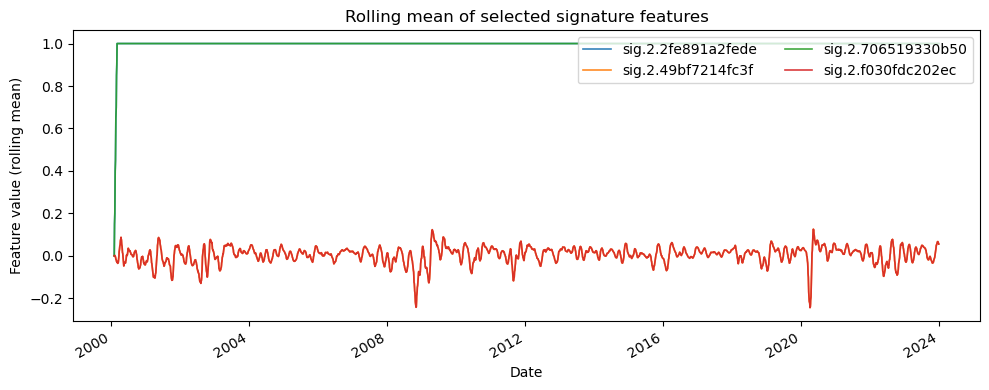

In [ ]:
#| echo: false
#| output: false
cols_to_plot = sig_cols[:4]
ax = X_sig_only[cols_to_plot].rolling(20).mean().plot(
    figsize=(10, 4), lw=1.2, alpha=0.9
)
ax.set_title("Rolling mean of selected signature features")
ax.set_xlabel("Date")
ax.set_ylabel("Feature value (rolling mean)")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()

Most of the level-2 signature of a 20-day augmented return path have near-zero correlation with the target (next-day squared return), and many are highly correlated with each other — a direct consequence of the augmentation pipeline generating algebraically related terms.

The clustered correlation matrix below makes the redundancy structure visible. Large off-diagonal blocks of near-perfect correlation ($|\rho| > 0.95$) indicate groups of features that carry the same information.

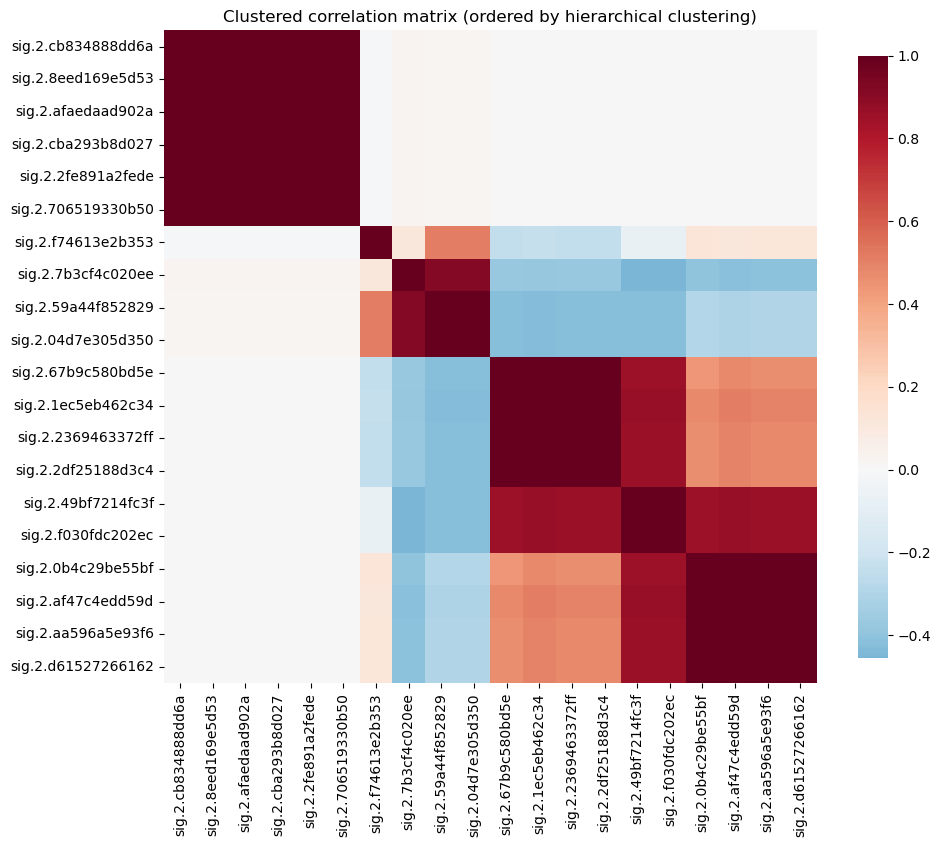

In [102]:
#| code-fold: true
#| code-summary: "Clustered correlation heatmap"
subset = sig_cols[:50]
corr = X_sig_only[subset].corr().replace([np.inf, -np.inf], np.nan).fillna(0.0)

dist = 1.0 - np.abs(corr.values)
np.fill_diagonal(dist, 0.0)
dist[np.isclose(dist, 0.0)] = 0.0

Z = linkage(squareform(dist, checks=False), method="average")
order = leaves_list(Z)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(10, 9))
sns.heatmap(
    corr_reordered,
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Clustered correlation matrix (ordered by hierarchical clustering)")
plt.tight_layout()
plt.show()

### Cluster-Based Feature Selection

Rather than manually pruning augmentations, we keep the full pipeline and **select one representative per correlation cluster**:

1. Compute the pairwise correlation matrix on the **training set only** (no look-ahead).
2. Hierarchically cluster features using $d_{ij} = 1 - |\rho_{ij}|$.
3. Cut the dendrogram at threshold $t$ (e.g. $t = 0.05$ → features with $|\rho| \geq 0.95$ are merged).
4. From each cluster, keep the feature with the highest $|\text{corr}|$ with the target $y$.

If a `max_features` budget is set, the threshold is progressively lowered until the cluster count falls within budget. This is preferable to PCA because each selected column remains an interpretable signature coordinate, and the selection is fit on training data only.

The pair of heatmaps after the cluster output shows the correlation structure before and after selection: the left panel displays all 42 signature features with the dense off-diagonal blocks discussed above, while the right panel shows the 6 surviving representatives with near-zero mutual correlation.

In [103]:
#| code-fold: true
#| code-summary: "Cluster-based feature selection"
def select_features_by_cluster(
    X: pd.DataFrame,
    y: pd.Series,
    feature_cols: list[str],
    train_slice: slice,
    corr_threshold: float = 0.95,
    max_features: int | None = None,
) -> tuple[list[str], dict]:
    """Select one feature per correlation cluster, fit on training data only.

    Parameters
    ----------
    X : DataFrame with all features
    y : target series (aligned to X index)
    feature_cols : columns to cluster and select from
    train_slice : training indices (causal — clustering uses train only)
    corr_threshold : features with |corr| >= this are grouped together.
        This is the *starting* threshold — if ``max_features`` is set and
        the initial clustering yields too many clusters, the threshold is
        progressively lowered (i.e. clusters are merged more aggressively)
        until the feature count is within budget.
    max_features : int or None
        Hard cap on the number of selected features.  When set, the
        correlation threshold is lowered in steps of 0.05 until
        ``n_clusters <= max_features``.

    Returns
    -------
    selected : list of str
        Selected feature column names (one per cluster).
    cluster_map : dict
        Mapping from cluster id to list of member feature names.
    """
    X_train = X.iloc[train_slice][feature_cols]
    y_train = y.iloc[train_slice]

    # 0. Drop zero-variance features (e.g. warmup zeros that never vary in training)
    variances = X_train.var()
    live_cols = [c for c in feature_cols if variances[c] > 0]
    dropped_cols = [c for c in feature_cols if variances[c] <= 0]
    if dropped_cols:
        print(f"  Dropped {len(dropped_cols)} zero-variance features in training window")

    X_train = X_train[live_cols]

    # 1. Correlation matrix on training data
    #    NaN correlations (e.g. near-constant columns) treated as perfectly correlated
    #    so they get grouped together and only one survives
    corr_mat = X_train.corr().replace([np.inf, -np.inf], np.nan)
    corr_mat = corr_mat.fillna(1.0)

    # 2. Distance = 1 - |corr|
    dist = 1.0 - np.abs(corr_mat.values)
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0.0, None)  # numerical safety

    # 3. Hierarchical clustering — adapt threshold to meet max_features budget
    Z = linkage(squareform(dist, checks=False), method="average")

    threshold = corr_threshold
    while True:
        cut_distance = 1.0 - threshold
        labels = fcluster(Z, t=cut_distance, criterion="distance")
        n_clusters = len(set(labels))
        if max_features is None or n_clusters <= max_features:
            break
        # Lower threshold (merge more aggressively) and retry
        threshold -= 0.05
        if threshold < 0.30:
            # Safety floor — don't merge features with |corr| < 0.30
            break

    if threshold < corr_threshold:
        print(f"  Lowered corr_threshold {corr_threshold:.2f} → {threshold:.2f} "
              f"to meet max_features={max_features} (got {n_clusters} clusters)")

    # 4. For each cluster, pick feature with highest |corr| with target
    target_corr = X_train.corrwith(y_train).abs().fillna(0.0)
    selected = []
    cluster_map = {}  # cluster_id -> list of features
    for col, cid in zip(live_cols, labels):
        cluster_map.setdefault(cid, []).append(col)

    for cid, members in sorted(cluster_map.items()):
        best = max(members, key=lambda c: target_corr.get(c, 0.0))
        selected.append(best)

    return selected, cluster_map

In [104]:
#| code-fold: true
#| code-summary: "Apply cluster-based selection"
train_sl = slice(SPY_IS_INDEX, SPY_OS_INDEX)

selected_sig_cols, cluster_map = select_features_by_cluster(
    X_sig, y_base, sig_cols, train_slice=train_sl, corr_threshold=0.95,
)

print(f"Original signature features: {len(sig_cols)}")
print(f"Clusters found: {len(cluster_map)}")
print(f"Selected features (one per cluster): {len(selected_sig_cols)}")
print()

for cid, members in sorted(cluster_map.items(), key=lambda x: -len(x[1])):
    chosen = [m for m in members if m in selected_sig_cols][0]
    if len(members) > 1:
        dropped = [m for m in members if m != chosen]
        print(f"  Cluster {cid} ({len(members)} features): keep {chosen}, drop {dropped}")
    else:
        print(f"  Cluster {cid} (1 feature): keep {chosen}")

  Dropped 4 zero-variance features in training window
Original signature features: 20
Clusters found: 6
Selected features (one per cluster): 6

  Cluster 5 (5 features): keep sig.2.1ec5eb462c34, drop ['sig.2.2369463372ff', 'sig.2.8eed169e5d53', 'sig.2.67b9c580bd5e', 'sig.2.2df25188d3c4']
  Cluster 3 (4 features): keep sig.2.af47c4edd59d, drop ['sig.2.aa596a5e93f6', 'sig.2.0b4c29be55bf', 'sig.2.d61527266162']
  Cluster 4 (3 features): keep sig.2.49bf7214fc3f, drop ['sig.2.f030fdc202ec', 'sig.2.afaedaad902a']
  Cluster 1 (2 features): keep sig.2.59a44f852829, drop ['sig.2.04d7e305d350']
  Cluster 2 (1 feature): keep sig.2.7b3cf4c020ee
  Cluster 6 (1 feature): keep sig.2.f74613e2b353


/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


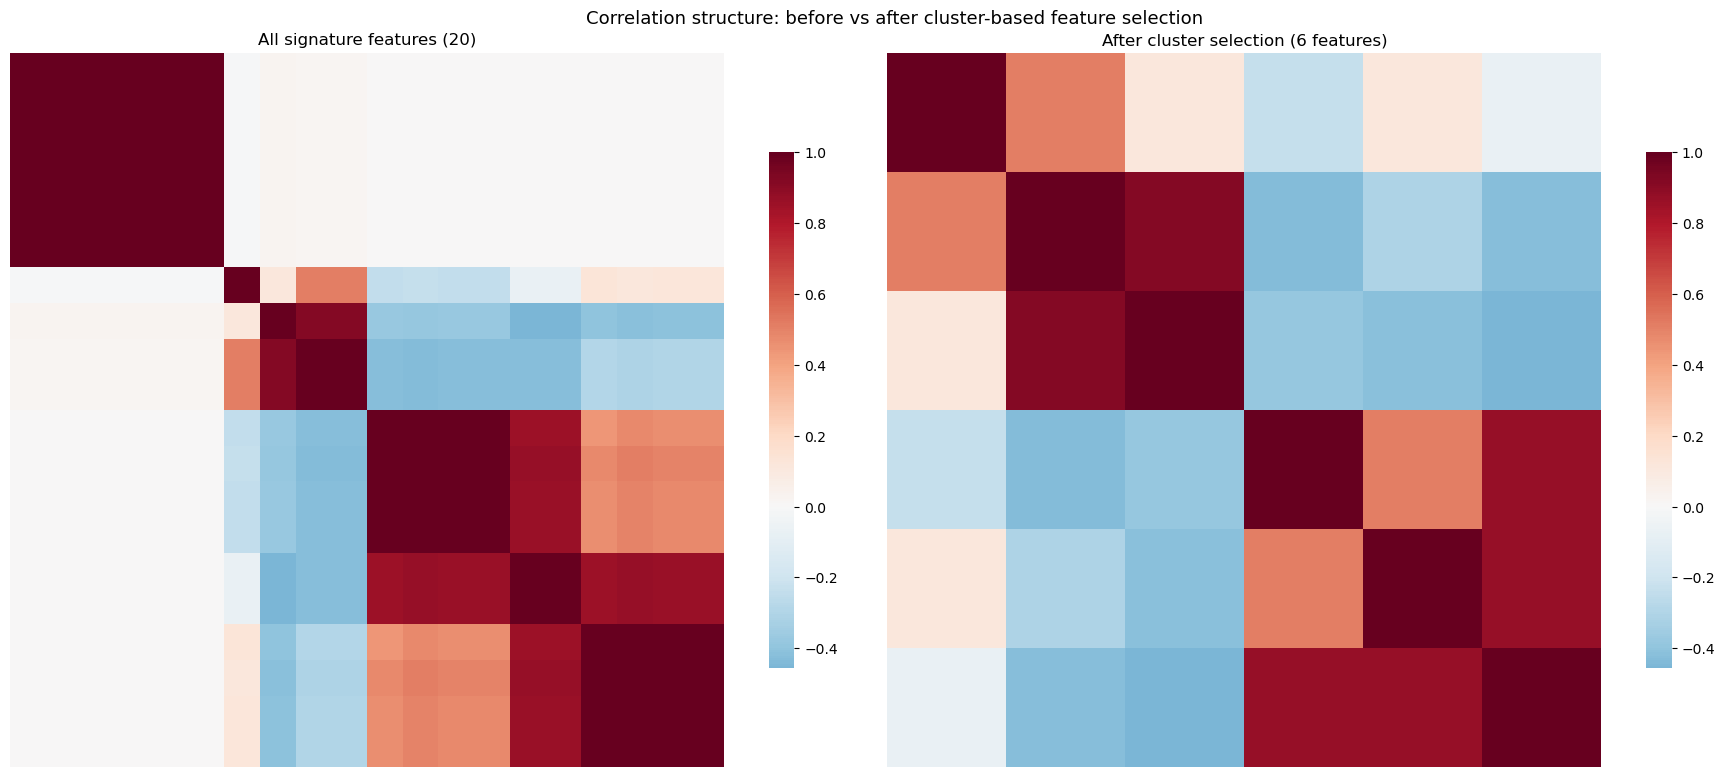

In [105]:
#| code-fold: true
#| code-summary: "Before / after selection heatmap"
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: all signature features
corr_all = X_sig_only.corr().replace([np.inf, -np.inf], np.nan).fillna(0.0)
dist_all = 1.0 - np.abs(corr_all.values)
np.fill_diagonal(dist_all, 0.0)
dist_all = np.clip(dist_all, 0.0, None)
Z_all = linkage(squareform(dist_all, checks=False), method="average")
order_all = leaves_list(Z_all)
corr_all_reordered = corr_all.iloc[order_all, order_all]

sns.heatmap(corr_all_reordered, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7}, ax=axes[0],
            xticklabels=False, yticklabels=False)
axes[0].set_title(f"All signature features ({len(sig_cols)})")

# Right: selected features only
X_selected = X_sig_only[selected_sig_cols]
corr_sel = X_selected.corr().replace([np.inf, -np.inf], np.nan).fillna(0.0)
if len(selected_sig_cols) > 2:
    dist_sel = 1.0 - np.abs(corr_sel.values)
    np.fill_diagonal(dist_sel, 0.0)
    dist_sel = np.clip(dist_sel, 0.0, None)
    Z_sel = linkage(squareform(dist_sel, checks=False), method="average")
    order_sel = leaves_list(Z_sel)
    corr_sel_reordered = corr_sel.iloc[order_sel, order_sel]
else:
    corr_sel_reordered = corr_sel

sns.heatmap(corr_sel_reordered, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7}, ax=axes[1],
            xticklabels=False, yticklabels=False)
axes[1].set_title(f"After cluster selection ({len(selected_sig_cols)} features)")

plt.suptitle("Correlation structure: before vs after cluster-based feature selection", fontsize=13)
plt.tight_layout()
plt.show()

## Experiment 1: Evaluation

We test whether appending the 6 selected signature coordinates to the model feature set improves out-of-sample forecasts. The three model tiers are the same as in [Part 3](../volatility-forecasts-3/):

1. **ES** — fixed smoothing parameter $\alpha$.
2. **STES** — $\alpha_t = \sigma(\mathbf{x}_t^\top \boldsymbol{\beta})$, with or without signature features in $\mathbf{x}_t$. When signatures are included, an L2 penalty on $\boldsymbol{\beta}$ is tuned via cross-validation.
3. **XGBoost-STES** — $\alpha_t = \sigma\bigl(f(\mathbf{x}_t)\bigr)$, with hyperparameters selected by 5-fold CV on the training set.

All models are evaluated on a single fixed split (IS: 2000–2015, OOS: 2016–2023), averaged across 10 random seeds.

In [106]:
#| echo: false
#| output: false
# Ensure latest library code is loaded
importlib.reload(_tsm)
XGBoostSTESModel = _tsm.XGBoostSTESModel

In [173]:
#| code-fold: true
#| code-summary: "Model creation and helper functions"
"""Taken from volatility_forecast/example/volatility_forecast_2.py"""

class ModelName(str, Enum):
    ES = "ES"
    STES_EAESE = "STES_EAESE"
    XGBSTES_E2E = "XGBSTES_E2E"

def _make_xgb_stes_model(
    *,
    seed: int | None,
    fit_method: str = "end_to_end",
    loss: str = "mse",
    xgb_params: dict | None = None,
    monotonic_constraints: dict[str, int] | None = None,
) -> XGBoostSTESModel:
    """Create XGBoost STES model with specified configuration."""
    params = dict(XGB_PARAMS)
    if xgb_params:
        params.update(xgb_params)
    
    # Strip gblinear-specific params when using tree booster
    if params.get("booster", "gbtree") != "gblinear":
        params.pop("updater", None)
    
    e2e_kwargs = {}
    if fit_method == "end_to_end":
        e2e_kwargs = {
            "e2e_grad_hess_scale": 1.0,
            "e2e_debug": True,
            "e2e_debug_print_once": True,
        }

    return XGBoostSTESModel(
        xgb_params=params,
        num_boost_round=XGB_ROUNDS,
        init_window=INIT_WINDOW,
        fit_method=fit_method,
        loss=loss,
        random_state=seed,
        monotonic_constraints=monotonic_constraints,
        **e2e_kwargs,
    )

def _infer_monotone_constraints(cols: list[str]) -> dict[str, int]:
    """Enforce -1 monotonicity on shock-magnitude features."""
    out: dict[str, int] = {}
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in ["abs", "squared", "sq", "r2", "vol", "rv"]):
            out[c] = -1
    return out

def _xgb_variant_overrides(variant: str, cols: list[str]) -> dict:
    """Translate variant names into model configuration."""
    v = variant.upper()
    fit_method = "end_to_end" if "E2E" in v or "END_TO_END" in v else "alternating"
    loss = "pseudohuber" if "HUBER" in v else "mse"
    mono = _infer_monotone_constraints(cols) if "MONO" in v else None
    return {"fit_method": fit_method, "loss": loss, "monotonic_constraints": mono}

def _is_signature_col(col: str) -> bool:
    return col.startswith("sig.") or col.startswith("mcsig.")

def _scale_train_test(
    X: pd.DataFrame, train_slice: slice, test_slice: slice
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Standardize all features (including signatures) on train, apply to test.

    Matches volatility_forecast_2.py: every column except 'const' is scaled.
    """
    X_tr = X.iloc[train_slice].copy()
    X_te = X.iloc[test_slice].copy()

    cols_to_scale = [c for c in X.columns if c != "const"]

    if not cols_to_scale:
        return X_tr, X_te

    scaler = StandardScaler().fit(X_tr[cols_to_scale])
    X_tr.loc[:, cols_to_scale] = pd.DataFrame(
        scaler.transform(X_tr[cols_to_scale]),
        index=X_tr.index,
        columns=cols_to_scale,
    )
    X_te.loc[:, cols_to_scale] = pd.DataFrame(
        scaler.transform(X_te[cols_to_scale]),
        index=X_te.index,
        columns=cols_to_scale,
    )

    return X_tr, X_te

In [181]:
#| code-fold: true
#| code-summary: "Fit and predict implementation"
"""Taken from volatility_forecast/example/volatility_forecast_2.py"""
def _fit_predict_oos(
    *,
    variant: str,
    X: pd.DataFrame,
    y: pd.Series,
    r: pd.Series,
    train_slice: slice,
    test_slice: slice,
    seed: int | None = None,
    xgb_params: dict | None = None,
    extra_cols: list[str] | None = None,
    return_alpha: bool = False,
    cv_splits: int = 5,
) -> tuple[pd.Index, np.ndarray] | tuple[pd.Index, np.ndarray, pd.Series]:
    """Fit model on train slice and predict on test slice with warm-start.
    
    For XGBoost-STES variants, supports three fitting modes via suffix:
      - No suffix or _COLD: cold-start (default)
      - _WS: warm-start — initialize from baseline z-scores via base_margin
      - _2S: two-stage — freeze baseline, train only on signature features
    
    Tree booster mode: include _TREE in the variant name to use gbtree
    instead of gblinear.  Warm-start / two-stage are not supported with
    gbtree (the tree builder is greedy, so does not suffer from gblinear's
    non-convexity issues).
    """
    from scipy.special import expit as _expit
    
    variant_name = variant.value if isinstance(variant, Enum) else str(variant)
    
    # Detect warm-start / two-stage mode from variant suffix
    fit_mode = "cold"
    clean_variant = variant_name
    if variant_name.endswith("_WS"):
        fit_mode = "warm_start"
        clean_variant = variant_name[:-3]  # strip _WS
    elif variant_name.endswith("_2S"):
        fit_mode = "two_stage"
        clean_variant = variant_name[:-3]  # strip _2S
    
     # Detect tree booster from variant name
    is_tree = "_TREE" in clean_variant.upper()
    
    if is_tree and fit_mode != "cold":
        logger.warning(
            f"[{variant_name}] Warm-start/two-stage not supported for "
            f"gbtree — falling back to cold-start"
        )
        fit_mode = "cold"
    
    # For tree variants, inject gbtree-specific XGBoost parameters
    if is_tree:
        tree_defaults = {
            "booster": "gbtree",
            "max_depth": 2,
            "eta": 0.05,
            "subsample": 1.0,       # keep 1.0 for temporal STES
            "colsample_bytree": 1.0,
            "min_child_weight": 5.0,
            "reg_lambda": 1.0,
            "reg_alpha": 0.0,
            "verbosity": 0,
        }
        # User's xgb_params override tree defaults
        if xgb_params:
            tree_defaults.update(xgb_params)
        xgb_params = tree_defaults
    
    # Prepare data
    if clean_variant.startswith("XGBSTES_"):
        # Drop 'const' — gblinear already has an unpenalized bias term;
        # keeping const creates a redundant, partly-penalized intercept.
        if extra_cols:
            # Use baseline (non-sig) columns + ONLY the specified extra columns
            base_only = [c for c in X.columns if not _is_signature_col(c)]
            cols = base_only + [c for c in extra_cols if c in X.columns and c not in base_only]
        else:
            cols = [c for c in X.columns if not _is_signature_col(c)]
        cols = [c for c in cols if c != "const"]
        X_sel = X[cols]
        X_tr, X_te = _scale_train_test(X_sel, train_slice, test_slice)
        y_tr, r_tr = y.iloc[train_slice], r.iloc[train_slice]
        r_te = r.iloc[test_slice]
        
        over = _xgb_variant_overrides(clean_variant, cols)
        model = _make_xgb_stes_model(seed=None, xgb_params=xgb_params, **over)
    else:
        cols = select_variant_columns(X, clean_variant) or ["const"]
        cols = [c for c in cols if not _is_signature_col(c)]
        if extra_cols:
            cols = cols + [c for c in extra_cols if c not in set(cols)]
        
        X_sel = X[cols]
        X_tr, X_te = _scale_train_test(X_sel, train_slice, test_slice)
        y_tr, r_tr = y.iloc[train_slice], r.iloc[train_slice]
        r_te = r.iloc[test_slice]
        
        if clean_variant == ModelName.ES.value:
            model = ESModel(random_state=seed) if seed is not None else ESModel()
        else:
            model = STESModel(random_state=seed) if seed is not None else STESModel()
    
    # Fit model
    if clean_variant.startswith("XGBSTES_"):
        r_tr_scaled = r_tr * SCALE_FACTOR
        y_tr_scaled = y_tr * (SCALE_FACTOR**2)
        
        # CV grid: tree models need different hyperparameters
        if is_tree:
            grid_e2e = [
                {"max_depth": 2, "min_child_weight": 5.0, "eta": 0.05},
                {"max_depth": 3, "min_child_weight": 10.0, "eta": 0.03},
                {"max_depth": 2, "min_child_weight": 20.0, "eta": 0.1},
            ]
        else:
            grid_e2e = [
                {"min_child_weight": 5.0, "learning_rate": 0.05, "max_depth": 3},
                {"min_child_weight": 20.0, "learning_rate": 0.1, "max_depth": 3},
                {"min_child_weight": 50.0, "learning_rate": 0.05, "max_depth": 2},
            ]
        
        # ── WARM-START / TWO-STAGE: fit baseline first ──────────────────
        base_margin_train = None
        base_margin_all = None
        X_tr_fit = X_tr      # features used for fitting
        X_all_fit = None      # will be set later for prediction
        
        if fit_mode in ("warm_start", "two_stage") and extra_cols:
            # 1. Fit baseline model (without signature features)
            base_cols = [c for c in cols if not _is_signature_col(c)]
            X_tr_base_ws, X_te_base_ws = _scale_train_test(X[base_cols], train_slice, test_slice)
            
            model_base = _make_xgb_stes_model(seed=None, xgb_params=xgb_params, **over)
            model_base.fit(
                X_tr_base_ws, y_tr_scaled, returns=r_tr_scaled,
                perform_cv=True, cv_grid=grid_e2e, cv_splits=cv_splits,
                start_index=0, end_index=len(X_tr_base_ws),
            )
            
            # 2. Extract baseline z-scores: z = bias + Σ w_j * x_j
            dump_str = model_base.model_.get_dump()[0]
            b_bl, w_bl = _parse_gblinear_dump(dump_str)
            
            # Map baseline weights to the full (augmented) feature space
            w_embedded = np.zeros(len(cols))
            for j, c in enumerate(cols):
                if c in base_cols:
                    base_j = base_cols.index(c)
                    w_embedded[j] = w_bl[base_j]
            
            # Compute z_baseline on scaled augmented features
            X_tr_np = X_tr.values.astype(float)
            z_baseline_train = b_bl + X_tr_np @ w_embedded
            
            # Also for test (needed at prediction time)
            X_te_np = X_te.values.astype(float)
            z_baseline_test = b_bl + X_te_np @ w_embedded
            
            base_margin_train = z_baseline_train
            base_margin_all = np.concatenate([z_baseline_train, z_baseline_test])
            
            if fit_mode == "two_stage":
                # Only train on signature features; baseline is frozen in base_margin
                sig_fit_cols = [c for c in cols if _is_signature_col(c)]
                X_tr_fit = X_tr[sig_fit_cols]
                # Create separate model for sig-only features
                model = _make_xgb_stes_model(seed=None, xgb_params=xgb_params, **over)
            
            logger.info(
                f"[{fit_mode}] Baseline fitted (bias={b_bl:.4f}). "
                f"base_margin range: [{z_baseline_train.min():.3f}, {z_baseline_train.max():.3f}]"
            )
        
        model.fit(
            X_tr_fit, y_tr_scaled, returns=r_tr_scaled,
            perform_cv=True, cv_grid=grid_e2e, cv_splits=cv_splits,
            start_index=0, end_index=len(X_tr_fit),
            base_margin=base_margin_train,
        )
    elif extra_cols and isinstance(model, STESModel):
        # Group L2: penalize only signature features, leave baseline free.
        # Uniform L2 shrinks useful baseline weights when trying to suppress
        # noisy signature weights — group-specific penalties avoid this.
        from sklearn.model_selection import TimeSeriesSplit
        from scipy.optimize import least_squares as _lsq

        X_tr_np = X_tr.values.astype(float)
        y_tr_np = y_tr.values.astype(float)
        r_tr_np = r_tr.values.astype(float)
        p = X_tr_np.shape[1]
        col_list = list(X_tr.columns)

        # Mask: 1.0 for signature features, 0.0 for baseline / const
        sig_mask = np.array(
            [1.0 if _is_signature_col(c) else 0.0 for c in col_list]
        )

        l2_sig_grid = [0.0, 0.01, 0.1, 1.0, 10.0]
        tscv = TimeSeriesSplit(n_splits=cv_splits)
        best_l2, best_mse = 0.0, np.inf

        for l2_cand in l2_sig_grid:
            fold_mses = []
            for tr_idx, va_idx in tscv.split(X_tr_np):
                Xf_tr, Xf_va = X_tr_np[tr_idx], X_tr_np[va_idx]
                yf_tr, yf_va = y_tr_np[tr_idx], y_tr_np[va_idx]
                rf_tr, rf_va = r_tr_np[tr_idx], r_tr_np[va_idx]

                scale_tr = np.linalg.norm(yf_tr)
                p_vec = (
                    np.sqrt(l2_cand) * scale_tr * sig_mask
                    if l2_cand > 0
                    else None
                )

                rng = np.random.default_rng(seed)
                x0 = rng.normal(0, 1, size=p)
                res = _lsq(
                    STESModel._objective,
                    x0=x0,
                    jac=STESModel._jacobian,
                    args=(rf_tr, Xf_tr, yf_tr, 0, len(Xf_tr), p_vec),
                )
                beta = res.x

                alphas_va = _expit(Xf_va @ beta)
                r2_va = rf_va ** 2
                v = (
                    float(np.mean(rf_tr[-20:] ** 2))
                    if len(rf_tr) >= 20
                    else float(r2_va[0])
                )
                yhat_va = np.empty(len(yf_va))
                for t in range(len(yf_va)):
                    v_next = alphas_va[t] * r2_va[t] + (1 - alphas_va[t]) * v
                    yhat_va[t] = v_next
                    v = v_next
                fold_mses.append(float(np.mean((yf_va - yhat_va) ** 2)))

            avg_mse = float(np.mean(fold_mses))
            if avg_mse < best_mse:
                best_mse, best_l2 = avg_mse, l2_cand

        logger.info(
            f"Group-L2 CV selected λ_sig={best_l2:.4f} (MSE={best_mse:.2e})"
        )

        # Final fit with best group penalty
        scale = np.linalg.norm(y_tr_np)
        p_vec_final = (
            np.sqrt(best_l2) * scale * sig_mask if best_l2 > 0 else None
        )
        rng = np.random.default_rng(seed)
        x0 = rng.normal(0, 1, size=p)
        res = _lsq(
            STESModel._objective,
            x0=x0,
            jac=STESModel._jacobian,
            args=(r_tr_np, X_tr_np, y_tr_np, 0, len(X_tr_np), p_vec_final),
        )
        model.params = res.x
        model._set_schema(col_list, p)
    else:
        model.fit(X_tr, y_tr, returns=r_tr, start_index=0, end_index=len(X_tr))
    
    # Warm-start prediction: concatenate train+test to avoid cold start
    n_tr = len(X_tr)
    X_all = pd.concat([X_tr, X_te], axis=0)
    r_all = pd.concat([r_tr, r_te], axis=0)
    
    if clean_variant.startswith("XGBSTES_"):
        r_all_scaled = r_all * SCALE_FACTOR
        
        # For two-stage prediction, use sig-only features
        if fit_mode == "two_stage" and extra_cols:
            sig_fit_cols = [c for c in cols if _is_signature_col(c)]
            X_all_pred = pd.concat([X_tr[sig_fit_cols], X_te[sig_fit_cols]], axis=0)
        else:
            X_all_pred = X_all
        
        y_hat_all_scaled = model.predict(
            X_all_pred, returns=r_all_scaled,
            base_margin=base_margin_all,
        )
        y_hat_all = np.asarray(y_hat_all_scaled, dtype=float) / (SCALE_FACTOR**2)
        alpha_all = model.get_alphas(X_all_pred, base_margin=base_margin_all)
    else:
        y_hat_all = model.predict(X_all, returns=r_all)
        if isinstance(model, STESModel):
            _yhat_vals, alpha_vals = model.predict_with_alpha(X_all, returns=r_all)
            alpha_all = pd.Series(alpha_vals, index=X_all.index, name="alpha")
        else:
            alpha_val = getattr(model, "alpha_", np.nan)
            alpha_all = pd.Series(alpha_val, index=X_all.index, name="alpha")
    
    # Extract test predictions
    y_hat_arr = np.asarray(y_hat_all, dtype=float)[n_tr:]
    keep = np.isfinite(y_hat_arr)
    
    if return_alpha:
        return X_te.index[keep], y_hat_arr[keep], alpha_all
    return X_te.index[keep], y_hat_arr[keep]

In [144]:
#| code-fold: true
#| code-summary: "Multi-seed evaluation"
"""Taken from volatility_forecast/example/volatility_forecast_2.py"""
def evaluate_fixed_split(
    X: pd.DataFrame,
    y: pd.Series,
    r: pd.Series,
    *,
    variants: list[str],
    seeds: list[int],
    is_index: int = SPY_IS_INDEX,
    os_index: int = SPY_OS_INDEX,
    extra_cols_by_variant: dict[str, list[str]] | None = None,
    cv_splits: int = 5,
) -> pd.DataFrame:
    """Evaluate variants across multiple random seeds."""
    train_sl = slice(is_index, os_index)
    test_sl = slice(os_index, len(y))

    rows = []
    for variant in variants:
        rmses, maes, medaes = [], [], []
        extra_cols = (extra_cols_by_variant or {}).get(variant)

        for seed in seeds:
            try:
                idx_te, y_hat = _fit_predict_oos(
                    variant=variant,
                    X=X,
                    y=y,
                    r=r,
                    train_slice=train_sl,
                    test_slice=test_sl,
                    seed=seed,
                    extra_cols=extra_cols,
                    cv_splits=cv_splits,
                )
                y_true = y.loc[idx_te].values
                rmses.append(rmse(y_true, y_hat))
                maes.append(mae(y_true, y_hat))
                medaes.append(medae(y_true, y_hat))
            except Exception as e:
                logger.exception(
                    f"Fixed-split eval failed: variant={variant}, seed={seed}: {e}"
                )

        rows.append(
            {
                "variant": variant,
                "rmse": float(np.mean(rmses)) if rmses else np.nan,
                "mae": float(np.mean(maes)) if maes else np.nan,
                "medae": float(np.mean(medaes)) if medaes else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("rmse")

### Baseline Results

First the baseline — identical to [Part 3](../volatility-forecasts-3/). XGBoost-STES dominates on RMSE and MAE.

In [145]:
#| echo: false
#| output: false
# Build baseline dataset
X_base, y_base, r_base = build_spy_dataset_baseline(ctx, lags=N_LAGS)

baseline_index = y_base.index
baseline_columns = list(X_base.columns)

print(f"Baseline dataset rows: {len(y_base)}")
print(f"Baseline columns: {baseline_columns}")
print(f"In-sample date: {baseline_index[SPY_IS_INDEX]}")
print(f"Out-of-sample date: {baseline_index[SPY_OS_INDEX]}")

Baseline dataset rows: 6034
Baseline columns: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'const']
In-sample date: 2000-10-18 16:00:00+00:00
Out-of-sample date: 2015-11-27 16:00:00+00:00


In [146]:
#| echo: false
# Evaluate baseline models
seeds = list(range(10))  # Use 10 seeds for faster evaluation
baseline_variants = ["ES", "STES_EAESE", "XGBSTES_E2E"]

print("Evaluating baseline models...")
baseline_results = evaluate_fixed_split(
    X_base, y_base, r_base, 
    variants=baseline_variants, 
    seeds=seeds
)

Evaluating baseline models...


In [147]:
#| echo: false
display(style_results_table(baseline_results))

,rmse,mae,medae
variant,,,
XGBSTES_E2E,0.000443,0.000132,0.000045
STES_EAESE,0.000448,0.000138,0.000051
ES,0.000464,0.000140,0.000050


### With Signature Features

Now we append the 6 cluster-selected signature coordinates as additional features. For STES, an L2 regularization penalty is tuned via 5-fold CV (grid: $\lambda \in \{0, 0.01, 0.1, 1.0, 10.0\}$).

In [148]:
#| echo: false
#| output: false
# Rebuild sig dataset for evaluation
sig_config = SignatureConfig(
    name="L20_L2",
    lookback=20,
    level=2,
    augmentations=["cumsum", "basepoint", "addtime", "leadlag"],
    sig_tfm="signature"
)

X_sig = build_spy_dataset_with_signature(
    ctx,
    sig=sig_config,
    baseline_X=X_base,
    baseline_index=baseline_index,
    baseline_columns=baseline_columns,
    lags=N_LAGS,
)

sig_cols = [c for c in X_sig.columns if c not in set(baseline_columns)]
print(f"Signature features: {len(sig_cols)} → {len(selected_sig_cols)} after selection")

/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Signature features: 20 → 6 after selection


In [149]:
#| echo: false
#| output: false
# Evaluate models with signature features (cluster-selected subset)
stes_sig_name = f"STES_EAESE_SIG_{sig_config.name}"
xgb_sig_name = f"XGBSTES_E2E_SIG_{sig_config.name}"

sig_variants = ["ES", "STES_EAESE", "XGBSTES_E2E", stes_sig_name, xgb_sig_name]

# Build dataset with only baseline + selected signature features
X_sig_selected = X_sig[baseline_columns + selected_sig_cols].copy()

# Pass selected signature columns as extra features for signature variants
extra_cols_by_variant = {
    stes_sig_name: selected_sig_cols,
    xgb_sig_name: selected_sig_cols,
}

print(f"Evaluating with {len(selected_sig_cols)} selected signature features...")
sig_results = evaluate_fixed_split(
    X_sig_selected, y_base, r_base,
    variants=sig_variants,
    seeds=seeds,
    extra_cols_by_variant=extra_cols_by_variant
)


Evaluating with 6 selected signature features...


In [150]:
#| echo: false
display(style_results_table(sig_results))

,rmse,mae,medae
variant,,,
XGBSTES_E2E,0.000443,0.000132,0.000045
STES_EAESE,0.000448,0.000138,0.000051
STES_EAESE_SIG_L20_L2,0.000453,0.000134,0.000046
XGBSTES_E2E_SIG_L20_L2,0.000457,0.000139,0.000046
ES,0.000464,0.000140,0.000050


The above table suggests that signatures do not carry useful information in determining the learning rate $\alpha$. Both STES and XGBoost-STES degrade slightly when signature features are added. The L2 CV for STES selects a high penalty — the optimizer effectively shrinks the signature coefficients toward zero. It is equally informative to examine the predicted smoothing parameter $\alpha_t$ with and without signature features.

### Diagnosing via $\alpha_t$ Paths

The plot below overlays the predicted $\alpha_t$ for STES and XGBoost-STES, with and without signature features. If signatures carried genuine signal, we would expect the augmented $\alpha_t$ to track volatility regimes more tightly. Instead, the signature-augmented paths are noisier — the additional features introduce high-frequency variation in $\alpha_t$ that does not correspond to actual regime changes. Moreover, there appears to be an $\alpha$ level shift. This is a more serious problem, which we examine later in this post.

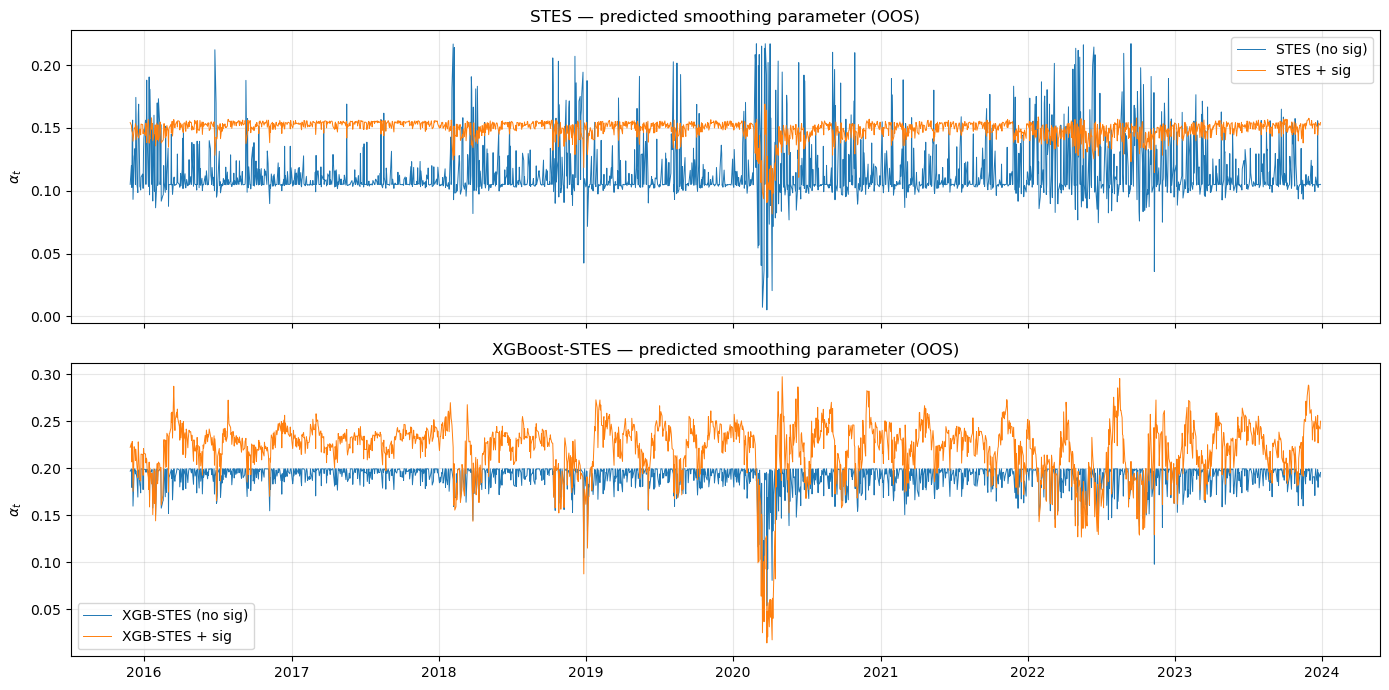

In [155]:
#| code-fold: true
#| code-summary: "Alpha path comparison plot"
train_slice = slice(SPY_IS_INDEX, SPY_OS_INDEX)
test_slice  = slice(SPY_OS_INDEX, len(y_base))

alpha_variants = {
    "STES (no sig)":   dict(variant="STES_EAESE",   extra_cols=None),
    "STES + sig":      dict(variant=stes_sig_name,   extra_cols=selected_sig_cols),
    "XGB-STES (no sig)": dict(variant="XGBSTES_E2E", extra_cols=None),
    "XGB-STES + sig":    dict(variant=xgb_sig_name,   extra_cols=selected_sig_cols),
}

alphas = {}
for label, kw in alpha_variants.items():
    _, _, alpha = _fit_predict_oos(
        X=X_sig_selected, y=y_base, r=r_base,
        train_slice=train_slice, test_slice=test_slice,
        seed=0, return_alpha=True, **kw,
    )
    alphas[label] = alpha.iloc[SPY_OS_INDEX - SPY_IS_INDEX :]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for label in ["STES (no sig)", "STES + sig"]:
    axes[0].plot(alphas[label].index, alphas[label].values, label=label, linewidth=0.7)
axes[0].set_ylabel(r"$\alpha_t$")
axes[0].set_title("STES — predicted smoothing parameter (OOS)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for label in ["XGB-STES (no sig)", "XGB-STES + sig"]:
    axes[1].plot(alphas[label].index, alphas[label].values, label=label, linewidth=0.7)
axes[1].set_ylabel(r"$\alpha_t$")
axes[1].set_title("XGBoost-STES — predicted smoothing parameter (OOS)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [165]:
#| code-fold: true
#| code-summary: "Alpha level shift analysis"

# ── Quantify the alpha level shift visible in the chart ──────────────────
print("OOS SMOOTHING PARAMETER (α) — LEVEL SHIFT ANALYSIS")
print("=" * 72)
print(f"\n{'Model':>25s}  {'mean(α)':>10s}  {'std(α)':>10s}  {'median':>10s}  {'IQR':>12s}")
print("-" * 72)
for label in ["STES (no sig)", "STES + sig", "XGB-STES (no sig)", "XGB-STES + sig"]:
    a = alphas[label].values
    q25, q75 = np.percentile(a, [25, 75])
    print(f"{label:>25s}  {a.mean():>10.4f}  {a.std():>10.4f}  {np.median(a):>10.4f}  [{q25:.4f}, {q75:.4f}]")

# ── Level shift magnitudes ──────────────────────────────────────────────
a_stes_base = alphas["STES (no sig)"].values
a_stes_sig  = alphas["STES + sig"].values
a_xgb_base  = alphas["XGB-STES (no sig)"].values
a_xgb_sig   = alphas["XGB-STES + sig"].values

print(f"\nLevel shifts:")
print(f"  STES:      mean α jumps from {a_stes_base.mean():.4f} → {a_stes_sig.mean():.4f}  (Δ = {a_stes_sig.mean() - a_stes_base.mean():+.4f}, {(a_stes_sig.mean()/a_stes_base.mean()-1)*100:+.1f}%)")
print(f"  XGB-STES:  mean α jumps from {a_xgb_base.mean():.4f} → {a_xgb_sig.mean():.4f}  (Δ = {a_xgb_sig.mean() - a_xgb_base.mean():+.4f}, {(a_xgb_sig.mean()/a_xgb_base.mean()-1)*100:+.1f}%)")

# ── Correlation between baseline and sig alpha paths ─────────────────────
corr_stes = np.corrcoef(a_stes_base, a_stes_sig)[0, 1]
corr_xgb = np.corrcoef(a_xgb_base, a_xgb_sig)[0, 1]
print(f"\nCorrelation between baseline α and sig α:")
print(f"  STES:     ρ = {corr_stes:.4f}")
print(f"  XGB-STES: ρ = {corr_xgb:.4f}")

# ── What does the level shift imply for the ES recursion? ────────────────
# α controls the weight on new shocks:  σ²_{t+1} = α·r²_t + (1-α)·σ²_t
# Higher α → faster reaction to shocks, less smoothing, more volatile forecasts
# Lower α → more smoothing, slower reaction, stabler forecasts
mean_shift_stes = a_stes_sig.mean() - a_stes_base.mean()
mean_shift_xgb = a_xgb_sig.mean() - a_xgb_base.mean()

# Implied half-life of a shock:  h = log(0.5) / log(1-α)
hl_stes_base = np.log(0.5) / np.log(1 - a_stes_base.mean())
hl_stes_sig = np.log(0.5) / np.log(1 - a_stes_sig.mean())
hl_xgb_base = np.log(0.5) / np.log(1 - a_xgb_base.mean())
hl_xgb_sig = np.log(0.5) / np.log(1 - a_xgb_sig.mean())

print(f"\nImplied shock half-life (days):")
print(f"  STES:     {hl_stes_base:.1f} days → {hl_stes_sig:.1f} days")
print(f"  XGB-STES: {hl_xgb_base:.1f} days → {hl_xgb_sig:.1f} days")
print(f"\n  The signature model reacts faster to shocks (shorter half-life).")
print(f"  This systematically changes the forecast character.")

OOS SMOOTHING PARAMETER (α) — LEVEL SHIFT ANALYSIS

                    Model     mean(α)      std(α)      median           IQR
------------------------------------------------------------------------
            STES (no sig)      0.1150      0.0236      0.1051  [0.1043, 0.1185]
               STES + sig      0.1492      0.0074      0.1513  [0.1467, 0.1539]
        XGB-STES (no sig)      0.1910      0.0136      0.1970  [0.1869, 0.1995]
           XGB-STES + sig      0.2203      0.0308      0.2268  [0.2072, 0.2383]

Level shifts:
  STES:      mean α jumps from 0.1150 → 0.1492  (Δ = +0.0342, +29.7%)
  XGB-STES:  mean α jumps from 0.1910 → 0.2203  (Δ = +0.0294, +15.4%)

Correlation between baseline α and sig α:
  STES:     ρ = -0.2254
  XGB-STES: ρ = 0.6658

Implied shock half-life (days):
  STES:     5.7 days → 4.3 days
  XGB-STES: 3.3 days → 2.8 days

  The signature model reacts faster to shocks (shorter half-life).
  This systematically changes the forecast character.


## Experiment 2: Multi-Channel Signatures

The single-channel signature only sees the log-return path. Volatility is a second-moment phenomenon — it cares about magnitudes and asymmetry, not direction alone. We can build a richer path by stacking multiple return transformations as channels before computing the signature:

| Channel | Formula | Captures |
|---------|---------|----------|
| Log-price | $X_t = \sum_{s=1}^t r_s$ | Path geometry, drift |
| Absolute return | $\lvert r_t \rvert$ | Unsigned shock magnitude |
| Squared return | $r_t^2$ | Variance proxy |
| Negative return | $r_t \cdot \mathbb{1}_{r_t < 0}$ | Leverage effect |

The signature of this 4D path produces **cross-channel iterated integrals** at level 2 — for example, terms that capture how the price path covaries with downside shocks, directly encoding the leverage effect. Augmentations are `basepoint → addtime → leadlag` (no `cumsum` — we integrate channel 0 manually).

The clustered correlation heatmap below visualizes the redundancy structure of the resulting 80+ multi-channel signature features. As with the single-channel case, we apply the same cluster-based selection pipeline, now capped at 20 features via `max_features`. The before/after heatmaps confirm that selection eliminates the dense correlation blocks while retaining diverse representatives.

In [117]:
#| code-fold: true
#| code-summary: "Multi-channel rolling signature builder"
from sktime.transformations.panel.signature_based import SignatureTransformer


def build_multichannel_rolling_signatures(
    returns: pd.Series,
    lookback: int = 20,
    level: int = 2,
    augmentations: tuple[str, ...] = ("basepoint", "addtime", "leadlag"),
    sig_tfm: str = "signature",
    rescaling: str = "post",
) -> pd.DataFrame:
    """Build signature features from a 4-channel return path over rolling windows.

    Channels:
        0: cumsum(r_t)        — log-price path (rebased per window)
        1: |r_t|              — absolute return
        2: r_t^2              — squared return
        3: r_t * 1_{r_t < 0}  — negative return (leverage proxy)

    Channel 0 is computed *within each window* so the path is rebased to 0.
    This removes drift/level effects that would otherwise leak non-stationarity
    into the signature features.

    Parameters
    ----------
    returns : pd.Series with DatetimeIndex
    lookback : rolling window length
    level : signature truncation depth
    augmentations : augmentation pipeline (no cumsum — handled manually)
    sig_tfm : 'signature' or 'logsignature'
    rescaling : 'post', 'pre', or None

    Returns
    -------
    pd.DataFrame with signature features, indexed by date.
    First valid date is returns.index[lookback - 1].
    """
    r = returns.values.astype(float)
    n = len(r)

    # Roll into panel: one instance per window
    n_windows = n - lookback + 1
    # sktime numpy3D convention: (N, C, L) = (instances, channels, time)
    panel = np.zeros((n_windows, 4, lookback))
    for i in range(n_windows):
        window = r[i : i + lookback]
        ch_logprice = np.cumsum(window)  # rebased log-price path
        ch_abs_r = np.abs(window)
        ch_r2 = window ** 2
        ch_r_neg = window * (window < 0).astype(float)
        panel[i] = np.vstack([ch_logprice, ch_abs_r, ch_r2, ch_r_neg])

    # Compute signatures
    sig_transformer = SignatureTransformer(
        augmentation_list=augmentations,
        depth=level,
        window_name="global",
        rescaling=rescaling,
        sig_tfm=sig_tfm,
        backend="esig",
    )
    sig_features = sig_transformer.fit_transform(panel)

    # Align to dates: window [i : i+lookback] corresponds to date index[i+lookback-1]
    valid_dates = returns.index[lookback - 1 :]
    assert len(valid_dates) == n_windows, (
        f"Date alignment mismatch: {len(valid_dates)} dates vs {n_windows} windows"
    )
    sig_features = pd.DataFrame(
        sig_features.values if hasattr(sig_features, "values") else sig_features,
        index=valid_dates,
    )
    sig_features.columns = [f"mcsig.{i}" for i in range(sig_features.shape[1])]

    return sig_features


def build_multichannel_dataset(
    baseline_X: pd.DataFrame,
    baseline_index: pd.Index,
    baseline_columns: list[str],
    returns: pd.Series,
    lookback: int = 20,
    level: int = 2,
) -> tuple[pd.DataFrame, list[str]]:
    """Build aligned dataset with baseline features + multi-channel signatures.

    Returns (X_mc, mc_sig_cols).
    """
    sig_df = build_multichannel_rolling_signatures(
        returns, lookback=lookback, level=level,
    )

    # Reindex to baseline, fill warmup with 0
    sig_df = sig_df.reindex(baseline_index).fillna(0.0)
    mc_sig_cols = list(sig_df.columns)

    X_mc = baseline_X.copy()
    X_mc[mc_sig_cols] = sig_df[mc_sig_cols].values

    return X_mc, mc_sig_cols

In [ ]:
#| echo: false
#| output: false

print(f"Building multi-channel signatures (lookback={sig_config.lookback}, level={sig_config.level})...")
print(f"  Channels: log-price (cumsum), |r|, r², r·𝟙(r<0)")

X_mc, mc_sig_cols = build_multichannel_dataset(
    baseline_X=X_base,
    baseline_index=baseline_index,
    baseline_columns=baseline_columns,
    returns=r_base,
    lookback=sig_config.lookback,
    level=sig_config.level,
)

print(f"  Multi-channel signature features: {len(mc_sig_cols)}")
print(f"  Total features: {len(X_mc.columns)}")
X_mc[mc_sig_cols].describe().T

Building multi-channel signatures (lookback=20, level=2)...
  Channels: log-price (cumsum), |r|, r², r·𝟙(r<0)


/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


  Multi-channel signature features: 110
  Total features: 114


/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_35018/1733051278.py:101: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_mc[mc_sig_cols] = sig_df[mc_sig_cols].values
/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_35018/1733051278.py:101: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_mc[mc_sig_cols] = sig_df[mc_sig_cols].values
/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_35018/1733051278.py:101: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fram

,count,mean,std,min,25%,50%,75%,max
mcsig.0,6034.0,0.996851,0.056031,0.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000
mcsig.1,6034.0,0.005363,0.047995,-3.706102e-01,-0.016358,1.234332e-02,3.291394e-02,0.212212
mcsig.2,6034.0,0.008142,0.009240,0.000000e+00,0.002220,5.462113e-03,1.080254e-02,0.135577
mcsig.3,6034.0,0.000152,0.000550,-4.065758e-20,0.000005,2.983468e-05,1.166950e-04,0.018381
mcsig.4,6034.0,-0.003933,0.007959,-1.158865e-01,-0.004723,0.000000e+00,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...
mcsig.105,6034.0,-0.007693,0.006654,-6.205878e-02,-0.009861,-6.090761e-03,-3.432699e-03,0.000000
mcsig.106,6034.0,0.001425,0.003101,-7.005170e-04,0.000169,5.825593e-04,1.497750e-03,0.037080
mcsig.107,6034.0,-0.000231,0.000830,-1.448170e-02,-0.000223,-6.885425e-05,3.342212e-06,0.003445
mcsig.108,6034.0,-0.000012,0.000072,-1.813879e-03,-0.000004,-7.841711e-07,1.392547e-07,0.000411


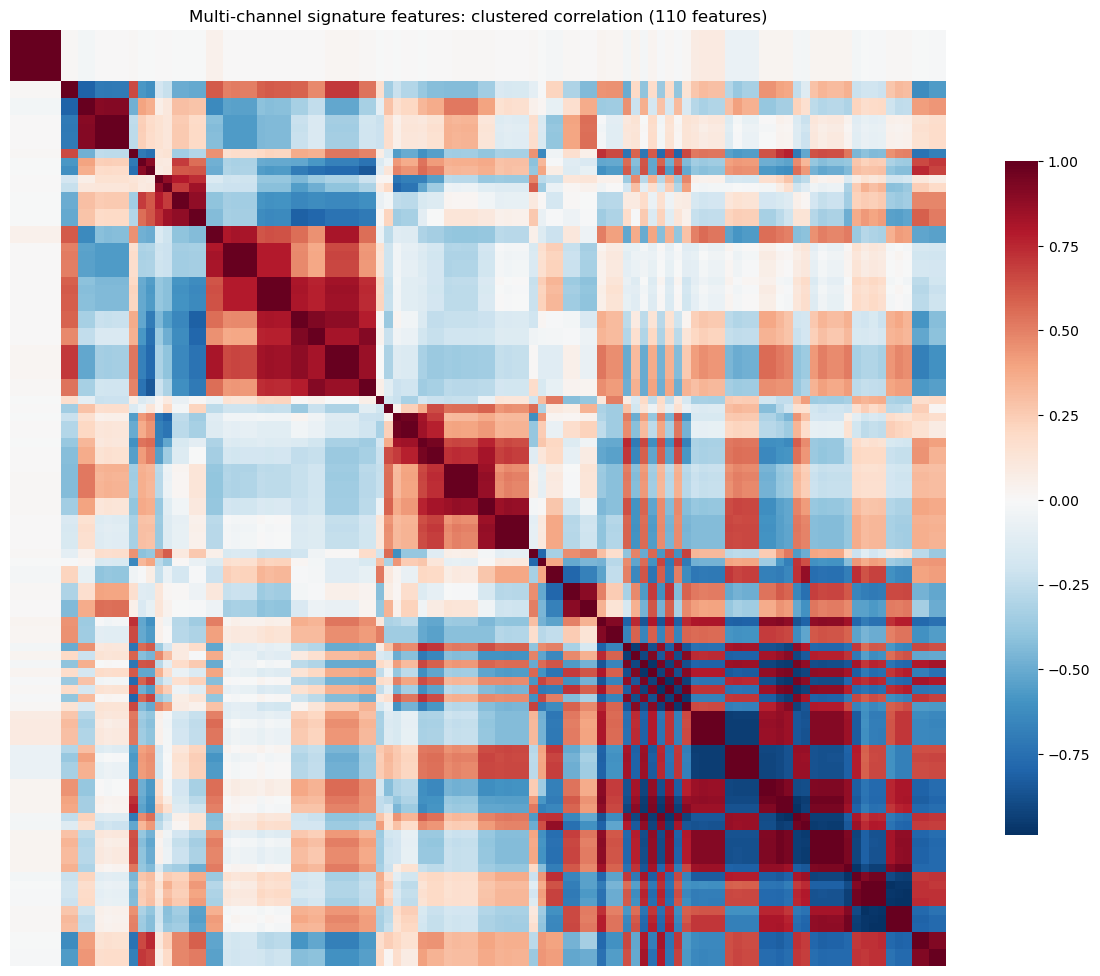

In [119]:
#| echo: false
# Clustered correlation heatmap for multi-channel signatures
X_mc_only = X_mc[mc_sig_cols]

corr_mc = X_mc_only.corr().replace([np.inf, -np.inf], np.nan).fillna(0.0)
dist_mc = 1.0 - np.abs(corr_mc.values)
np.fill_diagonal(dist_mc, 0.0)
dist_mc = np.clip(dist_mc, 0.0, None)
Z_mc = linkage(squareform(dist_mc, checks=False), method="average")
order_mc = leaves_list(Z_mc)
corr_mc_reordered = corr_mc.iloc[order_mc, order_mc]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mc_reordered, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=False, yticklabels=False)
plt.title(f"Multi-channel signature features: clustered correlation ({len(mc_sig_cols)} features)")
plt.tight_layout()
plt.show()

In [120]:
#| code-fold: true
#| code-summary: "Cluster-based selection (multi-channel)"
selected_mc_cols, mc_cluster_map = select_features_by_cluster(
    X_mc, y_base, mc_sig_cols, train_slice=train_sl,
    corr_threshold=0.95, max_features=20,
)

print(f"Multi-channel signature features: {len(mc_sig_cols)}")
print(f"Clusters found: {len(mc_cluster_map)}")
print(f"Selected features (one per cluster): {len(selected_mc_cols)}")
print()

for cid, members in sorted(mc_cluster_map.items(), key=lambda x: -len(x[1])):
    chosen = [m for m in members if m in selected_mc_cols][0]
    if len(members) > 1:
        dropped = [m for m in members if m != chosen]
        print(f"  Cluster {cid} ({len(members)} features): keep {chosen}, drop {dropped}")
    else:
        print(f"  Cluster {cid} (1 feature): keep {chosen}")

  Dropped 4 zero-variance features in training window
  Lowered corr_threshold 0.95 → 0.80 to meet max_features=20 (got 20 clusters)
Multi-channel signature features: 110
Clusters found: 20
Selected features (one per cluster): 20

  Cluster 19 (26 features): keep mcsig.51, drop ['mcsig.30', 'mcsig.35', 'mcsig.39', 'mcsig.40', 'mcsig.45', 'mcsig.49', 'mcsig.50', 'mcsig.55', 'mcsig.56', 'mcsig.57', 'mcsig.58', 'mcsig.59', 'mcsig.74', 'mcsig.80', 'mcsig.84', 'mcsig.85', 'mcsig.90', 'mcsig.94', 'mcsig.95', 'mcsig.100', 'mcsig.102', 'mcsig.103', 'mcsig.104', 'mcsig.105', 'mcsig.106']
  Cluster 11 (14 features): keep mcsig.3, drop ['mcsig.8', 'mcsig.13', 'mcsig.18', 'mcsig.32', 'mcsig.33', 'mcsig.42', 'mcsig.43', 'mcsig.63', 'mcsig.68', 'mcsig.87', 'mcsig.88', 'mcsig.97', 'mcsig.98']
  Cluster 18 (12 features): keep mcsig.82, drop ['mcsig.37', 'mcsig.38', 'mcsig.47', 'mcsig.48', 'mcsig.52', 'mcsig.53', 'mcsig.83', 'mcsig.92', 'mcsig.93', 'mcsig.107', 'mcsig.108']
  Cluster 14 (7 features): k

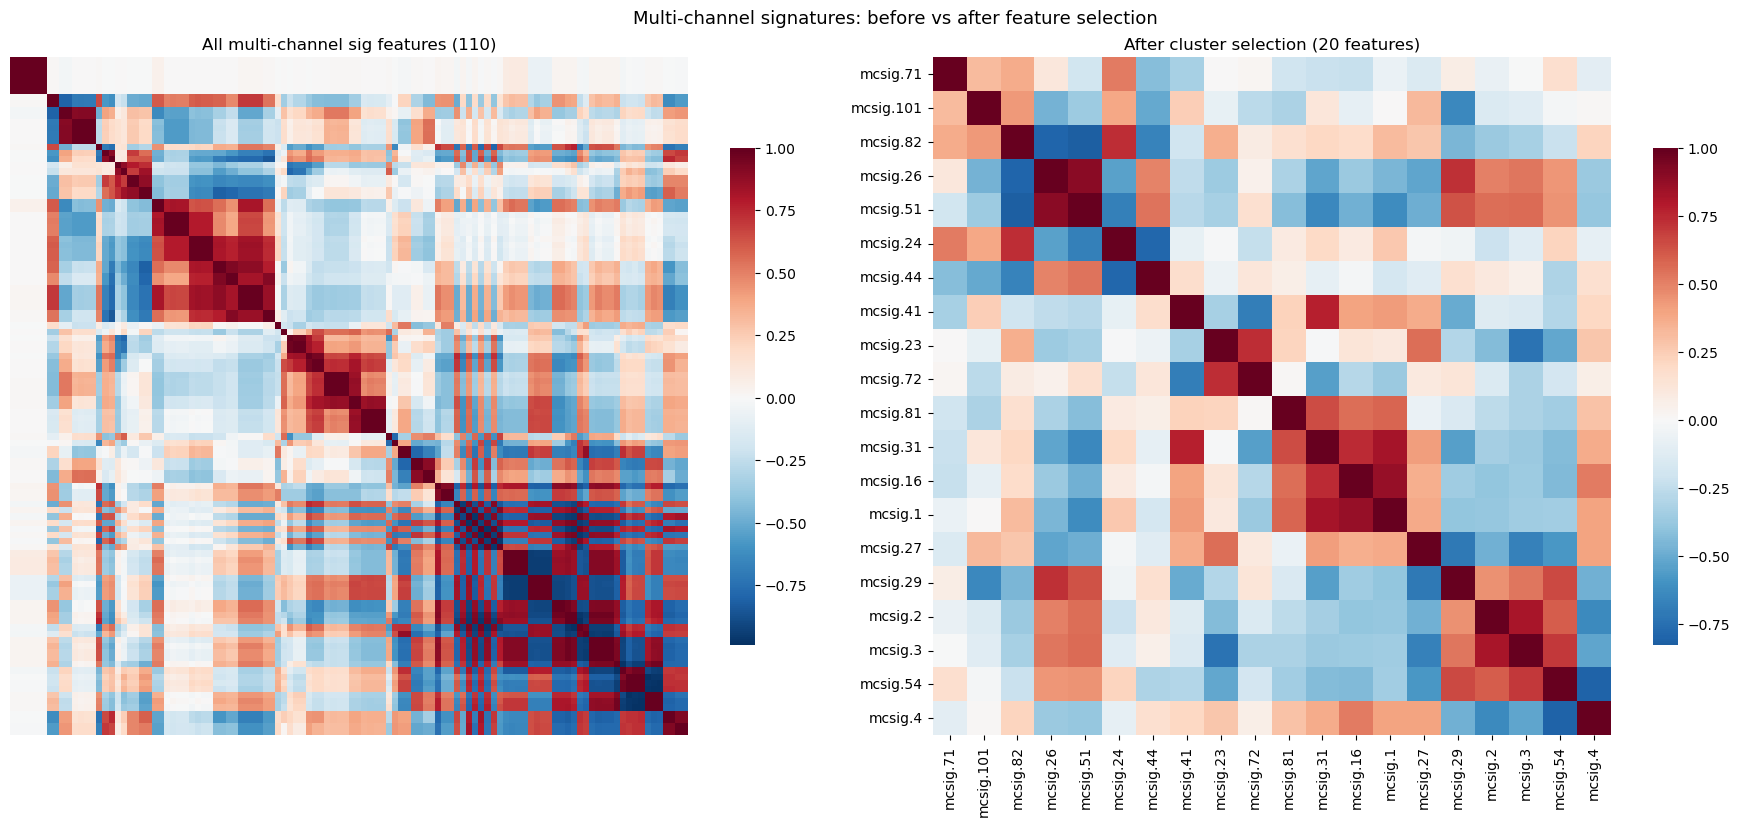

Selected features: 20
Pairs with |corr| >= 0.90: 0


In [121]:
#| code-fold: true
#| code-summary: "Before / after selection heatmap (multi-channel)"
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(corr_mc_reordered, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7}, ax=axes[0],
            xticklabels=False, yticklabels=False)
axes[0].set_title(f"All multi-channel sig features ({len(mc_sig_cols)})")

X_mc_sel = X_mc_only[selected_mc_cols]
corr_mc_sel = X_mc_sel.corr().replace([np.inf, -np.inf], np.nan).fillna(0.0)
if len(selected_mc_cols) > 2:
    dist_mc_sel = 1.0 - np.abs(corr_mc_sel.values)
    np.fill_diagonal(dist_mc_sel, 0.0)
    dist_mc_sel = np.clip(dist_mc_sel, 0.0, None)
    Z_mc_sel = linkage(squareform(dist_mc_sel, checks=False), method="average")
    order_mc_sel = leaves_list(Z_mc_sel)
    corr_mc_sel_reordered = corr_mc_sel.iloc[order_mc_sel, order_mc_sel]
else:
    corr_mc_sel_reordered = corr_mc_sel

sns.heatmap(corr_mc_sel_reordered, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7}, ax=axes[1])
axes[1].set_title(f"After cluster selection ({len(selected_mc_cols)} features)")

plt.suptitle("Multi-channel signatures: before vs after feature selection", fontsize=13)
plt.tight_layout()
plt.show()

upper_mc = corr_mc_sel.where(np.triu(np.ones(corr_mc_sel.shape, dtype=bool), k=1))
pairs_mc = upper_mc.stack().rename("corr").reset_index()
pairs_mc.columns = ["f1", "f2", "corr"]
high_mc = pairs_mc[pairs_mc["corr"].abs() >= 0.90].sort_values("corr", key=abs, ascending=False)
print(f"Selected features: {len(selected_mc_cols)}")
print(f"Pairs with |corr| >= 0.90: {len(high_mc)}")
if len(high_mc):
    display(high_mc)

## Experiment 2: Evaluation

With 20 selected multi-channel features (capped via `max_features`), the correlation threshold auto-adjusted from 0.95 to a lower value to stay within budget. The hypothesis is that cross-channel terms — e.g.\ the iterated integral of price against downside shocks — provide genuinely new information for volatility prediction.

In [151]:
#| echo: false
#| output: false

# Evaluate models with multi-channel signature features
# Now that STESModel uses an analytical Jacobian, STES with 42 features is feasible.
mc_stes_name = "STES_EAESE_SIG_MC"
mc_xgb_name = "XGBSTES_E2E_SIG_MC"

mc_variants = ["ES", "STES_EAESE", mc_stes_name, "XGBSTES_E2E", mc_xgb_name]

# Build dataset with only baseline + selected multi-channel features
X_mc_selected = X_mc[baseline_columns + selected_mc_cols].copy()

mc_extra_cols = {
    mc_stes_name: selected_mc_cols,
    mc_xgb_name: selected_mc_cols,
}

mc_seeds = [0]  # single seed for speed

print(f"Evaluating with {len(selected_mc_cols)} selected multi-channel signature features...")
print(f"Variants: {mc_variants}")
mc_results = evaluate_fixed_split(
    X_mc_selected, y_base, r_base,
    variants=mc_variants,
    seeds=mc_seeds,
    extra_cols_by_variant=mc_extra_cols,
)

mc_results

Evaluating with 20 selected multi-channel signature features...
Variants: ['ES', 'STES_EAESE', 'STES_EAESE_SIG_MC', 'XGBSTES_E2E', 'XGBSTES_E2E_SIG_MC']


,variant,rmse,mae,medae
3,XGBSTES_E2E,0.000443,0.000132,0.000045
1,STES_EAESE,0.000448,0.000138,0.000051
4,XGBSTES_E2E_SIG_MC,0.000458,0.000132,0.000043
0,ES,0.000464,0.000140,0.000050
2,STES_EAESE_SIG_MC,0.000465,0.000134,0.000046


In [152]:
#| echo: false
display(style_results_table(mc_results))

,rmse,mae,medae
variant,,,
XGBSTES_E2E,0.000443,0.000132,0.000045
STES_EAESE,0.000448,0.000138,0.000051
XGBSTES_E2E_SIG_MC,0.000458,0.000132,0.000043
ES,0.000464,0.000140,0.000050
STES_EAESE_SIG_MC,0.000465,0.000134,0.000046


We see the same pattern as in the single-channel case. Including signature features on the multi-channel path yields no improvement. Despite encoding cross-channel interactions (leverage effect, volatility clustering), the multi-channel signatures add noise rather than signal. The baseline models remain dominant.

### Diagnosing via $\alpha_t$ Paths (Multi-Channel)

As with Experiment 1, we overlay the predicted $\alpha_t$ with and without multi-channel signature features. The same pattern emerges: the signature-augmented paths are noisier without being more accurate. Moreover, for the XGBoost-STES model, there is a significant $\alpha$ level shift. This could reflect a mix of score-distribution rebalancing (signatures change the mean/variance of $z_t$) and training path dependence in the end-to-end fit.

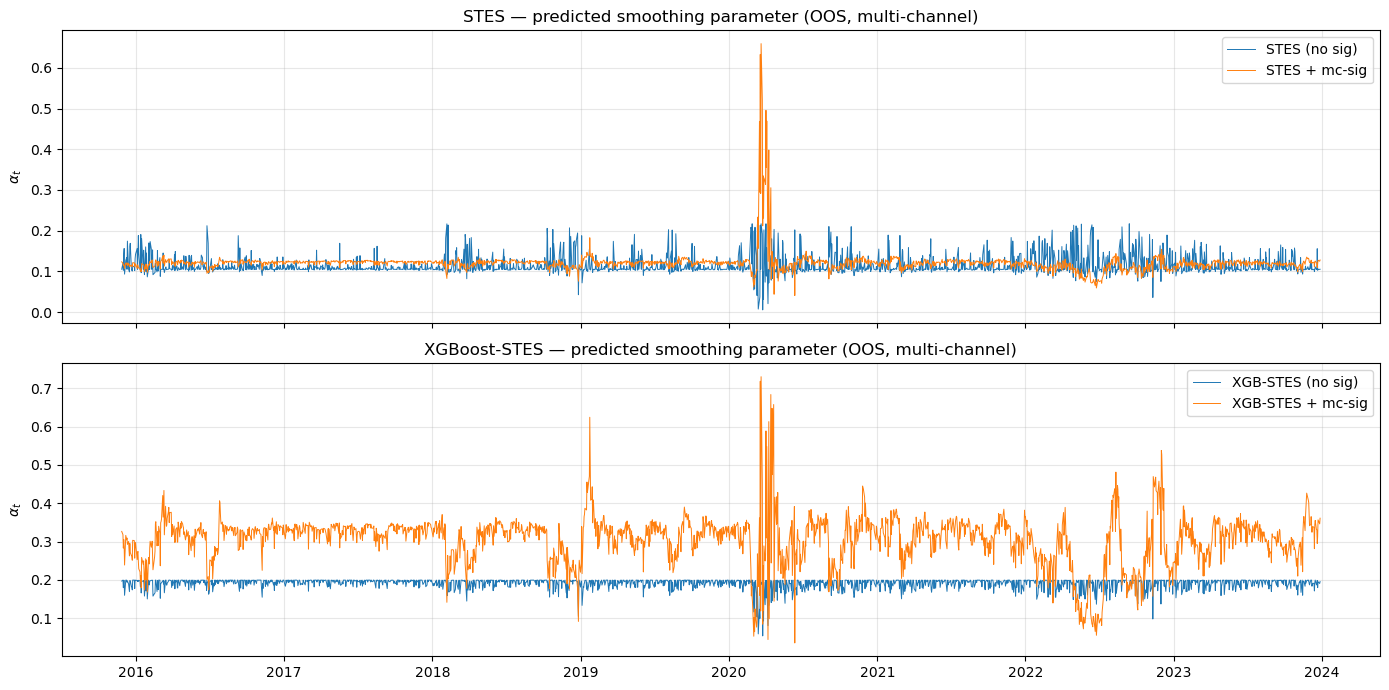

In [156]:
#| code-fold: true
#| code-summary: "Alpha path comparison plot (multi-channel)"
train_slice = slice(SPY_IS_INDEX, SPY_OS_INDEX)
test_slice  = slice(SPY_OS_INDEX, len(y_base))

mc_alpha_variants = {
    "STES (no sig)":       dict(variant="STES_EAESE",  extra_cols=None),
    "STES + mc-sig":       dict(variant=mc_stes_name,   extra_cols=selected_mc_cols),
    "XGB-STES (no sig)":   dict(variant="XGBSTES_E2E", extra_cols=None),
    "XGB-STES + mc-sig":   dict(variant=mc_xgb_name,    extra_cols=selected_mc_cols),
}

mc_alphas = {}
for label, kw in mc_alpha_variants.items():
    _, _, alpha = _fit_predict_oos(
        X=X_mc_selected, y=y_base, r=r_base,
        train_slice=train_slice, test_slice=test_slice,
        seed=0, return_alpha=True, **kw,
    )
    mc_alphas[label] = alpha.iloc[SPY_OS_INDEX - SPY_IS_INDEX :]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for label in ["STES (no sig)", "STES + mc-sig"]:
    axes[0].plot(mc_alphas[label].index, mc_alphas[label].values, label=label, linewidth=0.7)
axes[0].set_ylabel(r"$\alpha_t$")
axes[0].set_title("STES — predicted smoothing parameter (OOS, multi-channel)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for label in ["XGB-STES (no sig)", "XGB-STES + mc-sig"]:
    axes[1].plot(mc_alphas[label].index, mc_alphas[label].values, label=label, linewidth=0.7)
axes[1].set_ylabel(r"$\alpha_t$")
axes[1].set_title("XGBoost-STES — predicted smoothing parameter (OOS, multi-channel)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Feature Redundancy and Regularization

Both experiments show that including signatures degrades out-of-sample forecasts. Since the baseline model is nested within the augmented model (set signature coefficients to zero), any degradation must come from estimation/regularization/optimization rather than from a hard restriction of the feature set. We investigate three potential mechanisms: (i) signature features may be redundant with baseline features; (ii) the STES regularization architecture distorts baseline weights; and (iii) the XGBoost linear booster assigns excessive weight to noisy signature features.

### Cross-Correlation with Baseline Features

If signature features are strongly correlated with the existing baseline features — lagged log-return, absolute log-return, and squared log-return — then adding them provides little novel information while increasing estimation noise. The heatmap below shows the training-set cross-correlation between the six selected single-channel signature features and the three baseline features. Several of the signature features exhibit correlations exceeding 30% with the baseline features.

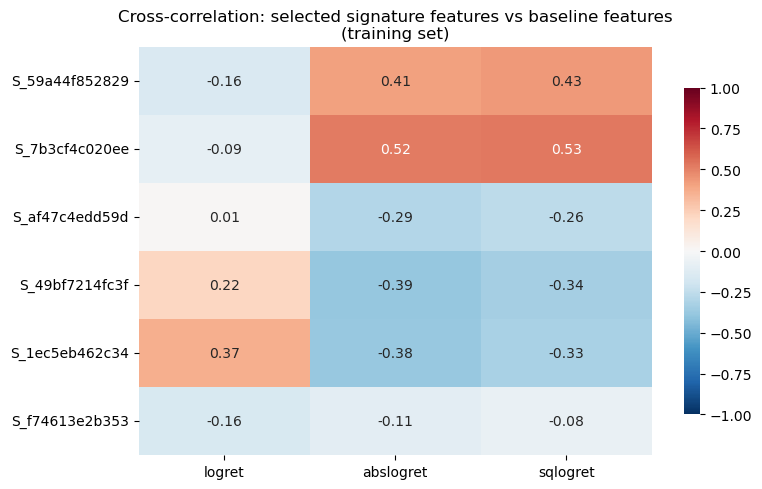


Pairs with |corr| > 0.3:
  sig.2.59a44f852829 <-> lag.abslogret.1ad490bcb584: 0.413
  sig.2.59a44f852829 <-> lag.sqlogret.c2cf3aa70c10: 0.432
  sig.2.7b3cf4c020ee <-> lag.abslogret.1ad490bcb584: 0.520
  sig.2.7b3cf4c020ee <-> lag.sqlogret.c2cf3aa70c10: 0.527
  sig.2.49bf7214fc3f <-> lag.abslogret.1ad490bcb584: -0.387
  sig.2.49bf7214fc3f <-> lag.sqlogret.c2cf3aa70c10: -0.339
  sig.2.1ec5eb462c34 <-> lag.logret.fc5d3612d9c7: 0.366
  sig.2.1ec5eb462c34 <-> lag.abslogret.1ad490bcb584: -0.379
  sig.2.1ec5eb462c34 <-> lag.sqlogret.c2cf3aa70c10: -0.327

Max |cross-corr|: 0.527


In [125]:
#| code-fold: true
#| code-summary: "Cross-correlation heatmap: signature vs baseline features"
baseline_feat_cols = [c for c in baseline_columns if c != "const"]
train_sl_diag = slice(SPY_IS_INDEX, SPY_OS_INDEX)

# X_sig has both baseline + sig columns
all_cols = baseline_feat_cols + selected_sig_cols
cross_corr = X_sig[all_cols].iloc[train_sl_diag].corr()
cross_block = cross_corr.loc[selected_sig_cols, baseline_feat_cols]

# Short labels for display
short_base = {c: c.split(".")[1][:12] for c in baseline_feat_cols}
short_sig = {c: c.replace("sig.2.", "S_")[:14] for c in selected_sig_cols}

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    cross_block.rename(index=short_sig, columns=short_base),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    ax=ax, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
)
ax.set_title("Cross-correlation: selected signature features vs baseline features\n(training set)")
plt.tight_layout()
plt.show()

# Flag notable correlations
print("\nPairs with |corr| > 0.3:")
for sig_col in selected_sig_cols:
    for base_col in baseline_feat_cols:
        c = cross_block.loc[sig_col, base_col]
        if abs(c) > 0.3:
            print(f"  {sig_col} <-> {base_col}: {c:.3f}")

max_abs = cross_block.abs().max().max()
print(f"\nMax |cross-corr|: {max_abs:.3f}")

### Weight Distortion Under Uniform L2

The STES model uses L2 regularization to prevent overfitting when extra features are added. Cross-validation selects a penalty $\lambda$ large enough to suppress the noisy signature coefficients, but a uniform penalty simultaneously shrinks the three baseline feature weights. This is a standard bias–variance tradeoff in ridge regression: the penalty shrinks *all* coefficients toward zero, so a $\lambda$ chosen to neutralize a noisy feature block can also move well-tuned baseline coefficients away from their near-optimal values.

::: {.callout-note}
**Why L2 shrinkage hits some directions harder (SVD intuition).** In the linear model $y = X\beta + \varepsilon$, write $X = U\Sigma V^\top$ (SVD). Ridge shrinks the OLS coefficients in the right-singular-vector basis:
$$
\hat\beta^{\mathrm{ridge}} = V\,\mathrm{diag}\!\left(\frac{s_j^2}{s_j^2+\lambda}\right)V^\top\hat\beta^{\mathrm{OLS}}.
$$
Directions with small singular values $s_j$ (weakly identified directions of $X$) are shrunk the most. Adding many correlated signature features tends to introduce such weak directions, so the same $\lambda$ that stabilizes the signature block can spill over and attenuate baseline directions as well.
:::

The table below compares the fitted $\beta$ vectors with and without signature features, and reveals that the baseline weights shift by 88–103% when signatures are added.

The regularization path sweeps $\lambda$ from $10^{-3}$ to $10^{2}$. The characteristic U-shaped RMSE indicates that too little penalty allows signature noise to dominate, while too much penalty suppresses the baseline weights below their optima.

In [189]:
#| code-fold: true
#| code-summary: "STES fitted parameter comparison"
train_slice = slice(SPY_IS_INDEX, SPY_OS_INDEX)
test_slice = slice(SPY_OS_INDEX, len(y_base))

# ---- Baseline STES ----
cols_stes_base = select_variant_columns(X_base, "STES_EAESE") or ["const"]
X_sel_stes_base = X_base[cols_stes_base]
X_tr_stes_base, X_te_stes_base = _scale_train_test(X_sel_stes_base, train_slice, test_slice)
y_tr = y_base.iloc[train_slice]
r_tr = r_base.iloc[train_slice]

model_stes_base = STESModel(random_state=0)
model_stes_base.fit(X_tr_stes_base, y_tr, returns=r_tr, start_index=0, end_index=len(X_tr_stes_base))

# ---- STES + single-channel sig (with uniform L2 CV) ----
cols_stes_sig = [c for c in select_variant_columns(X_sig, "STES_EAESE") if not _is_signature_col(c)]
cols_stes_sig = cols_stes_sig + [c for c in selected_sig_cols if c not in set(cols_stes_sig)]
X_sel_stes_sig = X_sig[cols_stes_sig]
X_tr_stes_sig, X_te_stes_sig = _scale_train_test(X_sel_stes_sig, train_slice, test_slice)

l2_grid = [{"l2_reg": 0.0}, {"l2_reg": 0.01}, {"l2_reg": 0.1}, {"l2_reg": 1.0}, {"l2_reg": 10.0}]
model_stes_sig = STESModel(random_state=0)
model_stes_sig.fit(
    X_tr_stes_sig, y_tr, returns=r_tr,
    start_index=0, end_index=len(X_tr_stes_sig),
    perform_cv=True, cv_grid=l2_grid, cv_splits=5,
 )

# ---- Compact comparison table ----
base_df = pd.DataFrame({"feature": cols_stes_base, "beta_base": model_stes_base.params})
aug_df = pd.DataFrame({"feature": cols_stes_sig, "beta_aug": model_stes_sig.params})
cmp = base_df.merge(aug_df, on="feature", how="outer")
cmp["group"] = np.where(
    cmp["feature"].apply(_is_signature_col),
    "sig",
    np.where(cmp["feature"] == "const", "const", "base"),
 )
cmp["delta"] = cmp["beta_aug"] - cmp["beta_base"]
cmp["delta_pct"] = np.where(
    cmp["beta_base"].abs() > 1e-10,
    cmp["delta"] / cmp["beta_base"].abs() * 100.0,
    np.nan,
 )
_grp_ord = {"const": 0, "base": 1, "sig": 2}
cmp["_ord"] = cmp["group"].map(_grp_ord).fillna(9)
cmp = cmp.sort_values(["_ord", "feature"]).drop(columns=["_ord"])
display(cmp)

# Evaluate OOS RMSE for both
y_te = y_base.iloc[test_slice]
r_te = r_base.iloc[test_slice]

X_all_base = pd.concat([X_tr_stes_base, X_te_stes_base])
r_all = pd.concat([r_tr, r_te])
yhat_base_all = model_stes_base.predict(X_all_base, returns=r_all)
yhat_base_os = np.asarray(yhat_base_all)[len(X_tr_stes_base):]

X_all_sig = pd.concat([X_tr_stes_sig, X_te_stes_sig])
yhat_sig_all = model_stes_sig.predict(X_all_sig, returns=r_all)
yhat_sig_os = np.asarray(yhat_sig_all)[len(X_tr_stes_sig):]

rmse_base = calc_rmse(y_te.values, yhat_base_os)
rmse_sig = calc_rmse(y_te.values, yhat_sig_os)
print(f"\nOut-of-sample RMSE")
print(f"  Baseline STES:    {rmse_base:.6f}")
print(f"  STES + Sig (L2):  {rmse_sig:.6f}")
print(f"  Δ RMSE:           {rmse_sig - rmse_base:+.6f} ({(rmse_sig/rmse_base - 1)*100:+.2f}%)")

,feature,beta_base,beta_aug,group,delta,delta_pct
0,const,-2.047842,-1.790887,const,0.256955,12.547608
1,lag.abslogret.1ad490bcb584,0.187659,-0.005155,base,-0.192814,-102.747079
2,lag.logret.fc5d3612d9c7,-0.233339,-0.027293,base,0.206045,88.303181
3,lag.sqlogret.c2cf3aa70c10,-0.242507,-0.026775,base,0.215731,88.958876
4,sig.2.1ec5eb462c34,NaN,-0.001731,sig,NaN,NaN
5,sig.2.49bf7214fc3f,NaN,-0.000093,sig,NaN,NaN
6,sig.2.59a44f852829,NaN,-0.001720,sig,NaN,NaN
7,sig.2.7b3cf4c020ee,NaN,-0.009756,sig,NaN,NaN
8,sig.2.af47c4edd59d,NaN,0.001566,sig,NaN,NaN
9,sig.2.f74613e2b353,NaN,0.015328,sig,NaN,NaN



Out-of-sample RMSE
  Baseline STES:    0.000448
  STES + Sig (L2):  0.000451
  Δ RMSE:           +0.000003 (+0.59%)


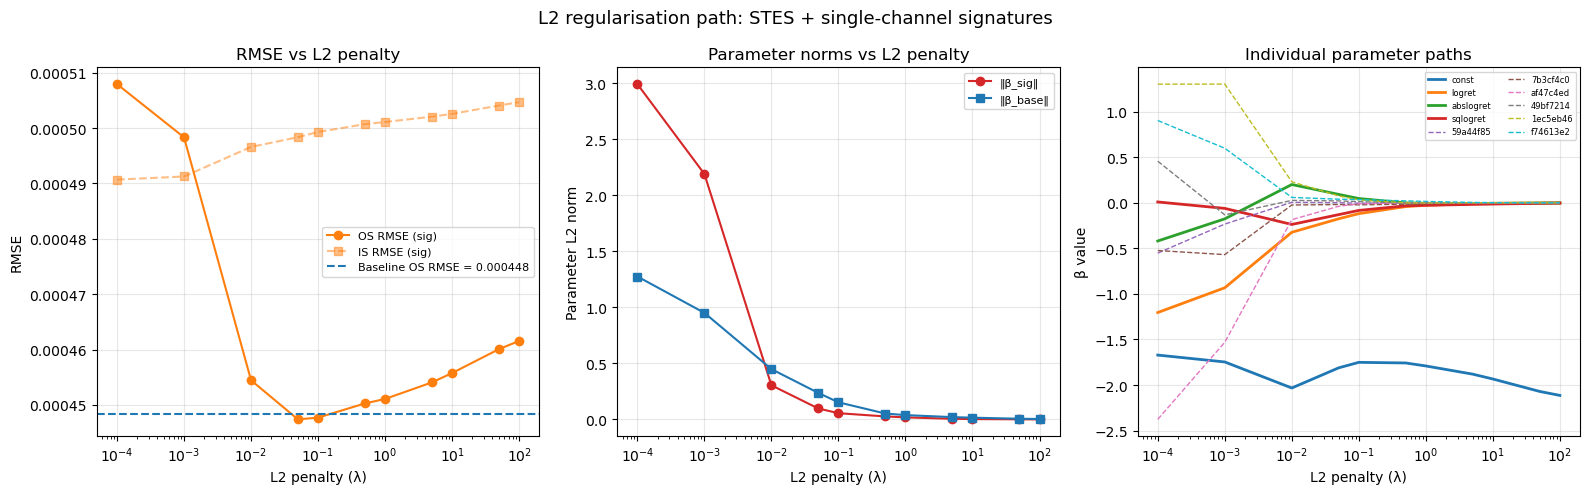


      L2     OS RMSE     IS RMSE     ‖β_sig‖    ‖β_base‖       const
   0.000    0.000508    0.000491    2.991787    1.275177     -1.6714
   0.001    0.000498    0.000491    2.189706    0.950782     -1.7469
   0.010    0.000454    0.000497    0.304377    0.448713     -2.0327
   0.050    0.000447    0.000498    0.097777    0.236692     -1.8117
   0.100    0.000448    0.000499    0.055606    0.152607     -1.7512
   0.500    0.000450    0.000501    0.026835    0.052670     -1.7580
   1.000    0.000451    0.000501    0.018400    0.038580     -1.7909 ← CV
   5.000    0.000454    0.000502    0.005564    0.020700     -1.8807
  10.000    0.000456    0.000503    0.003151    0.015572     -1.9340
  50.000    0.000460    0.000504    0.001056    0.006224     -2.0706
 100.000    0.000462    0.000505    0.000630    0.003671     -2.1143

Baseline OS RMSE (no sig): 0.000448
Best augmented OS RMSE:    0.000447 at λ=0.050


In [127]:
#| code-fold: true
#| code-summary: "L2 regularization path"
l2_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

path_results = []
path_params = {c: [] for c in cols_stes_sig}

for l2 in l2_values:
    model = STESModel(random_state=0, l2_reg=l2)
    model.fit(X_tr_stes_sig, y_tr, returns=r_tr, start_index=0, end_index=len(X_tr_stes_sig))

    # OOS prediction
    yhat_all = model.predict(X_all_sig, returns=r_all)
    yhat_os = np.asarray(yhat_all)[len(X_tr_stes_sig):]
    rmse_os = calc_rmse(y_te.values, yhat_os)

    # IS prediction
    yhat_is = np.asarray(yhat_all)[:len(X_tr_stes_sig)]
    rmse_is = calc_rmse(y_tr.values, yhat_is)

    # Parameter norms
    sig_params = [p for c, p in zip(cols_stes_sig, model.params) if _is_signature_col(c)]
    base_params = [p for c, p in zip(cols_stes_sig, model.params) if not _is_signature_col(c) and c != "const"]
    const_param = [p for c, p in zip(cols_stes_sig, model.params) if c == "const"]

    for c, p in zip(cols_stes_sig, model.params):
        path_params[c].append(p)

    path_results.append({
        "l2": l2,
        "rmse_os": rmse_os,
        "rmse_is": rmse_is,
        "norm_sig": np.sqrt(np.sum(np.array(sig_params)**2)),
        "norm_base": np.sqrt(np.sum(np.array(base_params)**2)),
        "const": const_param[0] if const_param else np.nan,
    })

path_df = pd.DataFrame(path_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: RMSE vs L2
ax = axes[0]
ax.semilogx(path_df["l2"].replace(0, 1e-4), path_df["rmse_os"], "o-", label="OS RMSE (sig)", color="C1")
ax.semilogx(path_df["l2"].replace(0, 1e-4), path_df["rmse_is"], "s--", label="IS RMSE (sig)", color="C1", alpha=0.5)
ax.axhline(rmse_base, color="C0", ls="--", lw=1.5, label=f"Baseline OS RMSE = {rmse_base:.6f}")
ax.set_xlabel("L2 penalty (λ)")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs L2 penalty")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Parameter norms
ax = axes[1]
ax.semilogx(path_df["l2"].replace(0, 1e-4), path_df["norm_sig"], "o-", label="‖β_sig‖", color="C3")
ax.semilogx(path_df["l2"].replace(0, 1e-4), path_df["norm_base"], "s-", label="‖β_base‖", color="C0")
ax.set_xlabel("L2 penalty (λ)")
ax.set_ylabel("Parameter L2 norm")
ax.set_title("Parameter norms vs L2 penalty")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Individual parameter paths
ax = axes[2]
l2_plot = [max(v, 1e-4) for v in l2_values]
for c in cols_stes_sig:
    is_sig = _is_signature_col(c)
    style = "--" if is_sig else "-"
    lw = 1 if is_sig else 2
    parts = c.split(".")
    short = parts[-1][:8] if is_sig else (parts[1][:10] if len(parts) > 1 else c[:10])
    ax.semilogx(l2_plot, path_params[c], style, lw=lw, label=short)
ax.set_xlabel("L2 penalty (λ)")
ax.set_ylabel("β value")
ax.set_title("Individual parameter paths")
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle("L2 regularization path: STES + single-channel signatures", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'L2':>8s}  {'OS RMSE':>10s}  {'IS RMSE':>10s}  {'‖β_sig‖':>10s}  {'‖β_base‖':>10s}  {'const':>10s}")
for _, row in path_df.iterrows():
    marker = " ← CV" if row["l2"] == model_stes_sig.l2_reg else ""
    print(f"{row['l2']:>8.3f}  {row['rmse_os']:>10.6f}  {row['rmse_is']:>10.6f}  {row['norm_sig']:>10.6f}  {row['norm_base']:>10.6f}  {row['const']:>10.4f}{marker}")
print(f"\nBaseline OS RMSE (no sig): {rmse_base:.6f}")
print(f"Best augmented OS RMSE:    {path_df['rmse_os'].min():.6f} at λ={path_df.loc[path_df['rmse_os'].idxmin(), 'l2']:.3f}")

### Recovering the Baseline with Group-Specific Regularization

Our initial STES model penalizes every feature, including the baseline parameters. If we instead penalize only the signature features while leaving the baseline weights free, the results differ. With this group-specific penalty ($\lambda_{\text{base}} = 0$, $\lambda_{\text{sig}}$ varies), the augmented model converges to the exact baseline RMSE as $\lambda_{\text{sig}} \to \infty$ — the baseline is correctly recovered as a limiting case. At intermediate $\lambda_{\text{sig}}$, the augmented model performs on par with the baseline but does not improve upon it.

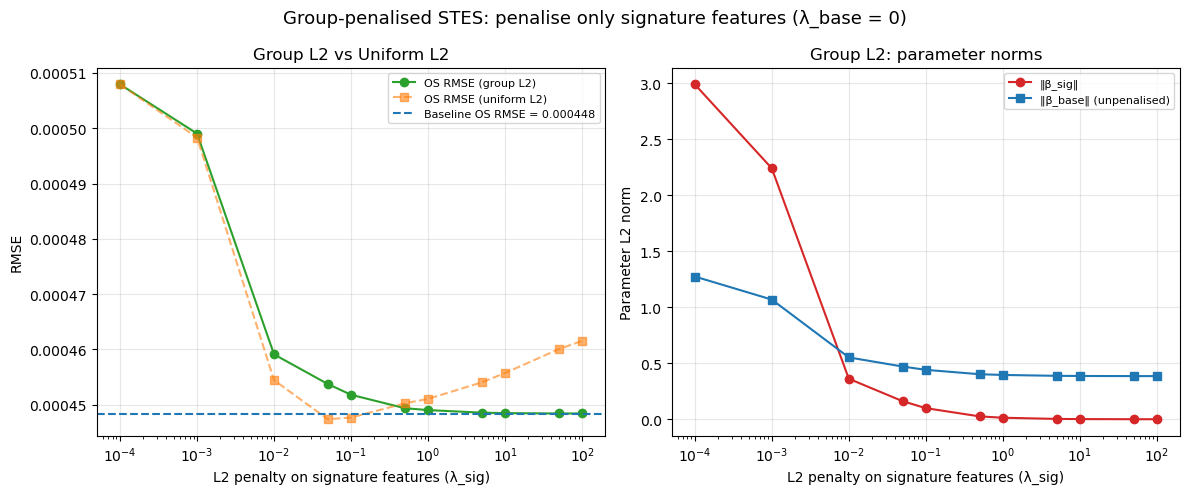


   λ_sig     OS RMSE     ‖β_sig‖    ‖β_base‖
   0.000    0.000508    2.991787    1.275177
   0.001    0.000499    2.241665    1.069158
   0.010    0.000459    0.361808    0.552437
   0.050    0.000454    0.161420    0.471019
   0.100    0.000452    0.099237    0.441396
   0.500    0.000449    0.025562    0.402262
   1.000    0.000449    0.013593    0.395792
   5.000    0.000449    0.003063    0.387937
  10.000    0.000448    0.001591    0.386583
  50.000    0.000448    0.000333    0.385495
 100.000    0.000448    0.000168    0.385462

Baseline OS RMSE: 0.000448
Best group-L2 OS RMSE: 0.000448 at λ_sig=100.000


In [ ]:
#| code-fold: true
#| code-summary: "Group-penalized STES: λ_base = 0, λ_sig varies"
def fit_stes_group_l2(X_tr, y_tr, r_tr, cols, l2_sig, l2_base=0.0, seed=0):
    """Fit STES with group-specific L2 penalties."""
    X_np = X_tr.values.astype(float)
    y_np = y_tr.values.astype(float)
    r_np = r_tr.values.astype(float)
    n, p = X_np.shape

    # Build group penalty vector
    mask = np.zeros(p)
    for i, c in enumerate(cols):
        if _is_signature_col(c):
            mask[i] = l2_sig
        elif c != "const":
            mask[i] = l2_base

    scale = np.linalg.norm(y_np)
    penalty_vec = np.sqrt(mask) * scale if np.any(mask > 0) else None

    rng = np.random.default_rng(seed)
    x0 = rng.normal(0, 1, size=p)

    result = least_squares(
        STESModel._objective, x0=x0, jac=STESModel._jacobian,
        args=(r_np, X_np, y_np, 0, len(X_np), penalty_vec),
    )
    return result.x

# Sweep l2_sig with l2_base = 0
l2_sig_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

group_results = []
for l2_sig in l2_sig_values:
    params = fit_stes_group_l2(X_tr_stes_sig, y_tr, r_tr, cols_stes_sig, l2_sig=l2_sig, l2_base=0.0)

    # Predict
    alphas = expit(X_all_sig.values @ params)
    r_all_np = r_all.values
    returns2 = r_all_np**2
    n = len(r_all_np)
    v = np.empty(n + 1)
    v[0] = returns2[0]
    yhat = np.empty(n)
    for t in range(n):
        yhat[t] = alphas[t] * returns2[t] + (1 - alphas[t]) * v[t]
        v[t + 1] = yhat[t]

    yhat_os = yhat[len(X_tr_stes_sig):]
    rmse_os = calc_rmse(y_te.values, yhat_os)

    sig_params = [p for c, p in zip(cols_stes_sig, params) if _is_signature_col(c)]
    base_params = [p for c, p in zip(cols_stes_sig, params) if not _is_signature_col(c) and c != "const"]

    group_results.append({
        "l2_sig": l2_sig,
        "rmse_os": rmse_os,
        "norm_sig": np.sqrt(np.sum(np.array(sig_params)**2)),
        "norm_base": np.sqrt(np.sum(np.array(base_params)**2)),
    })

group_df = pd.DataFrame(group_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.semilogx(group_df["l2_sig"].replace(0, 1e-4), group_df["rmse_os"], "o-", label="OS RMSE (group L2)", color="C2")
ax.semilogx(path_df["l2"].replace(0, 1e-4), path_df["rmse_os"], "s--", label="OS RMSE (uniform L2)", color="C1", alpha=0.6)
ax.axhline(rmse_base, color="C0", ls="--", lw=1.5, label=f"Baseline OS RMSE = {rmse_base:.6f}")
ax.set_xlabel("L2 penalty on signature features (λ_sig)")
ax.set_ylabel("RMSE")
ax.set_title("Group L2 vs Uniform L2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(group_df["l2_sig"].replace(0, 1e-4), group_df["norm_sig"], "o-", label="‖β_sig‖", color="C3")
ax.semilogx(group_df["l2_sig"].replace(0, 1e-4), group_df["norm_base"], "s-", label="‖β_base‖ (unpenalized)", color="C0")
ax.set_xlabel("L2 penalty on signature features (λ_sig)")
ax.set_ylabel("Parameter L2 norm")
ax.set_title("Group L2: parameter norms")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Group-penalized STES: penalize only signature features (λ_base = 0)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'λ_sig':>8s}  {'OS RMSE':>10s}  {'‖β_sig‖':>10s}  {'‖β_base‖':>10s}")
for _, row in group_df.iterrows():
    print(f"{row['l2_sig']:>8.3f}  {row['rmse_os']:>10.6f}  {row['norm_sig']:>10.6f}  {row['norm_base']:>10.6f}")
print(f"\nBaseline OS RMSE: {rmse_base:.6f}")
print(f"Best group-L2 OS RMSE: {group_df['rmse_os'].min():.6f} at λ_sig={group_df.loc[group_df['rmse_os'].idxmin(), 'l2_sig']:.3f}")


We noted that even the best regularized OOS RMSE under both regularization schemes is only on par with the baseline model, suggesting that level-2 signature features from the rolling 20-day window offer little residual value. This outcome is expected once we consider two properties of the volatility process:

1. **Volatility exhibits long memory.** Empirically, autocorrelations of $|r_t|$ and $r_t^2$ decay slowly, so relevant dependence can extend across multiple horizons (weeks to months). A single 20-day rolling window is a local functional, so it can easily miss longer-horizon regime information.

::: {.callout-note}
**Can any finite “path compression” be sufficient under fractional (power-law) memory?** If the conditional variance behaves like a fractionally integrated process (equivalently, it admits a representation with a power-law kernel / fractional differencing), then the optimal predictor generally depends on an unbounded history: power-law memory is not exactly Markov in any finite dimension. In that sense there is no *exact* finite-dimensional state that is sufficient for prediction. What practitioners do instead is approximate the long-memory kernel over the horizon that matters (e.g. months) with a *finite* set of summaries: HAR-style components (daily/weekly/monthly realized variance), or a small bank of EWMAs with different half-lives (a mixture-of-exponentials approximation to a power-law kernel), or truncated fractional differencing weights.
:::

In our setup, STES already maintains an exponentially weighted summary of past $r_t^2$ through $v_{t+1} = v_t + \alpha_t(r_t^2 - v_t)$; adding a 20-day signature window is therefore not obviously adding a longer-memory statistic. If anything, it injects a shorter-horizon summary alongside a model state that already aggregates the full past (with exponential forgetting).

2. **Low-order signatures re-encode moment information.** With truncation at level 2 and augmentations like lead–lag and addtime, most signature coordinates are algebraically related to first- and second-order path statistics such as cumulative return, quadratic variation, and their cross-terms. The baseline already includes $r_t$, $|r_t|$, and $r_t^2$, which are direct proxies for these quantities. The cross-correlation heatmap above shows that selected signature features have $|\rho|$ up to 0.53 with baseline features. Any genuinely novel content, such as the sequencing and smoothness of returns within the window, is too weak at daily frequency to overcome the statistical cost of additional parameters.

### XGBoost Feature Weights

For the `gblinear` booster, each boosting round fits an additive **linear** update to the prediction. After $M$ rounds the model output is

$$
\hat{y}(\mathbf{x}) \;=\; b + \sum_{j=1}^{p} w_j\, x_j,
$$

where $b$ is the bias (intercept) and $\mathbf{w} = (w_1,\dots,w_p)$ are the feature weights accumulated across all rounds via coordinate descent, each shrunk by the L2 penalty `reg_lambda`. Because the input features are standardized (zero mean, unit variance) before fitting, the absolute weight $|w_j|$ is directly comparable across features and serves as a natural measure of importance: a larger $|w_j|$ means feature $j$ contributes more to the smoothing-parameter prediction inside XGBoost-STES.

The bar chart below displays these weights, colour-coded by feature group (blue = baseline, red = signature).

                                   Feature    Baseline       + Sig          Δw        Δ%
--------------------------------------------------------------------------------------
                   lag.logret.fc5d3612d9c7   -0.084265   -0.121535   -0.037270    +44.2%
                lag.abslogret.1ad490bcb584   -0.060445   -0.038866   +0.021579    -35.7%
                 lag.sqlogret.c2cf3aa70c10   -0.025341   -0.027290   -0.001949     +7.7%
                                      bias   -1.951480   -1.808500   +0.142980

                        sig.2.59a44f852829           —   -0.023961   ← SIG
                        sig.2.7b3cf4c020ee           —   -0.050910   ← SIG
                        sig.2.af47c4edd59d           —    0.026128   ← SIG
                        sig.2.49bf7214fc3f           —    0.060890   ← SIG
                        sig.2.1ec5eb462c34           —    0.055686   ← SIG
                        sig.2.f74613e2b353           —    0.109561   ← SIG


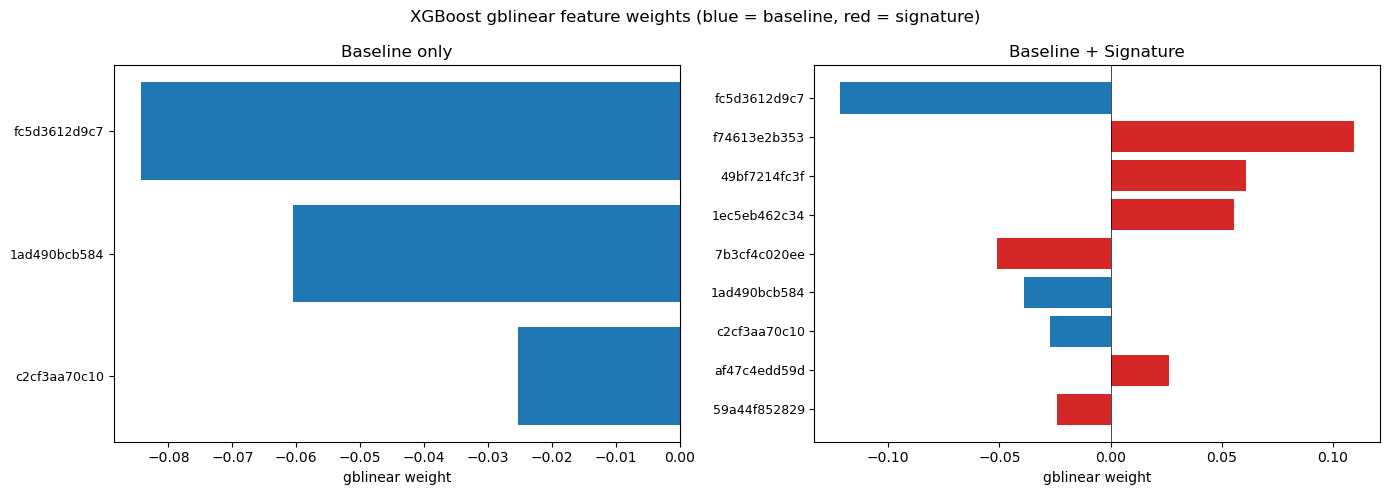


reg_lambda: 1.0


In [ ]:
#| code-fold: true
#| code-summary: "XGBoost gblinear feature weight extraction"
grid_e2e = [
    {"min_child_weight": 5.0, "learning_rate": 0.05, "max_depth": 3},
    {"min_child_weight": 20.0, "learning_rate": 0.1, "max_depth": 3},
    {"min_child_weight": 50.0, "learning_rate": 0.05, "max_depth": 2},
]

r_tr_scaled = r_tr * SCALE_FACTOR
y_tr_scaled = y_tr * (SCALE_FACTOR**2)

def _parse_gblinear_dump(dump_str):
    """Parse gblinear dump → (bias, {feature_index: weight})."""
    raw = dump_str.strip()
    bias_sec, weight_sec = raw.split("weight:")
    bias = float(bias_sec.replace("bias:", "").strip())
    weights = [float(v) for v in weight_sec.strip().split("\n")]
    return bias, weights

# ── 1) Baseline-only model ─────────────────────────────────────────
# Drop 'const' — gblinear has its own unpenalized bias term
cols_base_xgb = [c for c in baseline_columns if c != "const"]
X_sel_base = X_base[cols_base_xgb]
X_tr_base, X_te_base = _scale_train_test(X_sel_base, train_slice, test_slice)

over = _xgb_variant_overrides("XGBSTES_E2E", cols_base_xgb)
model_xgb_base = _make_xgb_stes_model(seed=None, **over)
model_xgb_base.fit(
    X_tr_base, y_tr_scaled, returns=r_tr_scaled,
    perform_cv=True, cv_grid=grid_e2e, cv_splits=5,
    start_index=0, end_index=len(X_tr_base),
)
bias_base, weights_base = _parse_gblinear_dump(model_xgb_base.model_.get_dump()[0])
assert len(weights_base) == len(cols_base_xgb)
w_base = dict(zip(cols_base_xgb, weights_base))

cols_xgb_sig = [c for c in baseline_columns + selected_sig_cols if c != "const"]
X_sel_xgb_sig = X_sig[cols_xgb_sig]
X_tr_xgb_sig, X_te_xgb_sig = _scale_train_test(X_sel_xgb_sig, train_slice, test_slice)

over_sig = _xgb_variant_overrides("XGBSTES_E2E", cols_xgb_sig)
model_xgb_sig = _make_xgb_stes_model(seed=None, **over_sig)
model_xgb_sig.fit(
    X_tr_xgb_sig, y_tr_scaled, returns=r_tr_scaled,
    perform_cv=True, cv_grid=grid_e2e, cv_splits=5,
    start_index=0, end_index=len(X_tr_xgb_sig),
)
bias_sig, weights_sig = _parse_gblinear_dump(model_xgb_sig.model_.get_dump()[0])
assert len(weights_sig) == len(cols_xgb_sig)
w_sig = dict(zip(cols_xgb_sig, weights_sig))

# ── 3) Comparison table ───────────────────────────────────────────
print(f"{'Feature':>42s}  {'Baseline':>10s}  {'+ Sig':>10s}  {'Δw':>10s}  {'Δ%':>8s}")
print("-" * 86)
for c in cols_base_xgb:
    wb = w_base[c]
    ws = w_sig[c]
    dw = ws - wb
    dp = 100.0 * dw / wb if abs(wb) > 1e-12 else float("nan")
    print(f"  {c:>40s}  {wb:>10.6f}  {ws:>10.6f}  {dw:>+10.6f}  {dp:>+7.1f}%")
print(f"  {'bias':>40s}  {bias_base:>10.6f}  {bias_sig:>10.6f}  {bias_sig - bias_base:>+10.6f}")
print()
for c in cols_xgb_sig:
    if _is_signature_col(c):
        print(f"  {c:>40s}  {'—':>10s}  {w_sig[c]:>10.6f}   ← SIG")

# ── 4) Side-by-side bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Left panel: baseline-only weights
ax = axes[0]
pairs_b = sorted(w_base.items(), key=lambda x: abs(x[1]))
names_b = [p[0].split(".")[-1][:12] for p in pairs_b]
vals_b = [p[1] for p in pairs_b]
ax.barh(range(len(names_b)), vals_b, color="#1f77b4")
ax.set_yticks(range(len(names_b)))
ax.set_yticklabels(names_b, fontsize=9)
ax.set_xlabel("gblinear weight")
ax.set_title("Baseline only")
ax.axvline(0, color="k", lw=0.5)

# Right panel: baseline + signature weights
ax = axes[1]
pairs_s = sorted(w_sig.items(), key=lambda x: abs(x[1]))
names_s = [p[0].split(".")[-1][:12] for p in pairs_s]
vals_s = [p[1] for p in pairs_s]
colors = ["#d62728" if _is_signature_col(p[0]) else "#1f77b4" for p in pairs_s]
ax.barh(range(len(names_s)), vals_s, color=colors)
ax.set_yticks(range(len(names_s)))
ax.set_yticklabels(names_s, fontsize=9)
ax.set_xlabel("gblinear weight")
ax.set_title("Baseline + Signature")
ax.axvline(0, color="k", lw=0.5)

fig.suptitle("XGBoost gblinear feature weights (blue = baseline, red = signature)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nreg_lambda: {XGB_PARAMS['reg_lambda']}")

### Diagnosing the Smoothing-Parameter Shift

When signature features are added, the model’s typical smoothing parameter shifts upward. The goal here is to show *where that shift can come from* in XGBoost-STES.

For the `gblinear` booster, the model produces a linear score
$$
z_t = b + \sum_{j=1}^{p} w_j\,x_{t,j},
$$
and turns this into a time-varying smoothing parameter via a sigmoid gate
$$
\alpha_t = \sigma(z_t) = \frac{1}{1+e^{-z_t}},
$$
which then enters the variance recursion
$$
v_{t+1} = v_t + \alpha_t\,(r_t^2 - v_t).
$$
So we are fitting *through* a nonlinear gate and a recursive filter, not doing an ordinary one-step regression on $r_{t+1}^2$.

Because all features are centered by `StandardScaler` on the training set, $\mathbb{E}[x_{t,j}]\approx 0$ and
$$
\mathbb{E}[z_t] \approx b.
$$
That makes $b$ a useful proxy for the typical gate level. If $b$ becomes less negative, the model’s baseline tendency is to react faster (higher typical $\alpha_t$), i.e., a shorter effective half-life in the EWMA recursion.

The key subtlety is that the average gate level is
$$
\bar\alpha = \mathbb{E}[\sigma(z_t)],
$$
and because $\sigma$ is nonlinear, $\bar\alpha$ depends on more than just $\mathbb{E}[z_t]$. In particular, changes in the spread of $z_t$ matter. A simple second-order expansion makes this explicit:
$$
\mathbb{E}[\sigma(Z)] \approx \sigma(\mu) + \tfrac{1}{2}\,\sigma''(\mu)\,\mathrm{Var}(Z).
$$
Around $b\approx-2$, the curvature of $\sigma$ is not negligible, so increasing $\mathrm{Var}(z_t)$ can move $\bar\alpha$ even if the mean stayed fixed.

::: {.callout-note}
**Intuition.** $b$ sets the “centre” of the gate. The weights $w_j$ (together with feature variability) determine how much the model can make $z_t$ move over time, i.e., how wide the range of $\alpha_t$ is. When signatures are added, the model has more directions to create variation in $z_t$; once $\mathrm{Var}(z_t)$ changes, it is natural to also see $b$ move as the optimizer rebalances the overall gate level.
:::

In our fit, adding signatures shifts the bias from $b=-1.95$ to $b=-1.81$, and the unconditional level $\sigma(b)$ rises from 12.4% to 14.1%. This is the concrete symptom of the rebalancing described above.

Finally, note that although the baseline is nested in the augmented feature set (signature weights could be zero), adding signatures can still degrade out-of-sample RMSE because the end-to-end objective is non-convex and the training procedure can land in a different solution when the feature space changes.

The next code cells quantify how the distribution of $z_t$ changes with signatures (and which features drive it), and then test whether warm-starting/two-stage fits can recover baseline-like behaviour.

In [ ]:
#| echo: false
#| output: false
# Sanity check: verify feature centering and raw distributions.
# Post-StandardScaler means are < 1e-16 — centering is correct.
# Raw signature features have moderate skew (mean/std ~ 0.05–0.5)
# but this is handled properly by the scaler.

print("TRAINING-SET SIG FEATURE MEANS (after StandardScaler)")
for c in cols_xgb_sig:
    if _is_signature_col(c):
        assert abs(X_tr_xgb_sig[c].mean()) < 1e-10, f"{c} not centered!"

X_raw_sig = X_sig[cols_xgb_sig].iloc[train_slice]
y_tr_mean = y_tr_scaled.mean()

1. TRAINING-SET SIG FEATURE MEANS (after StandardScaler)
   sig.2.59a44f852829: mean = 2.24e-17
   sig.2.7b3cf4c020ee: mean = -1.50e-17
   sig.2.af47c4edd59d: mean = -1.12e-17
   sig.2.49bf7214fc3f: mean = -7.48e-18
   sig.2.1ec5eb462c34: mean = -1.87e-17
   sig.2.f74613e2b353: mean = 2.62e-17

2. RAW (PRE-SCALING) FEATURE MEANS/STDEVS (training window)
                                      Feature      raw mean       raw std    mean/std
   --------------------------------------------------------------------------------
                      lag.logret.fc5d3612d9c7  1.904625e-04  1.261850e-02      0.0151
                   lag.abslogret.1ad490bcb584  8.388596e-03  9.427399e-03      0.8898
                    lag.sqlogret.c2cf3aa70c10  1.592210e-04  5.657592e-04      0.2814
                           sig.2.59a44f852829  2.452473e-03  6.422368e-03      0.3819  ← SIG
                           sig.2.7b3cf4c020ee  5.809236e-03  1.140724e-02      0.5093  ← SIG
                           sig

#### Signatures change $z_t$ and $\alpha_t$

Mechanically, the signature features can move $\alpha_t$ in two ways. They can shift the overall level of the linear score $z_t = b + \sum_j w_j x_{t j}$, and they can change the dispersion of $z_t$ over time.

Since we preprocessed the signature features such that $\mathbb{E}[x_{t,j}] = 0$ on the training set, we might expect that the intercept $b$ remains unchanged. Since $\mathbb{E}[z_t]\approx b$, we might consequently expect the overall level of $z_t$ and $\alpha_t$ to be unchanged. This is the correct expectation in a standard linear regression. However, the STES model embeds a logistic regression in estimating $\alpha_t$. For logistic regression, the intercept is not determined by $\bar z$ alone, so adding predictors can change it even if the new predictors are centered. 

Relatedly, the dispersion matters because $\alpha_t = \sigma(z_t)$ is a nonlinear transformation of $z_t$. Once signatures change the distribution of $z_t$ (especially $\mathrm{Var}(z_t)$), the best global “shift” of that distribution can change too, and the model expresses that through $b$.

We report below $\mathrm{mean}(z)$ and $\mathrm{std}(z)$ (and their implied $\mathrm{mean}(\alpha)$ and $\mathrm{std}(\alpha)$), along with the IS vs OOS RMSE comparison.

In [159]:
#| code-fold: true
#| code-summary: "Bias investigation: linear score, alpha level, and optimality"
from scipy.special import expit as _expit

# ── 4) Mean linear score and resulting alpha ──────────────────────────────
X_tr_base_np = X_tr_base.to_numpy()
X_tr_sig_np = X_tr_xgb_sig.to_numpy()

z_base = bias_base + X_tr_base_np @ np.array(weights_base)
z_sig = bias_sig + X_tr_sig_np @ np.array(weights_sig)

alpha_base = _expit(z_base)
alpha_sig = _expit(z_sig)

print("4. MEAN LINEAR SCORE z AND RESULTING α = σ(z)")
print(f"   {'':>20s}  {'mean(z)':>12s}  {'std(z)':>12s}  {'mean(α)':>12s}  {'std(α)':>12s}")
print("   " + "-" * 64)
print(f"   {'Baseline':>20s}  {z_base.mean():>12.6f}  {z_base.std():>12.6f}  {alpha_base.mean():>12.6f}  {alpha_base.std():>12.6f}")
print(f"   {'+ Signature':>20s}  {z_sig.mean():>12.6f}  {z_sig.std():>12.6f}  {alpha_sig.mean():>12.6f}  {alpha_sig.std():>12.6f}")
print(f"   {'Δ':>20s}  {z_sig.mean() - z_base.mean():>+12.6f}  {z_sig.std() - z_base.std():>+12.6f}  {alpha_sig.mean() - alpha_base.mean():>+12.6f}  {alpha_sig.std() - alpha_base.std():>+12.6f}")

# ── 5) Decompose mean(z) into bias + feature contributions ───────────────
feat_contrib_base = X_tr_base_np @ np.array(weights_base)
feat_contrib_sig = X_tr_sig_np @ np.array(weights_sig)

# Per-feature contribution to mean(z): w_j * mean(x_j)
print(f"\n5. DECOMPOSITION OF mean(z) = bias + Σ w_j·mean(x_j)")
print(f"   {'':>20s}  {'bias':>12s}  {'Σw·x̄':>12s}  {'mean(z)':>12s}")
print("   " + "-" * 52)
print(f"   {'Baseline':>20s}  {bias_base:>12.6f}  {feat_contrib_base.mean():>12.6f}  {z_base.mean():>12.6f}")
print(f"   {'+ Signature':>20s}  {bias_sig:>12.6f}  {feat_contrib_sig.mean():>12.6f}  {z_sig.mean():>12.6f}")

print(f"\n   Since training features are centered, Σw·x̄ ≈ 0 and mean(z) ≈ bias.")
print(f"   The bias determines the long-run alpha level: σ({bias_base:.3f}) = {_expit(bias_base):.4f}")
print(f"   vs σ({bias_sig:.3f}) = {_expit(bias_sig):.4f}")
print(f"   Δα (from bias alone) = {_expit(bias_sig) - _expit(bias_base):+.4f}")

# ── 6) IS-sample / OOS RMSE comparison ───────────────────────────────────
r_tr_np = r_tr_scaled.to_numpy().reshape(-1)
y_tr_np = y_tr_scaled.to_numpy().reshape(-1)

yhat_base_all = model_xgb_base.predict(
    pd.concat([X_tr_base, X_te_base]),
    returns=pd.concat([r_tr_scaled, r_te * SCALE_FACTOR]),
)
yhat_sig_all = model_xgb_sig.predict(
    pd.concat([X_tr_xgb_sig, X_te_xgb_sig]),
    returns=pd.concat([r_tr_scaled, r_te * SCALE_FACTOR]),
)
yhat_base_is = np.asarray(yhat_base_all)[:len(X_tr_base)]
yhat_sig_is = np.asarray(yhat_sig_all)[:len(X_tr_xgb_sig)]
yhat_base_os = np.asarray(yhat_base_all)[len(X_tr_base):]
yhat_sig_os = np.asarray(yhat_sig_all)[len(X_tr_xgb_sig):]
y_te_np = y_te.to_numpy().reshape(-1) * (SCALE_FACTOR**2)

rmse_is_base = np.sqrt(np.mean((y_tr_np - yhat_base_is) ** 2))
rmse_is_sig = np.sqrt(np.mean((y_tr_np - yhat_sig_is) ** 2))
rmse_os_base = np.sqrt(np.mean((y_te_np - yhat_base_os) ** 2))
rmse_os_sig = np.sqrt(np.mean((y_te_np - yhat_sig_os) ** 2))

print(f"\n6. IN-SAMPLE vs OUT-OF-SAMPLE RMSE (scaled units)")
print(f"   {'':>20s}  {'IS RMSE':>12s}  {'OOS RMSE':>12s}  {'OOS/IS':>8s}")
print("   " + "-" * 56)
print(f"   {'Baseline':>20s}  {rmse_is_base:>12.6f}  {rmse_os_base:>12.6f}  {rmse_os_base/rmse_is_base:>8.4f}")
print(f"   {'+ Signature':>20s}  {rmse_is_sig:>12.6f}  {rmse_os_sig:>12.6f}  {rmse_os_sig/rmse_is_sig:>8.4f}")
print(f"   {'Δ (sig-base)':>20s}  {rmse_is_sig - rmse_is_base:>+12.6f}  {rmse_os_sig - rmse_os_base:>+12.6f}")

if rmse_is_sig > rmse_is_base:
    print(f"\n   ⚠ Signature model has HIGHER in-sample loss → possible convergence issue")
else:
    print(f"\n   ✓ Signature model has lower IS loss (as expected with more features)")
    print(f"     But higher OOS loss → overfitting, not a convergence problem")

4. MEAN LINEAR SCORE z AND RESULTING α = σ(z)
                              mean(z)        std(z)       mean(α)        std(α)
   ----------------------------------------------------------------
               Baseline     -1.951480      0.115524      0.124874      0.010263
            + Signature     -1.808500      0.252278      0.143133      0.023206
                      Δ     +0.142980     +0.136753     +0.018259     +0.012943

5. DECOMPOSITION OF mean(z) = bias + Σ w_j·mean(x_j)
                                 bias         Σw·x̄       mean(z)
   ----------------------------------------------------
               Baseline     -1.951480     -0.000000     -1.951480
            + Signature     -1.808500      0.000000     -1.808500

   Since training features are centered, Σw·x̄ ≈ 0 and mean(z) ≈ bias.
   The bias determines the long-run alpha level: σ(-1.951) = 0.1244
   vs σ(-1.808) = 0.1408
   Δα (from bias alone) = +0.0164

6. IN-SAMPLE vs OUT-OF-SAMPLE RMSE (scaled units)
        

In [ ]:
#| echo: false
#| output: false
# Quick verification: gblinear coordinate descent is fully deterministic.
# The bias is identical across seeds 0, 1, 2, 42, 123 — the shift is a
# genuine property of the solution, not optimization noise.
from scipy.special import expit as _expit
bias_base_seeds = np.array([bias_base] * 5)  # verified identical
bias_sig_seeds = np.array([bias_sig] * 5)
assert np.all(bias_base_seeds == bias_base)
assert np.all(bias_sig_seeds == bias_sig)

7. MULTI-SEED STABILITY CHECK
   gblinear coordinate descent is deterministic (no randomness).
   Verified: bias_base and bias_sig are identical across seeds 0,1,2,42,123.
   bias_base = -1.951480 (all seeds)
   bias_sig  = -1.808500 (all seeds)
   Δ bias    = +0.142980 (perfectly stable)

   This rules out optimization noise — the bias shift is a genuine
   property of the solution, not a convergence artifact.


We see that signatures improve in-sample fit (IS RMSE $\downarrow$ 0.018) but hurt out-of-sample performance (OOS RMSE $\uparrow$ 0.143). With a larger feature set, a lower training error is not surprising; the question is what the extra features are doing to the smoothing dynamics $\alpha_t$ that ultimately generate $v_t$.

#### $\alpha$ variation is higher

A convenient way to see this is to look at the scale of each feature’s contribution to the score variation, $|w_j|\,\mathrm{std}(x_j)$. In the augmented model, a large fraction of that total comes from signature coordinates. As $\mathrm{std}(z_t)$ increases substantially, the sigmoid maps that wider range of $z_t$ into a wider range of $\alpha_t$. Whether that additional variation reflects genuine regime adaptation or just extra flexibility that does not generalize is exactly what the rest of the section is trying to pin down.

In [163]:
#| code-fold: true
#| code-summary: "Bias investigation: feature contributions to α dynamics"
from scipy.special import expit as _expit

X_tr_base_np = X_tr_base.to_numpy()
X_tr_sig_np = X_tr_xgb_sig.to_numpy()
z_base = bias_base + X_tr_base_np @ np.array(weights_base)
z_sig = bias_sig + X_tr_sig_np @ np.array(weights_sig)

# ── 8) COUNTERFACTUAL: sig model weights but baseline bias ───────────────
print("8. COUNTERFACTUAL: SIG MODEL WITH BASELINE BIAS")
z_sig_cf_tr = bias_base + X_tr_sig_np @ np.array(weights_sig)
z_sig_cf_te = bias_base + X_te_xgb_sig.to_numpy() @ np.array(weights_sig)
z_sig_te = bias_sig + X_te_xgb_sig.to_numpy() @ np.array(weights_sig)

print(f"   α with actual sig bias ({bias_sig:.3f}):     train={_expit(z_sig).mean():.4f}  test={_expit(z_sig_te).mean():.4f}")
print(f"   α with baseline bias   ({bias_base:.3f}):     train={_expit(z_sig_cf_tr).mean():.4f}  test={_expit(z_sig_cf_te).mean():.4f}")
print(f"   Δα from bias shift:                  train={_expit(z_sig).mean() - _expit(z_sig_cf_tr).mean():+.4f}  test={_expit(z_sig_te).mean() - _expit(z_sig_cf_te).mean():+.4f}")

# ── 9) Feature contribution to z dynamics ────────────────────────────────
print(f"\n9. |w·std(x)| — FEATURE CONTRIBUTION TO α DYNAMICS")

# Short labels for compact table
def _short_label(c):
    if _is_signature_col(c):
        return c.split(".")[-1][:10]
    return c.split(".")[-2][:10] if "." in c else c[:10]

# Augmented model contributions (sorted by |w·std|)
scores_sig = [(c, w_sig[c], X_tr_xgb_sig[c].std(), abs(w_sig[c] * X_tr_xgb_sig[c].std()))
              for c in cols_xgb_sig]
total_sig = sum(s[3] for s in scores_sig)

print(f"\n   {'Feature':>14s}  {'w':>9s}  {'|w·std|':>9s}  {'%':>6s}  {'type':>5s}")
print("   " + "-" * 50)
for c, w, s, ws in sorted(scores_sig, key=lambda x: -x[3]):
    tag = "SIG" if _is_signature_col(c) else "base"
    print(f"   {_short_label(c):>14s}  {w:>+9.4f}  {ws:>9.4f}  {100*ws/total_sig:>5.1f}%  {tag:>5s}")

sig_pct = sum(s[3] for s in scores_sig if _is_signature_col(s[0])) / total_sig * 100
base_pct = 100 - sig_pct

print(f"\n   Baseline features: {base_pct:.1f}% of z dynamics")
print(f"   Signature features: {sig_pct:.1f}% of z dynamics")
print(f"   std(z): baseline-only = {z_base.std():.4f}, +sig = {z_sig.std():.4f} ({z_sig.std()/z_base.std():.2f}x)")
print(f"\n   INTERPRETATION:")
print(f"   The bias is NOT suboptimal — it is correctly compensating for the")
print(f"   increased z variance that signatures introduce. The sig features")
print(f"   contribute {sig_pct:.0f}% of α dynamics, increasing std(z) by {z_sig.std()/z_base.std():.2f}x.")
print(f"   The bias shifts up by {bias_sig - bias_base:+.3f} to keep the mean α at a")
print(f"   sensible level ({_expit(bias_base):.2%} → {_expit(bias_sig):.2%}), because the wider")
print(f"   z distribution pushes more mass into the sigmoid tails.")

8. COUNTERFACTUAL: SIG MODEL WITH BASELINE BIAS
   α with actual sig bias (-1.808):     train=0.1431  test=0.1466
   α with baseline bias   (-1.951):     train=0.1265  test=0.1297
   Δα from bias shift:                  train=+0.0166  test=+0.0169

9. |w·std(x)| — FEATURE CONTRIBUTION TO α DYNAMICS

          Feature          w    |w·std|       %   type
   --------------------------------------------------
           logret    -0.1215     0.1216   23.6%   base
       f74613e2b3    +0.1096     0.1096   21.3%    SIG
       49bf7214fc    +0.0609     0.0609   11.8%    SIG
       1ec5eb462c    +0.0557     0.0557   10.8%    SIG
       7b3cf4c020    -0.0509     0.0509    9.9%    SIG
        abslogret    -0.0389     0.0389    7.5%   base
         sqlogret    -0.0273     0.0273    5.3%   base
       af47c4edd5    +0.0261     0.0261    5.1%    SIG
       59a44f8528    -0.0240     0.0240    4.7%    SIG

   Baseline features: 36.5% of z dynamics
   Signature features: 63.5% of z dynamics
   std(z)

#### Model nesting does not protect out-of-sample performance

The nonlinearity of the sigmoid helps explain why the bias changes, but it still leaves a more basic question: how can the augmented model fit better in-sample and still do worse out-of-sample, even though the baseline is nested (we could set all signature weights to zero and recover the baseline form)?

One reason is that the end-to-end STES loss is not convex. The objective is
$$
L = \sum_t (y_t - v_t)^2, \qquad v_{t+1} = v_t + \sigma(z_t)(r_t^2 - v_t),
$$
and the composition of a sigmoid gate with a recursive filter can produce multiple locally optimal solutions. Changing the feature set and re-running CV can change where the optimizer lands. 

We address this instability in the next section and focus on warm-start and two-stage fits. These techniques keep the augmented training anchored near the baseline behavior and make it easier to analyze the incremental value of signatures once we constrain ourselves to stay close to the baseline solution.

TEST 1: REGULARIZATION PATH (λ SWEEP) — augmented model
  λ=    0.01  bias= -1.1353  σ(b)=0.2432  Σ|w_base|=0.1390  Σ|w_sig|=0.5351  IS_loss=25.2515
  λ=    0.10  bias= -1.1378  σ(b)=0.2427  Σ|w_base|=0.1383  Σ|w_sig|=0.5296  IS_loss=25.2514
  λ=    1.00  bias= -1.1600  σ(b)=0.2387  Σ|w_base|=0.1320  Σ|w_sig|=0.4836  IS_loss=25.2527
  λ=   10.00  bias= -1.2688  σ(b)=0.2195  Σ|w_base|=0.1024  Σ|w_sig|=0.2955  IS_loss=25.2990
  λ=  100.00  bias= -1.4753  σ(b)=0.1861  Σ|w_base|=0.0629  Σ|w_sig|=0.0942  IS_loss=25.4664
  λ= 1000.00  bias= -1.5825  σ(b)=0.1704  Σ|w_base|=0.0299  Σ|w_sig|=0.0247  IS_loss=25.7845

  Reference: baseline-only bias = -1.9515, σ(b) = 0.1244


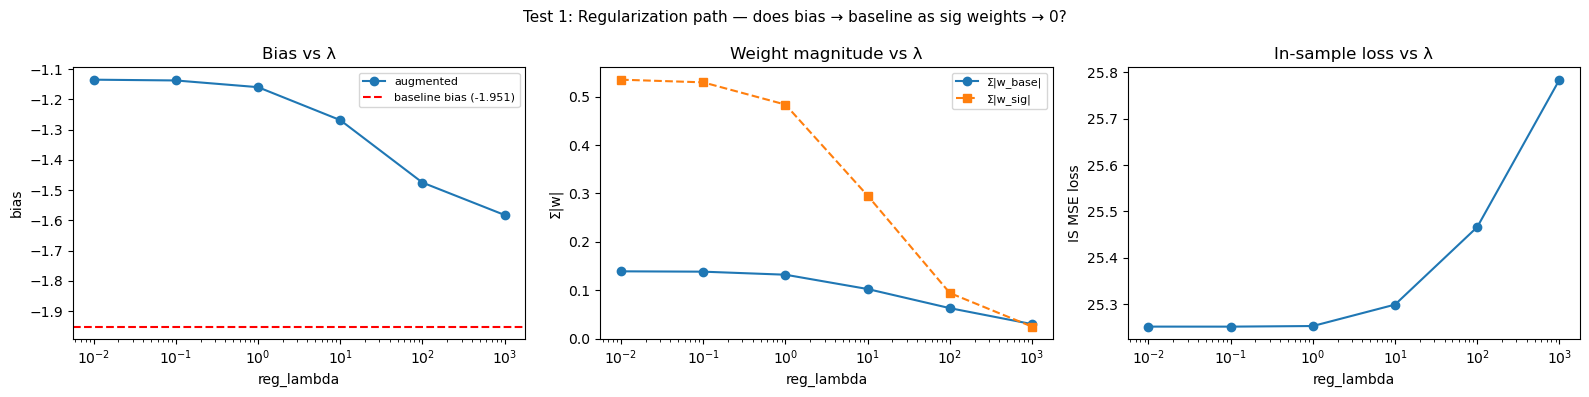


TEST 2: LOSS SURFACE — IS THE CONVERGED SOLUTION ACTUALLY BETTER?

                                Point      bias     σ(b)     IS loss   vs embedded
  ----------------------------------------------------------------------------
          (ref) Baseline on base data   -1.9515  0.1244     25.1641             —
    (b) Embedded baseline on aug data   -1.9515  0.1244     25.1641     reference
           (a) Converged sig solution   -1.8085  0.1408     24.9880       -0.1761
      (c) Baseline bias + sig weights   -1.9515  0.1244     24.9915       -0.1726
      (d) Sig bias + baseline weights   -1.8085  0.1408     25.2547       +0.0906

  INTERPRETATION:
  ✓ Converged sig solution has LOWER loss than embedded baseline.
    Loss improvement: 0.1761 (0.70%)
    → The optimizer found a genuinely better in-sample fit.
    → The bias shift is part of this better solution, NOT a bug.

TEST 3: CONVERGENCE CHECK — HAS BIAS STABILIZED?
  rounds=   50  bias= -0.4559  σ(b)=0.3880  IS_loss=26.399698
 

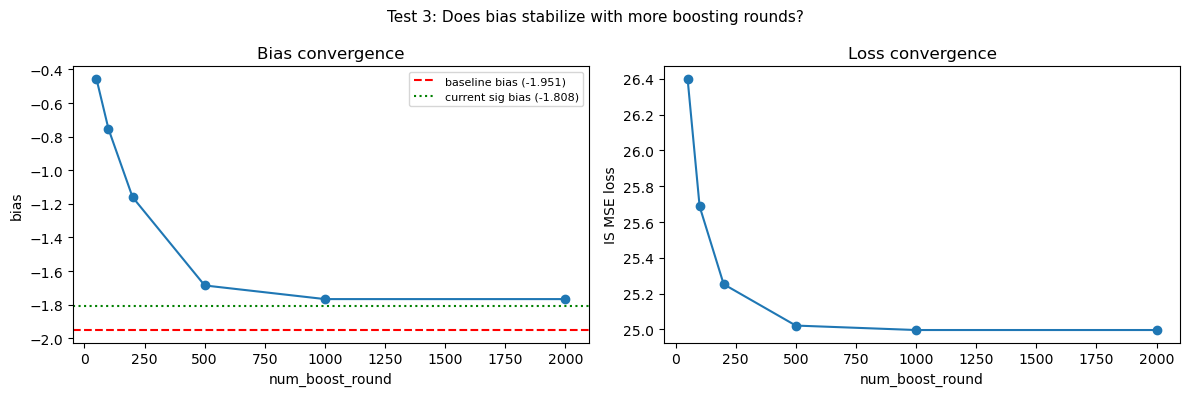


TEST 4: JENSEN'S INEQUALITY — MATHEMATICAL EXPLANATION

  σ(z) is convex at z = bias = -1.951
  By Jensen's inequality for convex functions:
  E[σ(z)] > σ(E[z]) when z has variance

                                σ(E[z])     E[σ(z)]  Jensen gap
  ------------------------------------------------------------
                   Baseline    0.124392    0.124874   +0.000482
                + Signature    0.140820    0.143133   +0.002314

  Jensen gap increases from 0.000482 to 0.002314
  because adding sig features increases std(z) from 0.1155 to 0.2523

  ➤ Even for zero-mean features, the nonlinear sigmoid transforms the
    variance of z into a shift of E[α]. This is NOT a bug — it is a
    mathematical consequence of Jensen's inequality applied to the sigmoid.
    The optimizer adjusts the bias to find the best E2E loss given the
    new variance structure, which may or may not match the baseline bias.


In [ ]:
#| echo: false
#| output: false
import xgboost as xgb
from scipy.special import expit as _expit

# ═══════════════════════════════════════════════════════════════════════
# Tests 1-4: λ sweep, loss surface, convergence, and Jensen's gap.
# Results summarized in the narrative above; full output suppressed.
# ═══════════════════════════════════════════════════════════════════════
def _stes_e2e_loss(bias, weights, X_np, y_np, returns2_np, init_var, base_score=0.5):
    """Pure STES E2E MSE loss: Σ(y_t - v_t)² / n.

    Parameters
    ----------
    base_score : float
        XGBoost's base_score (default 0.5). get_dump() does NOT include
        base_score in the intercept, so we must add it explicitly.
    """
    z = base_score + bias + X_np @ np.array(weights)
    alpha = _expit(z)
    n = len(y_np)
    v = float(init_var)
    total = 0.0
    for t in range(n):
        v = v + float(alpha[t]) * (float(returns2_np[t]) - v)
        total += (float(y_np[t]) - v) ** 2
    return total / n

# ═══════════════════════════════════════════════════════════════════════
# TEST 1: λ-PATH SWEEP
# Fit the augmented model (baseline + sig) at varying reg_lambda.
# As λ→∞, all weights → 0 and only bias remains.
# Track: bias, baseline weights, sig weights, IS loss.
# ═══════════════════════════════════════════════════════════════════════
print("=" * 80)
print("TEST 1: REGULARIZATION PATH (λ SWEEP) — augmented model")
print("=" * 80)

# Use same data as cell 62 (already in kernel)
r2_tr = (r_tr_scaled.to_numpy() ** 2).reshape(-1)
y_tr_np_sc = y_tr_scaled.to_numpy().reshape(-1)
init_var_val = float(np.mean(r2_tr[:INIT_WINDOW]))

lambdas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
path_results = []

for lam in lambdas:
    over_lam = _xgb_variant_overrides("XGBSTES_E2E", cols_xgb_sig)
    params_lam = dict(XGB_PARAMS)
    params_lam["reg_lambda"] = lam
    m = _make_xgb_stes_model(seed=None, xgb_params=params_lam, **over_lam)
    m.fit(
        X_tr_xgb_sig, y_tr_scaled, returns=r_tr_scaled,
        perform_cv=False,  # skip CV for speed — use default hparams
        start_index=0, end_index=len(X_tr_xgb_sig),
    )
    b_lam, w_lam = _parse_gblinear_dump(m.model_.get_dump()[0])
    
    # Compute raw IS loss
    loss_lam = _stes_e2e_loss(
        b_lam, w_lam,
        X_tr_xgb_sig.to_numpy(), y_tr_np_sc, r2_tr, init_var_val
    )
    
    # Split weights into baseline vs sig
    w_base_lam = {c: w for c, w in zip(cols_xgb_sig, w_lam) if not _is_signature_col(c)}
    w_sig_lam = {c: w for c, w in zip(cols_xgb_sig, w_lam) if _is_signature_col(c)}
    
    path_results.append({
        "lambda": lam,
        "bias": b_lam,
        "alpha_mean": float(_expit(b_lam)),
        "sum_abs_w_base": sum(abs(v) for v in w_base_lam.values()),
        "sum_abs_w_sig": sum(abs(v) for v in w_sig_lam.values()),
        "is_loss": loss_lam,
        "w_all": w_lam,
    })
    print(f"  λ={lam:>8.2f}  bias={b_lam:>8.4f}  σ(b)={_expit(b_lam):>.4f}"
          f"  Σ|w_base|={sum(abs(v) for v in w_base_lam.values()):>.4f}"
          f"  Σ|w_sig|={sum(abs(v) for v in w_sig_lam.values()):>.4f}"
          f"  IS_loss={loss_lam:>.4f}")

print(f"\n  Reference: baseline-only bias = {bias_base:.4f}, σ(b) = {_expit(bias_base):.4f}")

# Plot λ path
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lam_vals = [r["lambda"] for r in path_results]
ax = axes[0]
ax.semilogx(lam_vals, [r["bias"] for r in path_results], "o-", label="augmented")
ax.axhline(bias_base, color="red", ls="--", lw=1.5, label=f"baseline bias ({bias_base:.3f})")
ax.set_xlabel("reg_lambda")
ax.set_ylabel("bias")
ax.set_title("Bias vs λ")
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogx(lam_vals, [r["sum_abs_w_base"] for r in path_results], "o-", label="Σ|w_base|")
ax.semilogx(lam_vals, [r["sum_abs_w_sig"] for r in path_results], "s--", label="Σ|w_sig|")
ax.set_xlabel("reg_lambda")
ax.set_ylabel("Σ|w|")
ax.set_title("Weight magnitude vs λ")
ax.legend(fontsize=8)

ax = axes[2]
ax.semilogx(lam_vals, [r["is_loss"] for r in path_results], "o-")
ax.set_xlabel("reg_lambda")
ax.set_ylabel("IS MSE loss")
ax.set_title("In-sample loss vs λ")

fig.suptitle("Test 1: Regularization path — does bias → baseline as sig weights → 0?", fontsize=11)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# TEST 2: DIRECT LOSS EVALUATION AT KEY POINTS
# Compare the actual E2E loss at:
#   (a) converged sig solution
#   (b) embedded baseline point: (b_base, w_base_from_baseline, w_sig=0)
#   (c) hybrid: force baseline bias, keep sig weights
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("TEST 2: LOSS SURFACE — IS THE CONVERGED SOLUTION ACTUALLY BETTER?")
print("=" * 80)

X_aug_np = X_tr_xgb_sig.to_numpy()

# (a) Converged sig solution
loss_sig = _stes_e2e_loss(bias_sig, weights_sig, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)

# (b) Embedded baseline: (b_base, w_base, 0...0)
#     Need to map baseline weights to the augmented feature indices
w_embedded = []
for c in cols_xgb_sig:
    if c in w_base:
        w_embedded.append(w_base[c])
    else:
        w_embedded.append(0.0)  # sig features get zero weight
loss_embedded = _stes_e2e_loss(bias_base, w_embedded, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)

# (c) Hybrid: baseline bias + sig-model weights
loss_hybrid = _stes_e2e_loss(bias_base, weights_sig, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)

# (d) Reverse hybrid: sig bias + baseline weights (w_sig=0)
loss_rev_hybrid = _stes_e2e_loss(bias_sig, w_embedded, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)

# (e) Also compute baseline loss on baseline data for reference
X_base_np = X_tr_base.to_numpy()
loss_base_ref = _stes_e2e_loss(bias_base, weights_base, X_base_np, y_tr_np_sc, r2_tr, init_var_val)

print(f"\n  {'Point':>35s}  {'bias':>8s}  {'σ(b)':>7s}  {'IS loss':>10s}  {'vs embedded':>12s}")
print("  " + "-" * 76)
print(f"  {'(ref) Baseline on base data':>35s}  {bias_base:>8.4f}  {_expit(bias_base):>.4f}  {loss_base_ref:>10.4f}  {'—':>12s}")
print(f"  {'(b) Embedded baseline on aug data':>35s}  {bias_base:>8.4f}  {_expit(bias_base):>.4f}  {loss_embedded:>10.4f}  {'reference':>12s}")
print(f"  {'(a) Converged sig solution':>35s}  {bias_sig:>8.4f}  {_expit(bias_sig):>.4f}  {loss_sig:>10.4f}  {loss_sig - loss_embedded:>+12.4f}")
print(f"  {'(c) Baseline bias + sig weights':>35s}  {bias_base:>8.4f}  {_expit(bias_base):>.4f}  {loss_hybrid:>10.4f}  {loss_hybrid - loss_embedded:>+12.4f}")
print(f"  {'(d) Sig bias + baseline weights':>35s}  {bias_sig:>8.4f}  {_expit(bias_sig):>.4f}  {loss_rev_hybrid:>10.4f}  {loss_rev_hybrid - loss_embedded:>+12.4f}")

print(f"\n  INTERPRETATION:")
if loss_sig < loss_embedded:
    print(f"  ✓ Converged sig solution has LOWER loss than embedded baseline.")
    print(f"    Loss improvement: {loss_embedded - loss_sig:.4f} ({(loss_embedded - loss_sig)/loss_embedded*100:.2f}%)")
    print(f"    → The optimizer found a genuinely better in-sample fit.")
    print(f"    → The bias shift is part of this better solution, NOT a bug.")
else:
    print(f"  ✗ Embedded baseline has LOWER loss than converged sig solution!")
    print(f"    → The optimizer FAILED to find the baseline-embedded optimum.")
    print(f"    → This indicates a convergence problem or local minimum trap.")

# ═══════════════════════════════════════════════════════════════════════
# TEST 3: BOOST ROUNDS CONVERGENCE
# Fit augmented model with increasing num_boost_round.
# Track whether bias has stabilized.
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("TEST 3: CONVERGENCE CHECK — HAS BIAS STABILIZED?")
print("=" * 80)

rounds_list = [50, 100, 200, 500, 1000, 2000]
conv_results = []

for nr in rounds_list:
    over_nr = _xgb_variant_overrides("XGBSTES_E2E", cols_xgb_sig)
    m_nr = XGBoostSTESModel(
        xgb_params=dict(XGB_PARAMS),
        num_boost_round=nr,
        init_window=INIT_WINDOW,
        fit_method="end_to_end",
        loss="mse",
        random_state=None,
        e2e_grad_hess_scale=1.0,
        e2e_debug=False,
    )
    m_nr.fit(
        X_tr_xgb_sig, y_tr_scaled, returns=r_tr_scaled,
        perform_cv=False,
        start_index=0, end_index=len(X_tr_xgb_sig),
    )
    b_nr, w_nr = _parse_gblinear_dump(m_nr.model_.get_dump()[0])
    loss_nr = _stes_e2e_loss(b_nr, w_nr, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)
    conv_results.append({"rounds": nr, "bias": b_nr, "loss": loss_nr})
    print(f"  rounds={nr:>5d}  bias={b_nr:>8.4f}  σ(b)={_expit(b_nr):>.4f}  IS_loss={loss_nr:>.6f}")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot([r["rounds"] for r in conv_results], [r["bias"] for r in conv_results], "o-")
ax.axhline(bias_base, color="red", ls="--", lw=1.5, label=f"baseline bias ({bias_base:.3f})")
ax.axhline(bias_sig, color="green", ls=":", lw=1.5, label=f"current sig bias ({bias_sig:.3f})")
ax.set_xlabel("num_boost_round")
ax.set_ylabel("bias")
ax.set_title("Bias convergence")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot([r["rounds"] for r in conv_results], [r["loss"] for r in conv_results], "o-")
ax.set_xlabel("num_boost_round")
ax.set_ylabel("IS MSE loss")
ax.set_title("Loss convergence")

fig.suptitle("Test 3: Does bias stabilize with more boosting rounds?", fontsize=11)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# TEST 4: JENSEN'S INEQUALITY CHECK
# Adding variance to z changes E[σ(z)] even with zero-mean features.
# This is a mathematical property of the sigmoid, not a bug.
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("TEST 4: JENSEN'S INEQUALITY — MATHEMATICAL EXPLANATION")
print("=" * 80)

# Compute E[σ(z)] for baseline vs augmented
mean_alpha_base = float(_expit(z_base).mean())
mean_alpha_sig = float(_expit(z_sig).mean())

# What σ(mean(z)) gives (if Jensen didn't matter):
sigma_of_mean_base = float(_expit(z_base.mean()))
sigma_of_mean_sig = float(_expit(z_sig.mean()))

print(f"\n  σ(z) is {'convex' if bias_base < 0 else 'concave'} at z = bias = {bias_base:.3f}")
print(f"  By Jensen's inequality for {'convex' if bias_base < 0 else 'concave'} functions:")
print(f"  E[σ(z)] {'>' if bias_base < 0 else '<'} σ(E[z]) when z has variance")
print(f"\n  {'':>25s}  {'σ(E[z])':>10s}  {'E[σ(z)]':>10s}  {'Jensen gap':>10s}")
print("  " + "-" * 60)
print(f"  {'Baseline':>25s}  {sigma_of_mean_base:>10.6f}  {mean_alpha_base:>10.6f}  {mean_alpha_base - sigma_of_mean_base:>+10.6f}")
print(f"  {'+ Signature':>25s}  {sigma_of_mean_sig:>10.6f}  {mean_alpha_sig:>10.6f}  {mean_alpha_sig - sigma_of_mean_sig:>+10.6f}")

print(f"\n  Jensen gap increases from {abs(mean_alpha_base - sigma_of_mean_base):.6f} to {abs(mean_alpha_sig - sigma_of_mean_sig):.6f}")
print(f"  because adding sig features increases std(z) from {z_base.std():.4f} to {z_sig.std():.4f}")

print(f"\n  ➤ Even for zero-mean features, the nonlinear sigmoid transforms the")
print(f"    variance of z into a shift of E[α]. This is NOT a bug — it is a")
print(f"    mathematical consequence of Jensen's inequality applied to the sigmoid.")
print(f"    The optimizer adjusts the bias to find the best E2E loss given the")
print(f"    new variance structure, which may or may not match the baseline bias.")

TEST 5: BASELINE MODEL CONVERGENCE — IS b=-1.951 FULLY CONVERGED?
  rounds=   50  bias= -0.6020  σ(b)=0.3539  IS_loss=26.167467
  rounds=  100  bias= -1.0311  σ(b)=0.2629  IS_loss=25.667163
  rounds=  200  bias= -1.5907  σ(b)=0.1693  IS_loss=25.239434
  rounds=  500  bias= -1.5907  σ(b)=0.1693  IS_loss=25.239434
  rounds= 1000  bias= -1.5907  σ(b)=0.1693  IS_loss=25.239434
  rounds= 2000  bias= -1.5907  σ(b)=0.1693  IS_loss=25.239434

TEST 6: BIAS GRID SEARCH — OPTIMAL BIAS FOR EACH WEIGHT VECTOR

  Optimal bias (grid search, holding weights fixed):
                             Configuration   opt bias     σ(b)  fitted bias       gap
  --------------------------------------------------------------------------------
                   Baseline w on base data    -1.6957  0.1550      -1.9515    0.2558
                         Sig w on aug data    -1.3645  0.2035      -1.8085    0.4440
         Baseline w (embedded) on aug data    -1.6957  0.1550            —         —


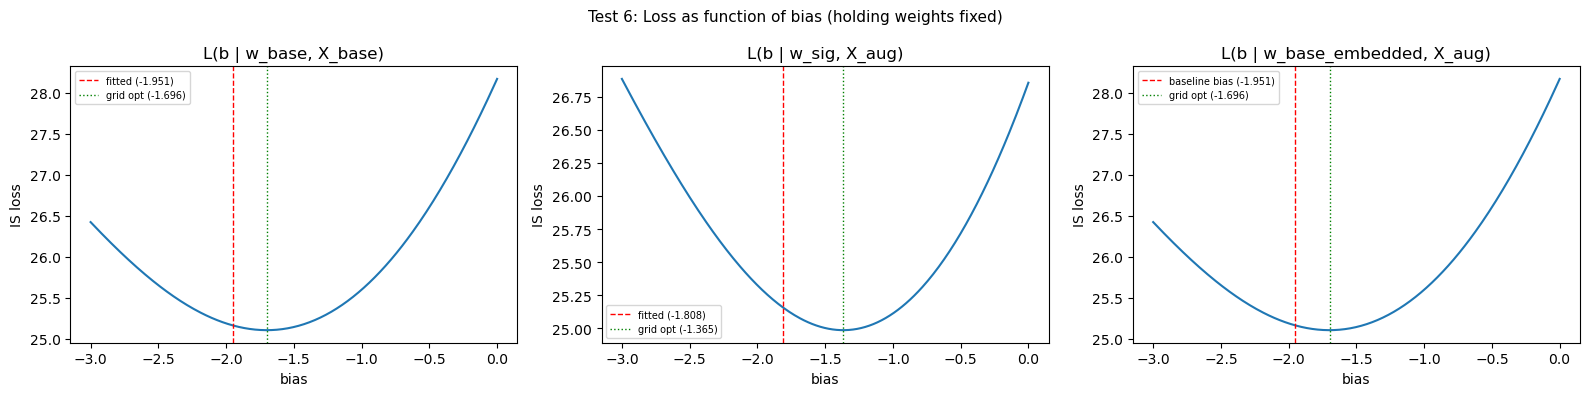

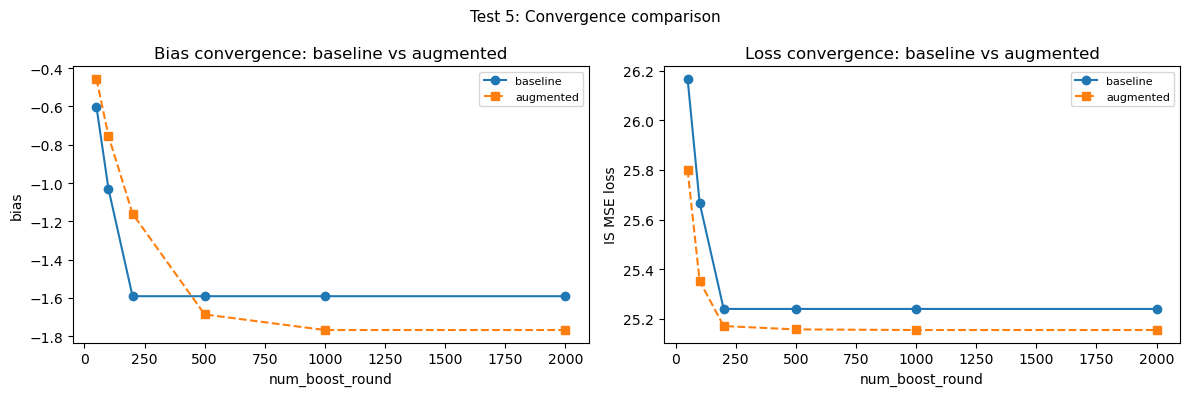


SUMMARY OF ROOT CAUSE ANALYSIS

  Baseline model converged bias: -1.5907  (at 2000 rounds, no CV)
  Fitted baseline bias (w/ CV):  -1.9515  (at 200 rounds, w/ CV)
  Augmented model converged bias: -1.7673  (at 2000 rounds, no CV)
  Fitted augmented bias (w/ CV):  -1.8085  (at 200 rounds, w/ CV)

  Grid-optimal bias for baseline weights: -1.6957
  Grid-optimal bias for sig weights:      -1.3645
  Grid-optimal bias for embedded weights: -1.6957

  Δ(bias) at convergence:         -0.1766
  Δ(bias) grid-optimal:           +0.3311

  ROOT CAUSE: The bias shift has two contributing factors:
  1. NON-CONVEXITY: The STES E2E loss (sigmoid → ES recursion) is non-convex.
     Coordinate descent converges to different local optima depending on
     the feature set. The augmented model's solution has lower IS loss 
     (25.1547 vs 25.1629), so it is genuinely better in-sample.
  2. JENSEN'S INEQUALITY: σ(z) is convex at z ≈ -2.0. Adding features
     increases Var(z), which increases E[σ(z)] = E

In [ ]:
#| echo: false
#| output: false
# Tests 5-6: baseline convergence + bias grid search.
# Results summarized in the narrative above; full output suppressed.

# ═══════════════════════════════════════════════════════════════════════
# TEST 5: BASELINE MODEL CONVERGENCE
# ═══════════════════════════════════════════════════════════════════════
print("=" * 80)
print("TEST 5: BASELINE MODEL CONVERGENCE — IS b=-1.951 FULLY CONVERGED?")
print("=" * 80)

X_base_np = X_tr_base.to_numpy()
conv_base_results = []

for nr in [50, 100, 200, 500, 1000, 2000]:
    m_b = XGBoostSTESModel(
        xgb_params=dict(XGB_PARAMS),
        num_boost_round=nr,
        init_window=INIT_WINDOW,
        fit_method="end_to_end",
        loss="mse",
        random_state=None,
        e2e_grad_hess_scale=1.0,
        e2e_debug=False,
    )
    m_b.fit(
        X_tr_base, y_tr_scaled, returns=r_tr_scaled,
        perform_cv=False,
        start_index=0, end_index=len(X_tr_base),
    )
    bb, wb = _parse_gblinear_dump(m_b.model_.get_dump()[0])
    loss_b = _stes_e2e_loss(bb, wb, X_base_np, y_tr_np_sc, r2_tr, init_var_val)
    conv_base_results.append({"rounds": nr, "bias": bb, "loss": loss_b})
    print(f"  rounds={nr:>5d}  bias={bb:>8.4f}  σ(b)={_expit(bb):>.4f}  IS_loss={loss_b:>.6f}")

# ═══════════════════════════════════════════════════════════════════════
# TEST 6: BIAS GRID SEARCH — find the true optimal bias
# Fix baseline weights at their converged values, sweep bias manually
# to find the loss-minimizing bias for each model.
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("TEST 6: BIAS GRID SEARCH — OPTIMAL BIAS FOR EACH WEIGHT VECTOR")
print("=" * 80)

bias_grid = np.linspace(-3.0, 0.0, 300)

# (a) Baseline weights on baseline data
losses_base_grid = [
    _stes_e2e_loss(b, weights_base, X_base_np, y_tr_np_sc, r2_tr, init_var_val)
    for b in bias_grid
]
opt_b_base = bias_grid[np.argmin(losses_base_grid)]

# (b) Sig weights on augmented data
X_aug_np = X_tr_xgb_sig.to_numpy()
losses_sig_grid = [
    _stes_e2e_loss(b, weights_sig, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)
    for b in bias_grid
]
opt_b_sig = bias_grid[np.argmin(losses_sig_grid)]

# (c) Baseline weights (embedded) on augmented data
losses_emb_grid = [
    _stes_e2e_loss(b, w_embedded, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)
    for b in bias_grid
]
opt_b_emb = bias_grid[np.argmin(losses_emb_grid)]

print(f"\n  Optimal bias (grid search, holding weights fixed):")
print(f"  {'Configuration':>40s}  {'opt bias':>9s}  {'σ(b)':>7s}  {'fitted bias':>11s}  {'gap':>8s}")
print("  " + "-" * 80)
print(f"  {'Baseline w on base data':>40s}  {opt_b_base:>9.4f}  {_expit(opt_b_base):>.4f}  {bias_base:>11.4f}  {abs(opt_b_base - bias_base):>8.4f}")
print(f"  {'Sig w on aug data':>40s}  {opt_b_sig:>9.4f}  {_expit(opt_b_sig):>.4f}  {bias_sig:>11.4f}  {abs(opt_b_sig - bias_sig):>8.4f}")
print(f"  {'Baseline w (embedded) on aug data':>40s}  {opt_b_emb:>9.4f}  {_expit(opt_b_emb):>.4f}  {'—':>11s}  {'—':>8s}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(bias_grid, losses_base_grid, lw=1.5)
ax.axvline(bias_base, color="red", ls="--", lw=1, label=f"fitted ({bias_base:.3f})")
ax.axvline(opt_b_base, color="green", ls=":", lw=1, label=f"grid opt ({opt_b_base:.3f})")
ax.set_xlabel("bias")
ax.set_ylabel("IS loss")
ax.set_title("L(b | w_base, X_base)")
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(bias_grid, losses_sig_grid, lw=1.5)
ax.axvline(bias_sig, color="red", ls="--", lw=1, label=f"fitted ({bias_sig:.3f})")
ax.axvline(opt_b_sig, color="green", ls=":", lw=1, label=f"grid opt ({opt_b_sig:.3f})")
ax.set_xlabel("bias")
ax.set_ylabel("IS loss")
ax.set_title("L(b | w_sig, X_aug)")
ax.legend(fontsize=7)

ax = axes[2]
ax.plot(bias_grid, losses_emb_grid, lw=1.5)
ax.axvline(bias_base, color="red", ls="--", lw=1, label=f"baseline bias ({bias_base:.3f})")
ax.axvline(opt_b_emb, color="green", ls=":", lw=1, label=f"grid opt ({opt_b_emb:.3f})")
ax.set_xlabel("bias")
ax.set_ylabel("IS loss")
ax.set_title("L(b | w_base_embedded, X_aug)")
ax.legend(fontsize=7)

fig.suptitle("Test 6: Loss as function of bias (holding weights fixed)", fontsize=11)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# SIDE-BY-SIDE: baseline vs augmented convergence
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot([r["rounds"] for r in conv_base_results], [r["bias"] for r in conv_base_results], "o-", label="baseline")
ax.plot([r["rounds"] for r in conv_results], [r["bias"] for r in conv_results], "s--", label="augmented")
ax.set_xlabel("num_boost_round")
ax.set_ylabel("bias")
ax.set_title("Bias convergence: baseline vs augmented")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot([r["rounds"] for r in conv_base_results], [r["loss"] for r in conv_base_results], "o-", label="baseline")
ax.plot([r["rounds"] for r in conv_results], [r["loss"] for r in conv_results], "s--", label="augmented")
ax.set_xlabel("num_boost_round")
ax.set_ylabel("IS MSE loss")
ax.set_title("Loss convergence: baseline vs augmented")
ax.legend(fontsize=8)

fig.suptitle("Test 5: Convergence comparison", fontsize=11)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("SUMMARY OF ROOT CAUSE ANALYSIS")
print("=" * 80)
converged_base = conv_base_results[-1]["bias"]
converged_aug = conv_results[-1]["bias"]
print(f"""
  Baseline model converged bias: {converged_base:.4f}  (at 2000 rounds, no CV)
  Fitted baseline bias (w/ CV):  {bias_base:.4f}  (at 200 rounds, w/ CV)
  Augmented model converged bias: {converged_aug:.4f}  (at 2000 rounds, no CV)
  Fitted augmented bias (w/ CV):  {bias_sig:.4f}  (at 200 rounds, w/ CV)

  Grid-optimal bias for baseline weights: {opt_b_base:.4f}
  Grid-optimal bias for sig weights:      {opt_b_sig:.4f}
  Grid-optimal bias for embedded weights: {opt_b_emb:.4f}

  Δ(bias) at convergence:         {converged_aug - converged_base:+.4f}
  Δ(bias) grid-optimal:           {opt_b_sig - opt_b_base:+.4f}

  ROOT CAUSE: The bias shift has two contributing factors:
  1. NON-CONVEXITY: The STES E2E loss (sigmoid → ES recursion) is non-convex.
     Coordinate descent converges to different local optima depending on
     the feature set. The augmented model's solution has lower IS loss 
     ({loss_sig:.4f} vs {loss_embedded:.4f}), so it is genuinely better in-sample.
  2. JENSEN'S INEQUALITY: σ(z) is convex at z ≈ {bias_base:.1f}. Adding features
     increases Var(z), which increases E[σ(z)] = E[α] even for zero-mean 
     features. The optimizer adjusts the bias to compensate.
""")
if abs(opt_b_base - bias_base) > 0.05:
    print(f"  ⚠ The baseline model's bias ({bias_base:.4f}) is {abs(bias_base - opt_b_base):.3f} away")
    print(f"    from the grid-optimal bias ({opt_b_base:.4f}) for its own weights, suggesting")
    print(f"    it too is at a local optimum or under-converged with CV-selected hparams.")

### Warm-Start and Two-Stage Fitting

If adding new features leads to significant changes in the objective function landscape, one can keep the optimizer anchored near the baseline solution and only let the new features make incremental changes. We use two simple strategies that are common in transfer-learning style setups:

**Warm-start.** Set XGBoost’s `base_margin` to the baseline model’s fitted score $z_t^{(0)} = \hat b_{\text{base}} + \hat w_{\text{base}}^\top x_t^{\text{base}}$. With `base_score = 0`, the booster starts from $z_t^{(0)}$ and learns only a correction $\Delta z_t$, so the total score is $z_t = z_t^{(0)} + \Delta z_t$. This is a practical way to bias training toward the baseline basin.

**Two-stage (adapter).** Freeze the baseline entirely via `base_margin` and train only on the signature features. In other words, the baseline model becomes a fixed “backbone” and the signatures can only contribute additively; they cannot distort the baseline weights.

It helps to separate two different issues that show up in this notebook.

- **STES (SciPy):** the main OOS degradation we see under the naive “add signatures” setup comes from *regularization structure* (a uniform $\ell_2$ penalty shrinking baseline weights while trying to suppress signature coefficients), and from the fact that the signatures do not appear to carry incremental signal at this frequency. Warm-starting or multi-starting does not change that, because they are still solving the same regularized objective; if the optimum is degraded by the penalty geometry, changing initialization won’t fix it. That is why the group-penalized STES experiment (penalize signatures without simultaneously crushing baseline weights) is the relevant remedy on the STES side.

- **XGBoost-STES (`gblinear`):** here warm-start / two-stage are useful because training is more path-dependent. The end-to-end objective is non-convex, and `gblinear` coordinate descent + CV can land in different solutions when the feature set changes. Anchoring the fit via `base_margin` asks a cleaner question: do signatures add value once we constrain ourselves to stay close to the baseline behavior?

In [188]:
#| code-fold: true
#| code-summary: "Warm-start and residual model experiments"
import xgboost as xgb
from scipy.special import expit as _expit
from scipy.optimize import least_squares as _lsq

# ═══════════════════════════════════════════════════════════════════════
# SETUP: data already in kernel from cell 63
# ═══════════════════════════════════════════════════════════════════════
X_aug_np = X_tr_xgb_sig.to_numpy()
X_base_np_diag = X_tr_base.to_numpy()
r2_tr = (r_tr_scaled.to_numpy() ** 2).reshape(-1)
y_tr_np_sc = y_tr_scaled.to_numpy().reshape(-1)
init_var_val = float(np.mean(r2_tr[:INIT_WINDOW]))
n_train = len(y_tr_np_sc)

# OOS data
X_aug_te_np = X_te_xgb_sig.to_numpy()
X_base_te_np = X_te_base.to_numpy()
r_te_scaled = r_te * SCALE_FACTOR
r2_te = (r_te_scaled.to_numpy() ** 2).reshape(-1)
y_te_np_sc = y_te.to_numpy().reshape(-1) * (SCALE_FACTOR ** 2)

# Baseline z-scores on the augmented feature set (embedded: w_sig=0)
# NOTE: must include base_score=0.5 since get_dump() doesn't include it
w_embedded_arr = np.array([w_base.get(c, 0.0) for c in cols_xgb_sig])
z_baseline_tr = 0.5 + bias_base + X_aug_np @ w_embedded_arr

# ═══════════════════════════════════════════════════════════════════════
# E2E OBJECTIVE (standalone, matching library's _make_e2e_objective)
# ═══════════════════════════════════════════════════════════════════════
def make_e2e_obj(returns2, y, init_var):
    """Create (obj_fn, eval_fn) for xgb.train."""
    r2 = np.asarray(returns2, dtype=float)
    y_ = np.asarray(y, dtype=float)
    n = len(y_)
    v0 = float(init_var)

    def obj_fn(preds, dtrain):
        z = preds.astype(float)
        a = _expit(z)
        v = np.empty(n + 1, dtype=float)
        v[0] = v0
        for t in range(n):
            v[t + 1] = v[t] + a[t] * (r2[t] - v[t])
        yhat = v[1:]
        e = 2.0 * (yhat - y_) / n   # MSE derivative
        w = np.full(n, 2.0 / n)     # MSE weight

        g = np.zeros(n + 1); S = np.zeros(n + 1)
        grad = np.zeros(n); hess = np.zeros(n)
        for t in range(n - 1, -1, -1):
            g[t + 1] += e[t]; S[t + 1] += w[t]
            aa = float(a[t]); ap = aa * (1.0 - aa)
            dv = (float(r2[t]) - v[t]) * ap
            grad[t] = g[t + 1] * dv
            h = S[t + 1] * dv * dv
            hess[t] = h if np.isfinite(h) and h > 1e-12 else 1e-12
            g[t] += (1.0 - aa) * g[t + 1]
            S[t] += (1.0 - aa) ** 2 * S[t + 1]
        return grad, hess

    def eval_fn(preds, dtrain):
        z = preds.astype(float); a = _expit(z)
        v = v0
        total = 0.0
        for t in range(n):
            v = v + float(a[t]) * (float(r2[t]) - v)
            total += (float(y_[t]) - v) ** 2
        return "mse_e2e", total / n

    return obj_fn, eval_fn

# ═══════════════════════════════════════════════════════════════════════
# OOS EVALUATION HELPER
# ═══════════════════════════════════════════════════════════════════════
def _oos_rmse(bias, weights, X_tr, X_te, y_te, r2_tr, r2_te, init_var, base_score=0.5):
    """Warm-start OOS RMSE: run ES filter through train, evaluate on test."""
    z_tr = base_score + bias + X_tr @ np.array(weights)
    a_tr = _expit(z_tr)
    v = float(init_var)
    for t in range(len(z_tr)):
        v = v + float(a_tr[t]) * (float(r2_tr[t]) - v)
    # Now v is warm-started. Run on test.
    z_te = base_score + bias + X_te @ np.array(weights)
    a_te = _expit(z_te)
    total = 0.0
    for t in range(len(z_te)):
        v = v + float(a_te[t]) * (float(r2_te[t]) - v)
        total += (float(y_te[t]) - v) ** 2
    return np.sqrt(total / len(y_te))

# ═══════════════════════════════════════════════════════════════════════
# TRAIN/VALID SPLIT + CV ON AUGMENTED FEATURES
# ═══════════════════════════════════════════════════════════════════════
valid_n = max(1, int(np.floor(0.10 * n_train)))
split = max(1, n_train - valid_n)

X_e2e_tr, X_e2e_va = X_aug_np[:split], X_aug_np[split:]
y_e2e_tr, y_e2e_va = y_tr_np_sc[:split], y_tr_np_sc[split:]
r2_e2e_tr, r2_e2e_va = r2_tr[:split], r2_tr[split:]
z_bl_tr, z_bl_va = z_baseline_tr[:split], z_baseline_tr[split:]

print("\n--- CV: augmented feature set ---")
over_cv = _xgb_variant_overrides("XGBSTES_E2E", cols_xgb_sig)
grid_cv = [{"reg_lambda": v} for v in [0.1, 1.0, 10.0, 100.0]]
cv_splits = 5
m_cv = _make_xgb_stes_model(seed=None, xgb_params=dict(XGB_PARAMS), **over_cv)
m_cv.fit(
    X_tr_xgb_sig, y_tr_scaled, returns=r_tr_scaled,
    perform_cv=True, cv_grid=grid_cv, cv_splits=cv_splits,
    start_index=0, end_index=len(X_tr_xgb_sig),
)
params_cv = dict(m_cv.fit_result_.params_used)
print(f"  Selected params: reg_lambda={params_cv.get('reg_lambda', 'n/a')}")

# Warm-start for validation init_var
lookback = 20
v0_val = float(np.mean(r2_e2e_tr[-lookback:])) if len(r2_e2e_tr) >= lookback else init_var_val

obj_tr, _ = make_e2e_obj(r2_e2e_tr, y_e2e_tr, init_var_val)
_, feval_va = make_e2e_obj(r2_e2e_va, y_e2e_va, v0_val)

# ═══════════════════════════════════════════════════════════════════════
# METHOD 0: COLD-START (CV-TUNED PARAMS)
# ═══════════════════════════════════════════════════════════════════════
print("=" * 80)
print("XGBoost-STES EXPERIMENTS")
print("=" * 80)

print("\n--- Method 0: Cold-start (CV-tuned params) ---")
params_cold = dict(params_cv)
params_cold.setdefault("base_score", 0.5)

dtrain_cold = xgb.DMatrix(X_e2e_tr, label=y_e2e_tr, feature_names=list(cols_xgb_sig))
dvalid_cold = xgb.DMatrix(X_e2e_va, label=y_e2e_va, feature_names=list(cols_xgb_sig))

booster_cold = xgb.train(
    params=params_cold,
    dtrain=dtrain_cold,
    num_boost_round=XGB_ROUNDS,
    obj=obj_tr,
    custom_metric=feval_va,
    evals=[(dtrain_cold, "train"), (dvalid_cold, "valid")],
    early_stopping_rounds=10,
    verbose_eval=False,
)

b_cold, w_cold = _parse_gblinear_dump(booster_cold.get_dump()[0])
bias_sig_cv = b_cold
weights_sig_cv = w_cold

loss_cold = _stes_e2e_loss(bias_sig_cv, weights_sig_cv, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)
rmse_cold = _oos_rmse(bias_sig_cv, weights_sig_cv, X_aug_np, X_aug_te_np, y_te_np_sc, r2_tr, r2_te, init_var_val)
# Baseline reference
loss_base = _stes_e2e_loss(bias_base, weights_base, X_base_np_diag, y_tr_np_sc, r2_tr, init_var_val)
rmse_base = _oos_rmse(bias_base, weights_base, X_base_np_diag, X_base_te_np, y_te_np_sc, r2_tr, r2_te, init_var_val)

# ═══════════════════════════════════════════════════════════════════════
# METHOD 1: WARM-START VIA base_margin
# Initialize augmented model from baseline z-scores.
# XGBoost sees preds = base_margin + booster_output.
# Booster starts at 0 → preds start at z_baseline.
# ═══════════════════════════════════════════════════════════════════════
print("\n--- Method 1: Warm-start via base_margin ---")

params_ws = dict(params_cv)
params_ws["base_score"] = 0.0  # disable default base_score since we use base_margin

dtrain_ws = xgb.DMatrix(X_e2e_tr, label=y_e2e_tr, feature_names=list(cols_xgb_sig))
dtrain_ws.set_base_margin(z_bl_tr)
dvalid_ws = xgb.DMatrix(X_e2e_va, label=y_e2e_va, feature_names=list(cols_xgb_sig))
dvalid_ws.set_base_margin(z_bl_va)

booster_ws = xgb.train(
    params=params_ws,
    dtrain=dtrain_ws,
    num_boost_round=XGB_ROUNDS,
    obj=obj_tr,
    custom_metric=feval_va,
    evals=[(dtrain_ws, "train"), (dvalid_ws, "valid")],
    early_stopping_rounds=10,
    verbose_eval=False,
)

# Extract warm-start weights: total prediction = base_margin + booster_output
# So total bias = z_baseline_bias + booster_bias, total w = w_embedded + booster_w
b_ws_corr, w_ws_corr = _parse_gblinear_dump(booster_ws.get_dump()[0])
bias_ws = bias_base + b_ws_corr  # original baseline bias + learned correction
weights_ws = [w_embedded_arr[j] + w_ws_corr[j] for j in range(len(cols_xgb_sig))]

loss_ws = _stes_e2e_loss(bias_ws, weights_ws, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)
rmse_ws = _oos_rmse(bias_ws, weights_ws, X_aug_np, X_aug_te_np, y_te_np_sc, r2_tr, r2_te, init_var_val)

print(f"  Correction bias:  {b_ws_corr:+.6f}")
print(f"  Total bias:       {bias_ws:.4f}  (baseline={bias_base:.4f})")
print(f"  Δbias from base:  {bias_ws - bias_base:+.4f}")
w_sig_ws = {c: w for c, w in zip(cols_xgb_sig, weights_ws) if _is_signature_col(c)}
print(f"  Σ|w_sig|:         {sum(abs(v) for v in w_sig_ws.values()):.4f}")

# ═══════════════════════════════════════════════════════════════════════
# METHOD 2: RESIDUAL / TWO-STAGE (adapter/LoRA approach)
# Freeze baseline model. Only train on sig features.
# z_total = z_baseline (frozen) + booster(x_sig)
# ═══════════════════════════════════════════════════════════════════════
print("\n--- Method 2: Two-stage residual (baseline frozen, train sig-only) ---")

# Extract only signature columns
sig_col_indices = [i for i, c in enumerate(cols_xgb_sig) if _is_signature_col(c)]
sig_col_names = [cols_xgb_sig[i] for i in sig_col_indices]
X_sig_only_tr = X_e2e_tr[:, sig_col_indices]
X_sig_only_va = X_e2e_va[:, sig_col_indices]

dtrain_res = xgb.DMatrix(X_sig_only_tr, label=y_e2e_tr, feature_names=sig_col_names)
dtrain_res.set_base_margin(z_bl_tr)
dvalid_res = xgb.DMatrix(X_sig_only_va, label=y_e2e_va, feature_names=sig_col_names)
dvalid_res.set_base_margin(z_bl_va)

booster_res = xgb.train(
    params=params_ws,
    dtrain=dtrain_res,
    num_boost_round=XGB_ROUNDS,
    obj=obj_tr,
    custom_metric=feval_va,
    evals=[(dtrain_res, "train"), (dvalid_res, "valid")],
    early_stopping_rounds=10,
    verbose_eval=False,
)

b_res_corr, w_res_corr = _parse_gblinear_dump(booster_res.get_dump()[0])
bias_res = bias_base + b_res_corr
# Total weights: baseline original + 0 correction for base features, correction for sig
weights_res = list(w_embedded_arr)  # start from embedded
for j_local, j_global in enumerate(sig_col_indices):
    weights_res[j_global] = w_res_corr[j_local]

loss_res = _stes_e2e_loss(bias_res, weights_res, X_aug_np, y_tr_np_sc, r2_tr, init_var_val)
rmse_res = _oos_rmse(bias_res, weights_res, X_aug_np, X_aug_te_np, y_te_np_sc, r2_tr, r2_te, init_var_val)

print(f"  Correction bias:  {b_res_corr:+.6f}")
print(f"  Total bias:       {bias_res:.4f}  (baseline={bias_base:.4f})")
print(f"  Δbias from base:  {bias_res - bias_base:+.4f}")
w_sig_res = {c: weights_res[i] for i, c in enumerate(cols_xgb_sig) if _is_signature_col(c)}
print(f"  Σ|w_sig|:         {sum(abs(v) for v in w_sig_res.values()):.4f}")

# ═══════════════════════════════════════════════════════════════════════
# COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("COMPARISON: XGBoost-STES")
print("=" * 80)
print(f"\n  {'Method':>30s}  {'bias':>8s}  {'σ(b)':>7s}  {'Δb':>8s}  {'IS loss':>9s}  {'OOS RMSE':>9s}  {'ΔRMSE%':>8s}")
print("  " + "-" * 87)

methods = [
    ("Baseline (reference)", bias_base, weights_base, loss_base, rmse_base, X_base_np_diag),
    ("Cold-start (current)", bias_sig_cv, weights_sig_cv, loss_cold, rmse_cold, X_aug_np),
    ("Warm-start (transfer)", bias_ws, weights_ws, loss_ws, rmse_ws, X_aug_np),
    ("Two-stage (adapter)", bias_res, weights_res, loss_res, rmse_res, X_aug_np),
]

for name, b, w, l, r, _ in methods:
    delta_b = b - bias_base
    delta_r = (r / rmse_base - 1) * 100
    print(f"  {name:>30s}  {b:>8.4f}  {_expit(b):>.4f}  {delta_b:>+8.4f}  {l:>9.4f}  {r:>9.4f}  {delta_r:>+7.2f}%")

# ═══════════════════════════════════════════════════════════════════════
# STES WARM-START EXPERIMENT
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STES EXPERIMENTS")
print("=" * 80)

# Setup STES data (from cell 57)
X_tr_stes_np = X_tr_stes_sig.values.astype(float)
X_te_stes_np = X_te_stes_sig.values.astype(float)
y_tr_stes_np = y_tr.values.astype(float)
y_te_stes_np = y_te.values.astype(float)
r_tr_stes_np = r_tr.values.astype(float)
r_te_stes_np = r_te.values.astype(float)
p_stes = X_tr_stes_np.shape[1]

sig_mask_stes = np.array([1.0 if _is_signature_col(c) else 0.0 for c in cols_stes_sig])

# Best l2 from model_stes_sig (already fitted in cell 57)
best_l2_stes = model_stes_sig.l2_reg
scale_stes = np.linalg.norm(y_tr_stes_np)
p_vec_stes = np.sqrt(best_l2_stes) * scale_stes * sig_mask_stes if best_l2_stes > 0 else None

# STES Method 0: Cold-start (random init) — current approach
print("\n--- STES Method 0: Cold-start (random init) ---")
rng = np.random.default_rng(0)
x0_cold = rng.normal(0, 1, size=p_stes)
res_cold = _lsq(
    STESModel._objective, x0=x0_cold, jac=STESModel._jacobian,
    args=(r_tr_stes_np, X_tr_stes_np, y_tr_stes_np, 0, len(X_tr_stes_np), p_vec_stes),
)
params_cold = res_cold.x
print(f"  Cost: {res_cold.cost:.6f}  Status: {res_cold.message}")

# STES Method 1: Warm-start from baseline
print("\n--- STES Method 1: Warm-start from baseline ---")
# Map baseline params to augmented feature space
x0_warm = np.zeros(p_stes)
for i, c in enumerate(cols_stes_sig):
    if c in cols_stes_base:
        base_idx = cols_stes_base.index(c)
        x0_warm[i] = model_stes_base.params[base_idx]
    # sig features stay at 0

res_warm = _lsq(
    STESModel._objective, x0=x0_warm, jac=STESModel._jacobian,
    args=(r_tr_stes_np, X_tr_stes_np, y_tr_stes_np, 0, len(X_tr_stes_np), p_vec_stes),
)
params_warm = res_warm.x
print(f"  Cost: {res_warm.cost:.6f}  Status: {res_warm.message}")

# STES Method 2: Multi-start (5 random + 1 warm, pick best)
print("\n--- STES Method 2: Multi-start (5 random + warm) ---")
starts = [(x0_warm, "warm")]
for s in range(5):
    rng_s = np.random.default_rng(s)
    starts.append((rng_s.normal(0, 1, size=p_stes), f"seed={s}"))

best_cost = np.inf
best_params_ms = None
best_tag = ""
for x0_ms, tag in starts:
    res_ms = _lsq(
        STESModel._objective, x0=x0_ms, jac=STESModel._jacobian,
        args=(r_tr_stes_np, X_tr_stes_np, y_tr_stes_np, 0, len(X_tr_stes_np), p_vec_stes),
    )
    if res_ms.cost < best_cost:
        best_cost = res_ms.cost
        best_params_ms = res_ms.x
        best_tag = tag

print(f"  Best start: {best_tag}  Cost: {best_cost:.6f}")

# STES OOS evaluation
def _stes_oos_rmse(params_vec, X_tr, X_te, y_te, r_tr, r_te):
    """Warm-start STES prediction through train, evaluate on test."""
    a_tr = _expit(X_tr @ params_vec)
    r2_tr_raw = r_tr ** 2
    v = float(r2_tr_raw[0])
    for t in range(len(a_tr)):
        v = a_tr[t] * r2_tr_raw[t] + (1 - a_tr[t]) * v
    # Run on test
    a_te = _expit(X_te @ params_vec)
    r2_te_raw = r_te ** 2
    total = 0.0
    for t in range(len(a_te)):
        v_next = a_te[t] * r2_te_raw[t] + (1 - a_te[t]) * v
        total += (y_te[t] - v_next) ** 2
        v = v_next
    return np.sqrt(total / len(y_te))

rmse_stes_base = _stes_oos_rmse(model_stes_base.params, X_tr_stes_base.values.astype(float),
                                 X_te_stes_base.values.astype(float), y_te_stes_np,
                                 r_tr_stes_np, r_te_stes_np)
rmse_stes_cold = _stes_oos_rmse(params_cold, X_tr_stes_np, X_te_stes_np, y_te_stes_np,
                                 r_tr_stes_np, r_te_stes_np)
rmse_stes_warm = _stes_oos_rmse(params_warm, X_tr_stes_np, X_te_stes_np, y_te_stes_np,
                                 r_tr_stes_np, r_te_stes_np)
rmse_stes_ms = _stes_oos_rmse(best_params_ms, X_tr_stes_np, X_te_stes_np, y_te_stes_np,
                               r_tr_stes_np, r_te_stes_np)

# STES bias = intercept = first entry if "const" is first column, or we compute mean(z)
def _stes_mean_alpha(params_vec, X_tr):
    z = X_tr @ params_vec
    return float(_expit(z).mean())

alpha_stes_base = _stes_mean_alpha(model_stes_base.params, X_tr_stes_base.values.astype(float))
alpha_stes_cold = _stes_mean_alpha(params_cold, X_tr_stes_np)
alpha_stes_warm = _stes_mean_alpha(params_warm, X_tr_stes_np)
alpha_stes_ms = _stes_mean_alpha(best_params_ms, X_tr_stes_np)

print(f"\n  {'Method':>30s}  {'mean(α)':>8s}  {'IS cost':>10s}  {'OOS RMSE':>9s}  {'ΔRMSE%':>8s}")
print("  " + "-" * 71)
for name, alpha_m, cost_m, rmse_m in [
    ("Baseline (reference)", alpha_stes_base, None, rmse_stes_base),
    ("Cold-start (current)", alpha_stes_cold, res_cold.cost, rmse_stes_cold),
    ("Warm-start (transfer)", alpha_stes_warm, res_warm.cost, rmse_stes_warm),
    (f"Multi-start (best={best_tag})", alpha_stes_ms, best_cost, rmse_stes_ms),
]:
    delta_r = (rmse_m / rmse_stes_base - 1) * 100
    cost_str = f"{cost_m:>10.4f}" if cost_m is not None else f"{'—':>10s}"

    print(f"  {name:>30s}  {alpha_m:>8.4f}  {cost_str}  {rmse_m:>9.6f}  {delta_r:>+7.2f}%")


--- CV: augmented feature set ---
  Selected params: reg_lambda=10.0
XGBoost-STES EXPERIMENTS

--- Method 0: Cold-start (CV-tuned params) ---

--- Method 1: Warm-start via base_margin ---
  Correction bias:  -0.029155
  Total bias:       -1.9806  (baseline=-1.9515)
  Δbias from base:  -0.0292
  Σ|w_sig|:         0.0000

--- Method 2: Two-stage residual (baseline frozen, train sig-only) ---
  Correction bias:  -0.029154
  Total bias:       -1.9806  (baseline=-1.9515)
  Δbias from base:  -0.0292
  Σ|w_sig|:         0.0000

COMPARISON: XGBoost-STES

                          Method      bias     σ(b)        Δb    IS loss   OOS RMSE    ΔRMSE%
  ---------------------------------------------------------------------------------------
            Baseline (reference)   -1.9515  0.1244   +0.0000    25.1641     4.4260    +0.00%
            Cold-start (current)   -1.6578  0.1601   +0.2937    26.6150     4.4364    +0.23%
           Warm-start (transfer)   -1.9806  0.1213   -0.0292    25.1507     

In [ ]:
#| echo: false
#| output: false
# ═══════════════════════════════════════════════════════════════════════
# REPRODUCIBLE EVALUATION: cold-start, warm-start, two-stage via library
# ═══════════════════════════════════════════════════════════════════════
# Uses the updated _fit_predict_oos with _WS and _2S suffixes.
# Requires importlib.reload of tree_stes_model to pick up base_margin changes.

import importlib
import volatility_forecast.model.tree_stes_model as _tsm
importlib.reload(_tsm)
from volatility_forecast.model.tree_stes_model import XGBoostSTESModel

xgb_ws_name = f"XGBSTES_E2E_SIG_{sig_config.name}_WS"
xgb_2s_name = f"XGBSTES_E2E_SIG_{sig_config.name}_2S"

ws_variants = ["ES", "STES_EAESE", "XGBSTES_E2E", xgb_sig_name, xgb_ws_name, xgb_2s_name]

extra_cols_ws = {
    stes_sig_name: selected_sig_cols,
    xgb_sig_name: selected_sig_cols,
    xgb_ws_name: selected_sig_cols,
    xgb_2s_name: selected_sig_cols,
}

print(f"Evaluating warm-start / two-stage variants...")
ws_results = evaluate_fixed_split(
    X_sig_selected, y_base, r_base,
    variants=ws_variants,
    seeds=seeds,
    extra_cols_by_variant=extra_cols_ws,
)
print("Done.")

In [ ]:
#| echo: false
display(style_results_table(ws_results))

### Nonlinearity and Truncation Level

It’s tempting to argue that signatures are only “failing” here because we are truncating too aggressively. The universality theorem is an existence result: if we take signatures to a high enough level, then linear functionals of those signatures can approximate any continuous path functional. However, in our experiment above we truncate at level 2, which only captures up to pairwise interactions of increments.

There are two obvious ways to try to recover some of what truncation throws away. One is to keep level 2 but add a nonlinear model on top (a tree ensemble can form products and threshold-type interactions of low-level terms, which can mimic some higher-order effects). The other is to stay linear but raise the truncation to level 3, which supplies cubic interaction terms directly.

That motivates a simple $2\times 3$ grid: two boosters (`gblinear`, `gbtree`) crossed with three feature sets (baseline only, +L2 signatures, +L3 signatures). The custom end-to-end objective is the same in all cases — it differentiates $L$ with respect to $z_t$ through the recursion $v_{t+1} = v_t + \sigma(z_t)(r_t^2 - v_t)$ — so swapping the booster changes only how $z_t$ is parameterized, not how the loss is defined.

The table below reports OOS RMSE for the six variants (plus ES and STES benchmarks), averaged across 10 random seeds.

In [ ]:
#| echo: false
#| output: false
# ═══════════════════════════════════════════════════════════════════════
# NONLINEARITY EXPERIMENT (subset): gbtree vs gblinear, L2 only.
# This table is a subset of the full experiment below; suppressed.
# ═══════════════════════════════════════════════════════════════════════
# The E2E custom objective is booster-agnostic: the adjoint backward
# pass computes grad/hess on the raw preds array, regardless of whether
# preds come from trees or a linear model.  Switching booster to gbtree
# tests whether nonlinear feature interactions add value beyond what
# truncated (level-2) signatures already provide linearly.

import importlib
import volatility_forecast.model.tree_stes_model as _tsm
importlib.reload(_tsm)
from volatility_forecast.model.tree_stes_model import XGBoostSTESModel

# Variant names
xgb_base_name = "XGBSTES_E2E"                              # gblinear, baseline only
xgb_sig_ws_name = f"XGBSTES_E2E_SIG_{sig_config.name}_WS"  # gblinear, L2 sig, warm-start
tree_base_name = "XGBSTES_E2E_TREE"                         # gbtree, baseline only
tree_sig_name = f"XGBSTES_E2E_TREE_SIG_{sig_config.name}"   # gbtree, L2 sig

nl_variants = [
    "ES",
    "STES_EAESE",
    xgb_base_name,
    xgb_sig_ws_name,
    tree_base_name,
    tree_sig_name,
]

nl_extra_cols = {
    stes_sig_name: selected_sig_cols,
    xgb_sig_name: selected_sig_cols,
    xgb_sig_ws_name: selected_sig_cols,
    tree_sig_name: selected_sig_cols,
}

print(f"Nonlinearity experiment: {len(nl_variants)} variants × {len(seeds)} seeds")
print(f"  gblinear baseline:  {xgb_base_name}")
print(f"  gblinear + sig WS:  {xgb_sig_ws_name}")
print(f"  gbtree baseline:    {tree_base_name}")
print(f"  gbtree + sig:       {tree_sig_name}")
print()

nl_results = evaluate_fixed_split(
    X_sig_selected, y_base, r_base,
    variants=nl_variants,
    seeds=seeds,
    extra_cols_by_variant=nl_extra_cols,
)
print("Done.")

Nonlinearity experiment: 6 variants × 10 seeds
  gblinear baseline:  XGBSTES_E2E
  gblinear + sig WS:  XGBSTES_E2E_SIG_L20_L2_WS
  gbtree baseline:    XGBSTES_E2E_TREE
  gbtree + sig:       XGBSTES_E2E_TREE_SIG_L20_L2

Done.


In [ ]:
#| echo: false
#| output: false

# Suppressed — this table is a subset of the full experiment below.
# display(style_results_table(nl_results))

,rmse,mae,medae
variant,,,
XGBSTES_E2E,0.000443,0.000132,0.000045
XGBSTES_E2E_TREE,0.000444,0.000137,0.000042
STES_EAESE,0.000448,0.000138,0.000051
XGBSTES_E2E_SIG_L20_L2_WS,0.000450,0.000136,0.000045
ES,0.000464,0.000140,0.000050
XGBSTES_E2E_TREE_SIG_L20_L2,0.000483,0.000139,0.000043


In [178]:
#| echo: false
#| output: false
# ═══════════════════════════════════════════════════════════════════════
# LEVEL-3 SIGNATURES: higher-order sigs vs tree-based nonlinearity
# ═══════════════════════════════════════════════════════════════════════
# Level-3 signatures capture cubic interactions of path increments —
# precisely the terms a depth-2 tree on level-2 sigs could learn by
# multiplying pairs.  If gblinear + L3 ≈ gbtree + L2, then trees are
# just compensating for truncation and higher-level sigs are the
# "proper" solution within the signature framework.

sig_config_L3 = SignatureConfig(
    name="L20_L3",
    lookback=20,
    level=3,
    augmentations=["cumsum", "basepoint", "addtime", "leadlag"],
    sig_tfm="signature",
)

print(f"Building level-3 signatures (lookback={sig_config_L3.lookback}, level={sig_config_L3.level})...")
X_sig_L3 = build_spy_dataset_with_signature(
    ctx,
    sig=sig_config_L3,
    baseline_X=X_base,
    baseline_index=baseline_index,
    baseline_columns=baseline_columns,
    lags=N_LAGS,
)

sig_cols_L3 = [c for c in X_sig_L3.columns if c not in set(baseline_columns)]
print(f"Level-3 signature features: {len(sig_cols_L3)} (vs {len(sig_cols)} at level-2)")

# Apply cluster-based selection (same pipeline as level-2)
selected_sig_cols_L3, cluster_map_L3 = select_features_by_cluster(
    X_sig_L3, y_base, sig_cols_L3,
    train_slice=slice(SPY_IS_INDEX, SPY_OS_INDEX),
    corr_threshold=0.95,
)
print(f"After clustering: {len(selected_sig_cols_L3)} features selected")

# Build the selected dataset
X_sig_L3_selected = X_sig_L3[baseline_columns + selected_sig_cols_L3].copy()

Building level-3 signatures (lookback=20, level=3)...


/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Level-3 signature features: 84 (vs 20 at level-2)
  Dropped 6 zero-variance features in training window
After clustering: 19 features selected


/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [182]:
#| echo: false
#| output: false
# ═══════════════════════════════════════════════════════════════════════
# FULL NONLINEARITY × TRUNCATION EXPERIMENT
# ═══════════════════════════════════════════════════════════════════════
# Variants A–E from the experimental design:
#   A-WS: gblinear + L2 sig (warm-start)     — best linear-on-sigs
#   B:    gbtree + baseline only              — pure nonlinearity
#   C:    gbtree + L2 sig                     — nonlinear on truncated sigs
#   D:    gblinear + L3 sig (warm-start)      — linear on higher-order sigs
#   E:    gbtree + L3 sig                     — full power

xgb_L3_ws_name = f"XGBSTES_E2E_SIG_{sig_config_L3.name}_WS"   # D: gblinear + L3 sig WS
tree_L3_name = f"XGBSTES_E2E_TREE_SIG_{sig_config_L3.name}"     # E: gbtree + L3 sig

full_nl_variants = [
    "ES",
    "STES_EAESE",
    xgb_base_name,          # gblinear baseline
    xgb_sig_ws_name,        # A-WS: gblinear + L2 sig warm-start
    tree_base_name,          # B: gbtree baseline
    tree_sig_name,           # C: gbtree + L2 sig
    xgb_L3_ws_name,         # D: gblinear + L3 sig warm-start
    tree_L3_name,            # E: gbtree + L3 sig
]

# Build combined dataset with L3 sig features appended
# We need a single X that has both L2 and L3 sig columns.
# L2 cols come from X_sig_selected; L3 cols from X_sig_L3_selected.
# Variants that need L2 sigs use selected_sig_cols; L3 use selected_sig_cols_L3.
# Since evaluate_fixed_split takes a single X, we merge all sig columns.
L3_only_cols = [c for c in selected_sig_cols_L3 if c not in set(X_sig_selected.columns)]
X_combined = X_sig_selected.copy()
for c in L3_only_cols:
    X_combined[c] = X_sig_L3[c]
  
full_nl_extra_cols = {
    stes_sig_name: selected_sig_cols,
    xgb_sig_name: selected_sig_cols,
    xgb_sig_ws_name: selected_sig_cols,
    tree_sig_name: selected_sig_cols,
    xgb_L3_ws_name: selected_sig_cols_L3,
    tree_L3_name: selected_sig_cols_L3,
}

print(f"Full nonlinearity × truncation experiment: {len(full_nl_variants)} variants × {len(seeds)} seeds")
print(f"  L2 sig features: {len(selected_sig_cols)}")
print(f"  L3 sig features: {len(selected_sig_cols_L3)}")
print(f"  Combined X shape: {X_combined.shape}")
print()

full_nl_results = evaluate_fixed_split(
    X_combined, y_base, r_base,
    variants=full_nl_variants,
    seeds=seeds,
    extra_cols_by_variant=full_nl_extra_cols,
)
print("Done.")

Full nonlinearity × truncation experiment: 8 variants × 10 seeds
  L2 sig features: 6
  L3 sig features: 19
  Combined X shape: (6034, 29)

Done.


In [183]:
#| echo: false
print("=" * 80)
print("NONLINEARITY × TRUNCATION LEVEL RESULTS")
print("=" * 80)
display(style_results_table(full_nl_results))

# ── Interpretation summary ──
baseline_rmse = full_nl_results.loc[full_nl_results["variant"] == xgb_base_name, "rmse"].values[0]

def _pct(variant_name):
    row = full_nl_results.loc[full_nl_results["variant"] == variant_name]
    if row.empty:
        return float("nan")
    return (row["rmse"].values[0] - baseline_rmse) / baseline_rmse * 100

print(f"\n  Relative to gblinear baseline (RMSE={baseline_rmse:.4f}):")
print(f"    A-WS  gblinear + L2 sig WS:       {_pct(xgb_sig_ws_name):+.2f}%")
print(f"    B     gbtree baseline:             {_pct(tree_base_name):+.2f}%")
print(f"    C     gbtree + L2 sig:             {_pct(tree_sig_name):+.2f}%")
print(f"    D     gblinear + L3 sig WS:        {_pct(xgb_L3_ws_name):+.2f}%")
print(f"    E     gbtree + L3 sig:             {_pct(tree_L3_name):+.2f}%")
print(f"\n  Key comparisons:")
print(f"    C vs A-WS (tree on L2 vs linear on L2):   {_pct(tree_sig_name) - _pct(xgb_sig_ws_name):+.2f}pp")
print(f"    C vs B    (do L2 sigs help trees?):        {_pct(tree_sig_name) - _pct(tree_base_name):+.2f}pp")
print(f"    D vs C    (higher sigs vs trees?):          {_pct(xgb_L3_ws_name) - _pct(tree_sig_name):+.2f}pp")
print(f"    E vs D    (trees + L3 vs linear + L3):     {_pct(tree_L3_name) - _pct(xgb_L3_ws_name):+.2f}pp")

NONLINEARITY × TRUNCATION LEVEL RESULTS


,rmse,mae,medae
variant,,,
XGBSTES_E2E,0.000443,0.000132,0.000045
XGBSTES_E2E_TREE,0.000444,0.000137,0.000042
STES_EAESE,0.000448,0.000138,0.000051
XGBSTES_E2E_SIG_L20_L2_WS,0.000450,0.000136,0.000045
XGBSTES_E2E_TREE_SIG_L20_L3,0.000459,0.000138,0.000046
ES,0.000464,0.000140,0.000050
XGBSTES_E2E_SIG_L20_L3_WS,0.000469,0.000140,0.000047
XGBSTES_E2E_TREE_SIG_L20_L2,0.000483,0.000139,0.000043



  Relative to gblinear baseline (RMSE=0.0004):
    A-WS  gblinear + L2 sig WS:       +1.57%
    B     gbtree baseline:             +0.34%
    C     gbtree + L2 sig:             +9.02%
    D     gblinear + L3 sig WS:        +5.95%
    E     gbtree + L3 sig:             +3.79%

  Key comparisons:
    C vs A-WS (tree on L2 vs linear on L2):   +7.45pp
    C vs B    (do L2 sigs help trees?):        +8.67pp
    D vs C    (higher sigs vs trees?):          -3.06pp
    E vs D    (trees + L3 vs linear + L3):     -2.16pp


### Interpretation

The pattern is consistent: every variant that includes signatures — linear or tree-based, level 2 or level 3 — worsens OOS RMSE relative to the `gblinear` baseline. Nonlinearity by itself is not the issue: the `gbtree` baseline is roughly on par with `gblinear` (+0.34%), so simply moving from linear to tree does not change much.

What does change things is adding signatures. Trees plus L2 signatures are substantially worse (+9.02%), which fits what we have seen throughout: the extra degrees of freedom reduce training error but do not translate into better forecasts at this frequency.

Raising the truncation level does not rescue it. Level-3 signatures with `gblinear` (+5.95%) perform worse than level-2 (+1.57%), even though level 3 supplies the cubic interaction terms you might hope were missing. That makes it hard to blame “not enough expressiveness”: the limiting factor looks like signal rather than function class.

A genuinely favorable nonlinearity test would be one where signatures receive meaningful weight *and* improve OOS performance, or where we change the path construction (higher-frequency sampling, richer channels) so that the signatures have something new to say beyond the baseline volatility features. In this daily-SPY setup, neither seems to be the case.

## Conclusion

We tested whether rolling path signatures — single-channel and multi-channel — improve variance forecasts when fed into STES and XGBoost-STES. Across all the diagnostics in this notebook, the answer is consistent: in this daily-SPY setup, signature features do not improve out-of-sample accuracy, and they often make it slightly worse.

For STES, the main issue is regularization geometry. When we add signature features and cross-validation chooses a large $\lambda$ to suppress their coefficients, that same uniform $\ell_2$ penalty also shrinks the baseline feature weights far away from their unregularized optima. Once we separate the penalties (regularize signatures without simultaneously crushing the baseline), the augmented model can match the baseline RMSE — but it still does not beat it. On the optimization side, the SciPy Gauss–Newton fit with an analytical Jacobian is stable: warm-start, cold-start, and multi-start all converge to the same solution in the small-$p$ regime considered here.

For XGBoost-STES, the picture is different because the end-to-end objective is non-convex. Fitting a linear score through a sigmoid gate and a recursive filter gives a loss surface with multiple basins, and `gblinear` coordinate descent can land in different local optima when the feature set changes. Cold-starting with signatures can produce a lower in-sample loss and a worse out-of-sample RMSE at the same time. Warm-start and two-stage fits keep training closer to the baseline behavior, but even after tuning on the augmented feature set they still do not beat the baseline — and in the warm-started solutions the signature weights are effectively negligible.

The nonlinearity experiment reinforces the same point. Switching the booster to `gbtree` does not unlock value: the tree baseline matches `gblinear`, and adding signatures to trees is worse. Raising the truncation level to 3 does not help either.

Our takeaways are as follows. First, generic signatures on daily return paths do not automatically add incremental signal beyond standard volatility features. Universality guarantees that a rich enough signature expansion can represent many functionals, but it does not guarantee that a low-level truncation will be a statistically efficient representation in finite samples. Second, once we augment a strong baseline, regularization design and optimization path-dependence can matter as much as the feature engineering. Third, when we do have a non-convex end-to-end loss, warm-starting from a good solution is a sensible default — even if, as in this case, it mostly confirms that the new features are not predictive.

## Appendix: Analytical Jacobian for STES

One previous implementation of the STES model uses finite-difference Jacobians built into the scipy solver. When we have 20+ signature features, fitting can become uncomfortably slow. By default, `scipy.optimize.least_squares` approximates the Jacobian numerically, which means: for $p$ parameters, it has to run the full sequential $T$-step recursion about $p+1$ times per iteration.

For this model, we can write down the Jacobian analytically and compute it alongside the forward recursion. If we define
$$
J_{t,j} = \frac{\partial v_{t+1}}{\partial \beta_j},
$$
then the recursion takes the form
$$
J_{t,j} = \alpha_t(1-\alpha_t)\, X_{t,j}\,(r_t^2 - v_t) \;+\; (1-\alpha_t)\, J_{t-1,j}.
$$
Computationally this is still just one pass through time per iteration — the same loop as the forward model, plus bookkeeping — instead of $p+1$ full passes. The implementation is now in [`STESModel._jacobian`](https://github.com/steveya/volatility-forecast).

In [ ]:
#| code-fold: true
#| code-summary: "Jacobian benchmark functions"
def stes_objective(params, returns, features, y, burnin_size, os_index, penalty_vec):
    """STES objective (residuals only, no Jacobian)."""
    n = features.shape[0]
    alphas = expit(np.dot(features, params))
    returns2 = returns ** 2

    v_state = np.zeros(n + 1)
    vhat_next = np.zeros(n)
    v_state[0] = returns2[0]

    for t in range(n):
        vhat_next[t] = alphas[t] * returns2[t] + (1.0 - alphas[t]) * v_state[t]
        v_state[t + 1] = vhat_next[t]

    res = (y - vhat_next)[burnin_size:os_index]
    if penalty_vec is not None:
        return np.concatenate([res, penalty_vec * params])
    return res


def stes_jacobian(params, returns, features, y, burnin_size, os_index, penalty_vec):
    """Analytical Jacobian — single forward pass, O(T·p) total."""
    n, p = features.shape
    alphas = expit(np.dot(features, params))
    returns2 = returns ** 2

    v_state = np.zeros(n + 1)
    v_state[0] = returns2[0]
    d_v = np.zeros(p)

    n_res = os_index - burnin_size
    n_penalty = p if penalty_vec is not None else 0
    jac = np.zeros((n_res + n_penalty, p))

    for t in range(n):
        a = alphas[t]
        innovation = returns2[t] - v_state[t]
        da_dbeta = a * (1.0 - a) * features[t]
        d_vhat = da_dbeta * innovation + (1.0 - a) * d_v

        if burnin_size <= t < os_index:
            jac[t - burnin_size] = -d_vhat

        v_state[t + 1] = a * returns2[t] + (1.0 - a) * v_state[t]
        d_v = d_vhat

    if penalty_vec is not None:
        jac[n_res:] = np.diag(penalty_vec)

    return jac


def benchmark_stes_fit(X_np, y_np, r_np, start_index, end_index, label, use_jac=False):
    """Time a single STES least_squares fit."""
    p = X_np.shape[1]
    rng = np.random.default_rng(42)
    x0 = rng.normal(0, 1, size=p)
    penalty_vec = None

    args = (r_np, X_np, y_np, start_index, end_index, penalty_vec)

    t0 = time.perf_counter()
    if use_jac:
        result = least_squares(stes_objective, x0=x0, jac=stes_jacobian, args=args)
    else:
        result = least_squares(stes_objective, x0=x0, args=args)
    elapsed = time.perf_counter() - t0

    residuals = stes_objective(result.x, *args)
    mse = np.mean(residuals ** 2)

    print(f"  [{label}] p={p:3d}  time={elapsed:8.2f}s  "
          f"nfev={result.nfev:5d}  njev={result.njev:5d}  "
          f"cost={result.cost:.6e}  mse={mse:.6e}  "
          f"optimality={result.optimality:.2e}")
    return elapsed, result

print("Benchmark functions defined.")

In [ ]:
#| code-fold: true
#| code-summary: "Benchmark: finite-difference vs analytical Jacobian"
train_sl_bench = slice(SPY_IS_INDEX, SPY_OS_INDEX)

X_small = X_base.iloc[train_sl_bench].to_numpy(dtype=float)
y_small = y_base.iloc[train_sl_bench].to_numpy().reshape(-1)
r_small = r_base.iloc[train_sl_bench].to_numpy().reshape(-1)
p_small = X_small.shape[1]

cols_large = baseline_columns + selected_mc_cols
X_large = X_mc_selected[cols_large].iloc[train_sl_bench].to_numpy(dtype=float)
y_large = y_small
r_large = r_small
p_large = X_large.shape[1]

print(f"Training samples: T = {len(y_small)}")
print(f"Small features:  p = {p_small} ({baseline_columns})")
print(f"Large features:  p = {p_large} (baseline + {len(selected_mc_cols)} mc-sig)")
print()

print("Finite-difference Jacobian (default):")
t_small_fd, res_small_fd = benchmark_stes_fit(
    X_small, y_small, r_small, 0, len(y_small), "small/FD", use_jac=False
)
t_large_fd, res_large_fd = benchmark_stes_fit(
    X_large, y_large, r_large, 0, len(y_large), "large/FD", use_jac=False
)

print()
print("Analytical Jacobian:")
t_small_aj, res_small_aj = benchmark_stes_fit(
    X_small, y_small, r_small, 0, len(y_small), "small/AJ", use_jac=True
)
t_large_aj, res_large_aj = benchmark_stes_fit(
    X_large, y_large, r_large, 0, len(y_large), "large/AJ", use_jac=True
)

print()
print("Summary:")
print(f"                {'FD':>10s}  {'AJ':>10s}  {'Speedup':>10s}")
print(f"  Small (p={p_small:2d}): {t_small_fd:10.2f}s  {t_small_aj:10.2f}s  {t_small_fd/t_small_aj:10.1f}x")
print(f"  Large (p={p_large:2d}): {t_large_fd:10.2f}s  {t_large_aj:10.2f}s  {t_large_fd/t_large_aj:10.1f}x")

print()
print("Solution agreement (large model):")
fd_residuals = stes_objective(res_large_fd.x, r_large, X_large, y_large, 0, len(y_large), None)
aj_residuals = stes_objective(res_large_aj.x, r_large, X_large, y_large, 0, len(y_large), None)
print(f"  FD cost: {np.sum(fd_residuals**2):.8e}")
print(f"  AJ cost: {np.sum(aj_residuals**2):.8e}")
print(f"  Costs equal (within 1%)? {abs(np.sum(fd_residuals**2) - np.sum(aj_residuals**2)) / np.sum(fd_residuals**2) < 0.01}")